# EDA and SQL

## Description of the datasets

- #### application_{train|test}.csv
This is the main table, broken into two files for Train (with TARGET) and Test (without TARGET).
Static data for all applications. One row represents one loan in our data sample.

- #### bureau.csv
All client's previous credits provided by other financial institutions that were reported to Credit Bureau (for clients who have a loan in our sample).
For every loan in our sample, there are as many rows as number of credits the client had in Credit Bureau before the application date.

- #### bureau_balance.csv
Monthly balances of previous credits in Credit Bureau.
This table has one row for each month of history of every previous credit reported to Credit Bureau – i.e the table has (#loans in sample * # of relative previous credits * # of months where we have some history observable for the previous credits) rows.

- #### POS_CASH_balance.csv
Monthly balance snapshots of previous POS (point of sales) and cash loans that the applicant had with Home Credit.
This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credits * # of months in which we have some history observable for the previous credits) rows.

- #### credit_card_balance.csv
Monthly balance snapshots of previous credit cards that the applicant has with Home Credit.
This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credit cards * # of months where we have some history observable for the previous credit card) rows.

- #### previous_application.csv
All previous applications for Home Credit loans of clients who have loans in our sample.
There is one row for each previous application related to loans in our data sample.

- #### installments_payments.csv
Repayment history for the previously disbursed credits in Home Credit related to the loans in our sample.
There is a) one row for every payment that was made plus b) one row each for missed payment.
One row is equivalent to one payment of one installment OR one installment corresponding to one payment of one previous Home Credit credit related to loans in our sample.

- #### HomeCredit_columns_description.csv
This file contains descriptions for the columns in the various data files.

## Imports

In [15]:
import duckdb

# Establish a connection to an in-memory DuckDB instance
con = duckdb.connect(database=':memory:')

# Register files as Views in DuckDB for easier querying later on
con.execute("CREATE VIEW IF NOT EXISTS app_train AS SELECT * FROM read_csv_auto('data/raw/application_train.csv')")

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

## Data Discovery

### Structure

In [17]:
shape = con.execute("""
    SELECT
      (SELECT COUNT(*) FROM app_train) AS n_rows,
      (SELECT COUNT(*) FROM information_schema.columns WHERE table_name='app_train') AS n_columns
""").df()
display(shape)

,n_rows,n_columns
0,307511,122


In [18]:
col_info = con.execute("DESCRIBE app_train").fetchdf()
print(col_info)

# Separare subito numeriche da categoriche
numeric_cols     = col_info[col_info['column_type'].isin([
    'BIGINT','INTEGER','DOUBLE','FLOAT','HUGEINT'
])]['column_name'].tolist()

categorical_cols = col_info[col_info['column_type'].isin([
    'VARCHAR','BOOLEAN'
])]['column_name'].tolist()

print(f"Numeric   : {len(numeric_cols)}")
print(f"Categorical: {len(categorical_cols)}")

                    column_name column_type null   key default extra
0                    SK_ID_CURR      BIGINT  YES  None    None  None
1                        TARGET      BIGINT  YES  None    None  None
2            NAME_CONTRACT_TYPE     VARCHAR  YES  None    None  None
3                   CODE_GENDER     VARCHAR  YES  None    None  None
4                  FLAG_OWN_CAR     VARCHAR  YES  None    None  None
..                          ...         ...  ...   ...     ...   ...
117   AMT_REQ_CREDIT_BUREAU_DAY      DOUBLE  YES  None    None  None
118  AMT_REQ_CREDIT_BUREAU_WEEK      DOUBLE  YES  None    None  None
119   AMT_REQ_CREDIT_BUREAU_MON      DOUBLE  YES  None    None  None
120   AMT_REQ_CREDIT_BUREAU_QRT      DOUBLE  YES  None    None  None
121  AMT_REQ_CREDIT_BUREAU_YEAR      DOUBLE  YES  None    None  None

[122 rows x 6 columns]
Numeric   : 106
Categorical: 16


In [19]:
# count distinct for all categorical cols in one SELECT
agg_expr = ", ".join(
    f"COUNT(DISTINCT {col}) AS {col}_nunique"
    for col in categorical_cols
)
query = f"SELECT {agg_expr} FROM app_train"
distincts_df = con.execute(query).df()

# transpose to print nicely
distincts = distincts_df.T.reset_index()
distincts.columns = ["column", "distinct_count"]
distincts["column"] = distincts["column"].str.replace("_nunique$", "", regex=True)

for _, row in distincts.iterrows():
    print(f"{row['column']}: {row['distinct_count']} categories")

NAME_CONTRACT_TYPE: 2 categories
CODE_GENDER: 3 categories
FLAG_OWN_CAR: 2 categories
FLAG_OWN_REALTY: 2 categories
NAME_TYPE_SUITE: 7 categories
NAME_INCOME_TYPE: 8 categories
NAME_EDUCATION_TYPE: 5 categories
NAME_FAMILY_STATUS: 6 categories
NAME_HOUSING_TYPE: 6 categories
OCCUPATION_TYPE: 18 categories
WEEKDAY_APPR_PROCESS_START: 7 categories
ORGANIZATION_TYPE: 58 categories
FONDKAPREMONT_MODE: 4 categories
HOUSETYPE_MODE: 3 categories
WALLSMATERIAL_MODE: 7 categories
EMERGENCYSTATE_MODE: 2 categories


### Data Imbalance

In [20]:
# Check class balance for TARGET in app_train
target_balance_df_query = """
SELECT
    TARGET,
    COUNT(*) AS count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM app_train), 2) AS percentage
FROM app_train
GROUP BY TARGET
ORDER BY TARGET;
"""

target_balance_df = con.execute(target_balance_df_query).df()
display(target_balance_df)

,TARGET,count,percentage
0,0,282686,91.93
1,1,24825,8.07


### Missing values

In [21]:
# Check for missing values in application_train
import pandas as pd

# 1. Fetch only the schema (column names) without loading the data
schema_df = con.execute("DESCRIBE app_train").df()
columns = schema_df['column_name'].tolist()

# 2. Dynamically build a massive SQL query to calculate missing values for ALL columns
# The formula COUNT(*) - COUNT(column_name) finds the exact number of NULLs.
# We delegate this heavy aggregation entirely to DuckDB to prevent RAM overflow.
sql_select_statements = []
for col in columns:
    # We calculate the percentage directly in SQL
    statement = f"ROUND((COUNT(*) - COUNT({col})) * 100.0 / COUNT(*), 2) AS {col}_missing_pct"
    sql_select_statements.append(statement)

# Join all 122 statements into a single SELECT query
full_sql_query = "SELECT \n    " + ",\n    ".join(sql_select_statements) + "\nFROM app_train;"

# 3. Execute the aggregation query. 
# This returns a DataFrame with exactly 1 row and 122 columns.
missing_stats_df = con.execute(full_sql_query).df()

# 4. Transpose the result to make it a vertical table, then clean and filter it
missing_stats = missing_stats_df.T.reset_index()
missing_stats.columns = ['Feature', 'Missing_Ratio_Percentage']

# Remove the '_missing_pct' suffix for cleaner reading
missing_stats['Feature'] = missing_stats['Feature'].str.replace('_missing_pct', '')

# Keep only features that actually have missing data (> 0%) and sort them
missing_stats = missing_stats[missing_stats['Missing_Ratio_Percentage'] > 0]
missing_stats = missing_stats.sort_values(by='Missing_Ratio_Percentage', ascending=False)

# 5. Display the top 20 features with the highest percentage of missing values
print(f"Total columns with missing data: {len(missing_stats)}")
display(missing_stats.head(20))

Total columns with missing data: 64


,Feature,Missing_Ratio_Percentage
48,COMMONAREA_AVG,69.87
62,COMMONAREA_MODE,69.87
76,COMMONAREA_MEDI,69.87
56,NONLIVINGAPARTMENTS_AVG,69.43
70,NONLIVINGAPARTMENTS_MODE,69.43
84,NONLIVINGAPARTMENTS_MEDI,69.43
86,FONDKAPREMONT_MODE,68.39
68,LIVINGAPARTMENTS_MODE,68.35
54,LIVINGAPARTMENTS_AVG,68.35
82,LIVINGAPARTMENTS_MEDI,68.35


In [22]:
# Exclude columns with too many missing values (e.g. > 60% missing) — likely not worth analyzing
missing_pct = con.execute("""
    SELECT * FROM (
        UNPIVOT (
            SELECT """ + 
            ", ".join([f"ROUND(SUM(CASE WHEN {c} IS NULL THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 1) AS \"{c}\""
                       for c in numeric_cols]) + 
            """ FROM app_train
        ) ON """ + ", ".join([f'"{c}"' for c in numeric_cols]) + """
        INTO NAME column_name VALUE missing_pct
    )
    WHERE missing_pct < 60
    ORDER BY missing_pct DESC
""").fetchdf()

# Exclude columns with near-zero variance (almost constant — no signal)
low_variance = con.execute("""
    SELECT * FROM (
        UNPIVOT (
            SELECT """ +
            ", ".join([f"ROUND(STDDEV({c}) / NULLIF(ABS(AVG({c})), 0), 4) AS \"{c}\""
                       for c in numeric_cols]) +
            """ FROM app_train
        ) ON """ + ", ".join([f'"{c}"' for c in numeric_cols]) + """
        INTO NAME column_name VALUE cv
    )
    WHERE cv IS NOT NULL AND cv > 0.01
    ORDER BY cv DESC
""").fetchdf()

# Join the two filters → clean list of numerics to analyze
cols_to_analyze = list(
    set(missing_pct['column_name']) & set(low_variance['column_name'])
)
print(f"Columns worth analyzing: {len(cols_to_analyze)}")
print(cols_to_analyze)

Columns worth analyzing: 89
['LIVINGAREA_MODE', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED', 'YEARS_BEGINEXPLUATATION_MEDI', 'FLAG_DOCUMENT_10', 'AMT_CREDIT', 'OBS_30_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'ELEVATORS_MEDI', 'AMT_REQ_CREDIT_BUREAU_MON', 'FLAG_DOCUMENT_20', 'DAYS_BIRTH', 'FLAG_CONT_MOBILE', 'AMT_ANNUITY', 'ELEVATORS_AVG', 'AMT_REQ_CREDIT_BUREAU_DAY', 'FLAG_DOCUMENT_7', 'REG_CITY_NOT_LIVE_CITY', 'LIVINGAREA_AVG', 'FLAG_WORK_PHONE', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_2', 'EXT_SOURCE_3', 'ENTRANCES_AVG', 'FLAG_EMP_PHONE', 'TARGET', 'FLAG_DOCUMENT_21', 'AMT_INCOME_TOTAL', 'FLAG_DOCUMENT_5', 'REG_REGION_NOT_LIVE_REGION', 'FLAG_DOCUMENT_3', 'LANDAREA_MODE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'ELEVATORS_MODE', 'FLAG_DOCUMENT_14', 'APARTMENTS_MODE', 'FLAG_DOCUMENT_6', 'NONLIVINGAREA_MEDI', 'AMT_REQ_CREDIT_BUREAU_QRT', 'DAYS_LAST_PHONE_CHANGE', 'NONLIVINGAREA_MODE', 'SK_ID_CURR', 'FLAG_PHONE', 'FLAG_DOCUMENT_9', 'LANDAREA_AVG', 'FLOORSMAX_MODE', 'FLOOR

### Correlation with TARGET

In [23]:
# ── Rank by absolute correlation with TARGET ────────────────
# This is the decisive filter — high skew on a useless feature is not worth fixing.
# Fix skew only where it matters for the model.

corr_exprs = ", ".join([
    f"ROUND(CORR(CAST({c} AS DOUBLE), CAST(TARGET AS DOUBLE)), 4) AS \"{c}\""
    for c in cols_to_analyze
])

corr_target = con.execute(f"""
    SELECT {corr_exprs}
    FROM app_train
    WHERE TARGET IS NOT NULL
""").fetchdf()

# Unpivot → long format
df_corr = (corr_target.T
            .reset_index()
            .rename(columns={'index': 'column_name', 0: 'corr_with_target'}))
df_corr['abs_corr'] = df_corr['corr_with_target'].abs()
df_corr = df_corr.sort_values('abs_corr', ascending=False).reset_index(drop=True)

print(f"Top 20 columns by |correlation with TARGET|:\n")
print(df_corr.head(20).to_string(index=False))

Top 20 columns by |correlation with TARGET|:

                column_name  corr_with_target  abs_corr
                     TARGET            1.0000    1.0000
               EXT_SOURCE_3           -0.1789    0.1789
               EXT_SOURCE_2           -0.1605    0.1605
               EXT_SOURCE_1           -0.1553    0.1553
                 DAYS_BIRTH            0.0782    0.0782
REGION_RATING_CLIENT_W_CITY            0.0609    0.0609
       REGION_RATING_CLIENT            0.0589    0.0589
     DAYS_LAST_PHONE_CHANGE            0.0552    0.0552
            DAYS_ID_PUBLISH            0.0515    0.0515
     REG_CITY_NOT_WORK_CITY            0.0510    0.0510
             FLAG_EMP_PHONE            0.0460    0.0460
              DAYS_EMPLOYED           -0.0449    0.0449
     REG_CITY_NOT_LIVE_CITY            0.0444    0.0444
            FLAG_DOCUMENT_3            0.0443    0.0443
              FLOORSMAX_AVG           -0.0440    0.0440
             FLOORSMAX_MEDI           -0.0438    0.0438
  

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Threshold set to: 0.8
Found 29 redundant features to potentially drop.



,Feature_1,Feature_2,Pearson_Correlation
8,DAYS_EMPLOYED,FLAG_EMP_PHONE,0.999719
56,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998808
59,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997113
69,ENTRANCES_AVG,ENTRANCES_MEDI,0.997106
3,ELEVATORS_MEDI,ELEVATORS_AVG,0.995621
22,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,0.994673
67,APARTMENTS_AVG,APARTMENTS_MEDI,0.994256
55,BASEMENTAREA_MEDI,BASEMENTAREA_AVG,0.993866
29,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.993306
52,NONLIVINGAREA_MEDI,NONLIVINGAREA_AVG,0.990480


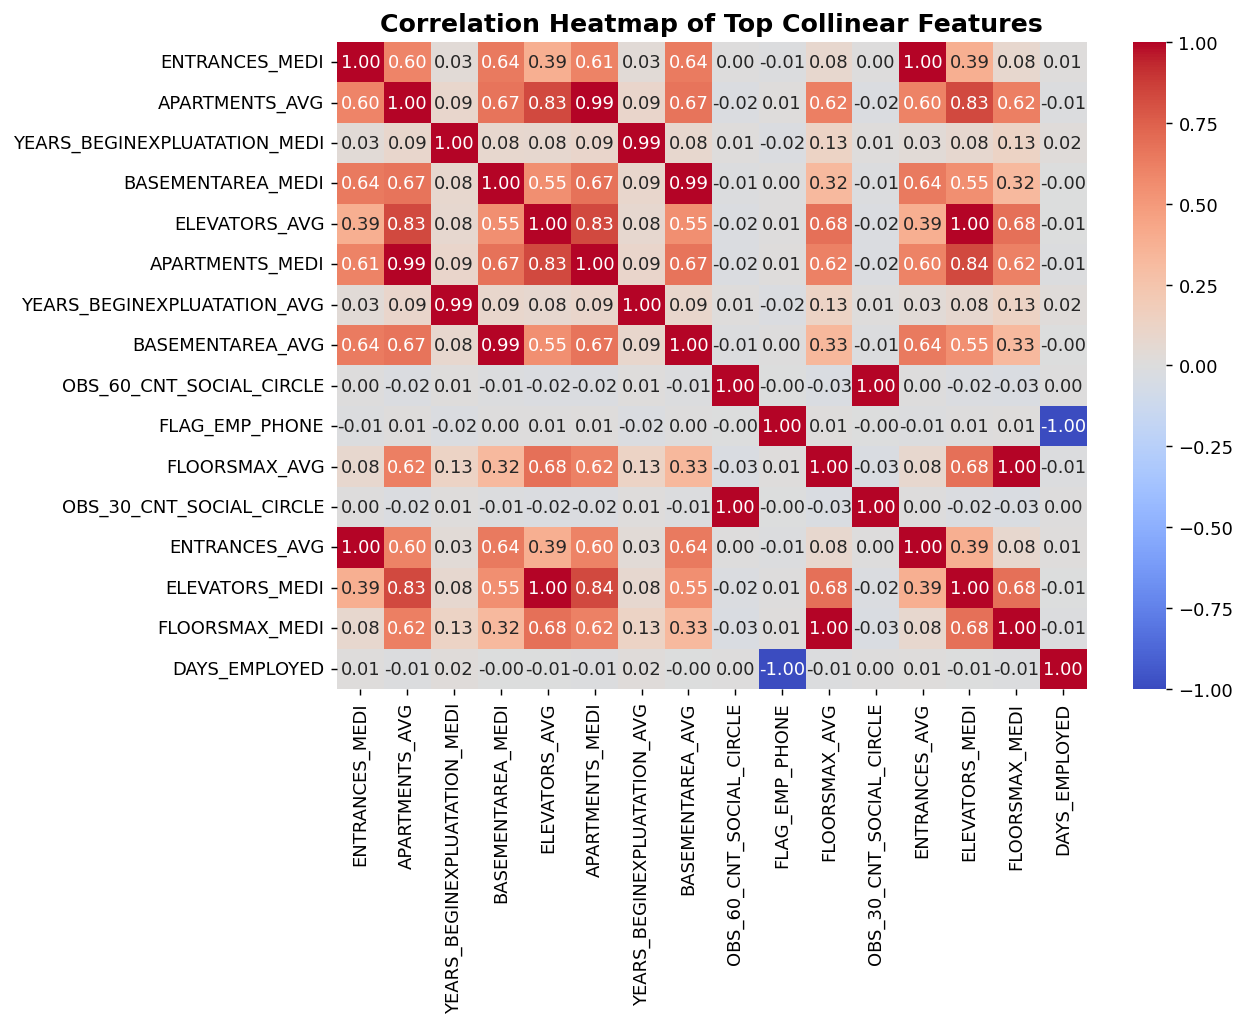

20969

In [ ]:
import gc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Fetch numeric features from DuckDB.
# We extract the features to analyze collinearity. 
# Using a 20% sample is statistically sufficient to compute stable correlation coefficients 
# and prevents RAM overload.
query_corr = f"""
    SELECT {', '.join(cols_to_analyze)}
    FROM app_train
    USING SAMPLE 20% (bernoulli)
"""
df_corr = con.execute(query_corr).df()

# 2. Downcast to optimize memory
for col in df_corr.select_dtypes(include=['float64']).columns:
    df_corr[col] = df_corr[col].astype('float32')

gc.collect()

# 3. Calculate the absolute correlation matrix
# We use absolute values because a strong negative correlation is just as redundant as a strong positive one.
corr_matrix = df_corr.corr().abs()

# 4. Extract the upper triangle of the matrix
# The correlation matrix is symmetrical. We only need the upper half to evaluate pairs 
# without duplicating them (e.g., A vs B is the same as B vs A) or comparing a feature to itself.
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 5. Identify features to drop based on a threshold
threshold = 0.80
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

# 6. Build a DataFrame to display the highly correlated pairs clearly
correlated_pairs = []
for col in to_drop:
    for row in upper_tri.index:
        if upper_tri.loc[row, col] > threshold:
            correlated_pairs.append({
                'Feature_1': row, 
                'Feature_2': col, 
                'Pearson_Correlation': upper_tri.loc[row, col]
            })

corr_df = pd.DataFrame(correlated_pairs).sort_values(by='Pearson_Correlation', ascending=False)

print(f"Threshold set to: {threshold}")
print(f"Found {len(to_drop)} redundant features to potentially drop.\n")

if len(corr_df) > 0:
    display(corr_df.head(15))
    
    # 7. Plot a heatmap for the top collinear features to visualize the clusters
    # We extract unique features from the top pairs for the heatmap
    top_features = list(set(corr_df['Feature_1'].head(8).tolist() + corr_df['Feature_2'].head(8).tolist()))
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_corr[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Heatmap of Top Collinear Features", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No highly correlated features found above the threshold.")

# Free up memory
del df_corr
del corr_matrix
del upper_tri
gc.collect()

### Non-Linear Feature Importance (LightGBM)
Evaluation of the non-linear and multivariate predictive power of the filtered features 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Top 20 columns by Tree-based Importance (Non-Linear):

                     feature  importance
                EXT_SOURCE_2         366
                EXT_SOURCE_3         365
                EXT_SOURCE_1         333
                  DAYS_BIRTH         249
               DAYS_EMPLOYED         234
             DAYS_ID_PUBLISH         223
                 AMT_ANNUITY         215
                  AMT_CREDIT         201
      DAYS_LAST_PHONE_CHANGE         188
           DAYS_REGISTRATION         175
             AMT_GOODS_PRICE         174
            AMT_INCOME_TOTAL         145
  REGION_POPULATION_RELATIVE         133
  AMT_REQ_CREDIT_BUREAU_YEAR         112
     HOUR_APPR_PROCESS_START          77
               LANDAREA_MODE          69
              TOTALAREA_MODE          68
           BASEMENTAREA_MODE          59
             LIVINGAREA_MODE          56
YEARS_BEGINEXPLUATATION_MODE          50


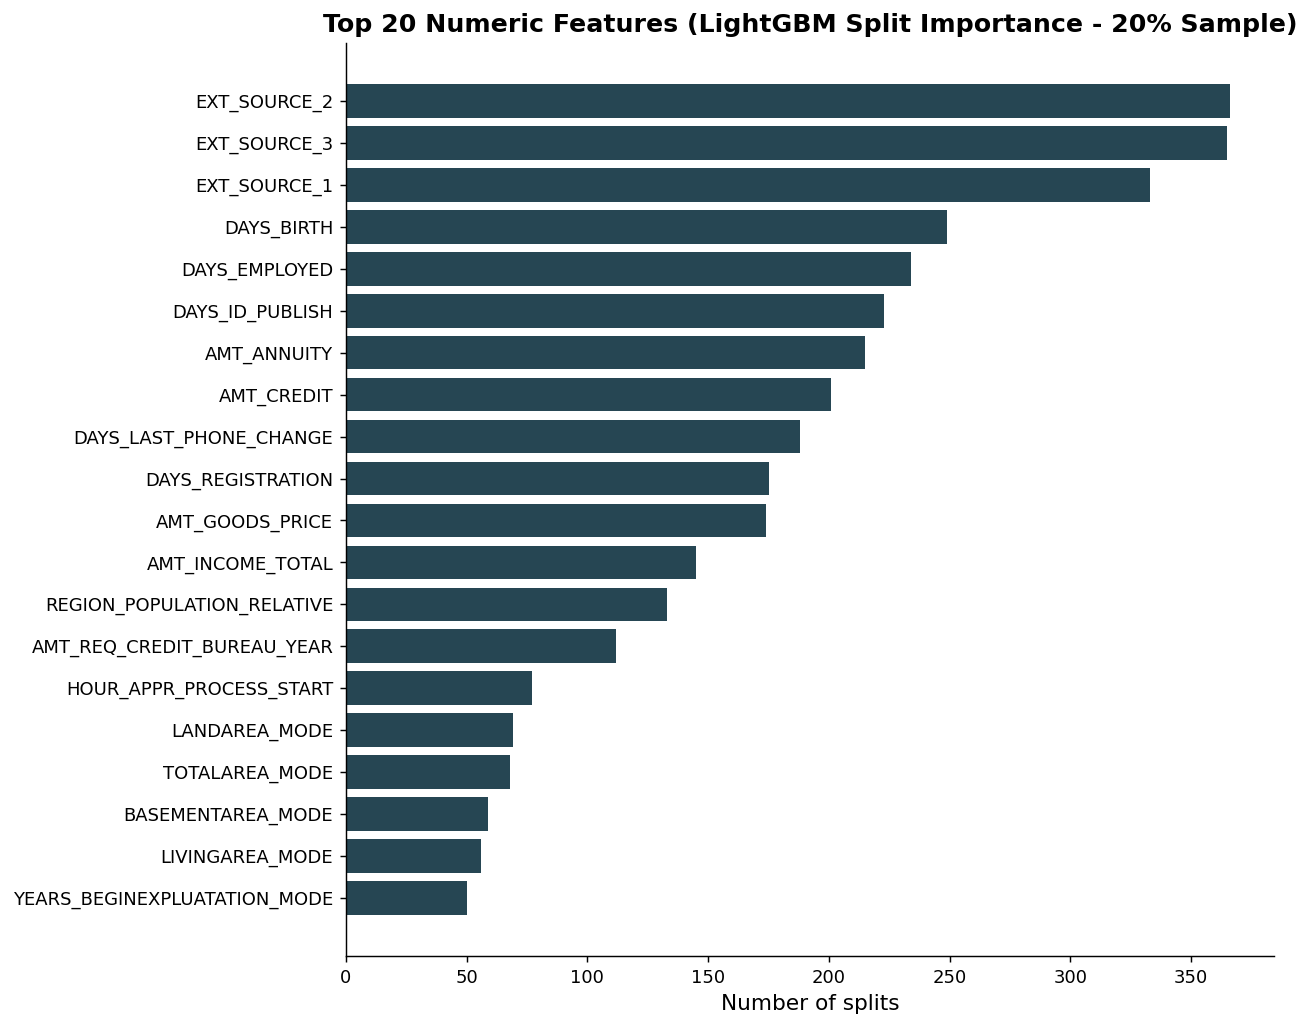

In [25]:
import gc
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt

# Force cleanup of unused memory
gc.collect()

# 1. Extract a 20% random sample from DuckDB to avoid MemoryError.
#    USING SAMPLE does sampling directly in DuckDB.
query_lgb = f"""
    SELECT {', '.join(cols_to_analyze)}, TARGET 
    FROM app_train 
    WHERE TARGET IS NOT NULL
    USING SAMPLE 20% (bernoulli)
"""
df_tree = con.execute(query_lgb).df()

# 2. RAM optimization: downcast float64 to float32
for col in df_tree.select_dtypes(include=['float64']).columns:
    df_tree[col] = df_tree[col].astype('float32')

# 3. Separate features and target
X = df_tree.drop(columns=['TARGET', 'TARGET_1', 'SK_ID_CURR'], errors='ignore')
y = df_tree['TARGET']

# Clear df_tree variable to free more RAM
del df_tree
gc.collect()

# 4. Initialize a simple LightGBM classifier.
clf = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# The model handles NaN internally, no pre-imputation required.
clf.fit(X, y)

# 5. Extract and sort feature importance
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# 6. Show Top 20
print("Top 20 columns by Tree-based Importance (Non-Linear):\n")
print(imp_df.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
top_20 = imp_df.head(20).iloc[::-1]
plt.barh(top_20['feature'], top_20['importance'], color='#264653')
plt.title("Top 20 Numeric Features (LightGBM Split Importance - 20% Sample)", fontsize=14, fontweight='bold')
plt.xlabel("Number of splits", fontsize=12)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


In [26]:
top20 = top_20['feature'].tolist()

types = con.execute("DESCRIBE app_train").df()[['column_name','column_type']]
numeric_types = {'BIGINT','INTEGER','DOUBLE','FLOAT','HUGEINT'}

numeric_count = types[types['column_name'].isin(top20) &
                      types['column_type'].isin(numeric_types)].shape[0]

print(f"Numeric columns among top 20: {numeric_count} / {len(top20)}")

Numeric columns among top 20: 20 / 20


### Outlier Analysis & Handling
Starting from DAYS_EMPLOYED

Records with anomalous DAYS_EMPLOYED (365243): 55374
Percentage of total: 18.01%
Default rate for anomaly records: 5.40%
Default rate for normal records: 8.66%



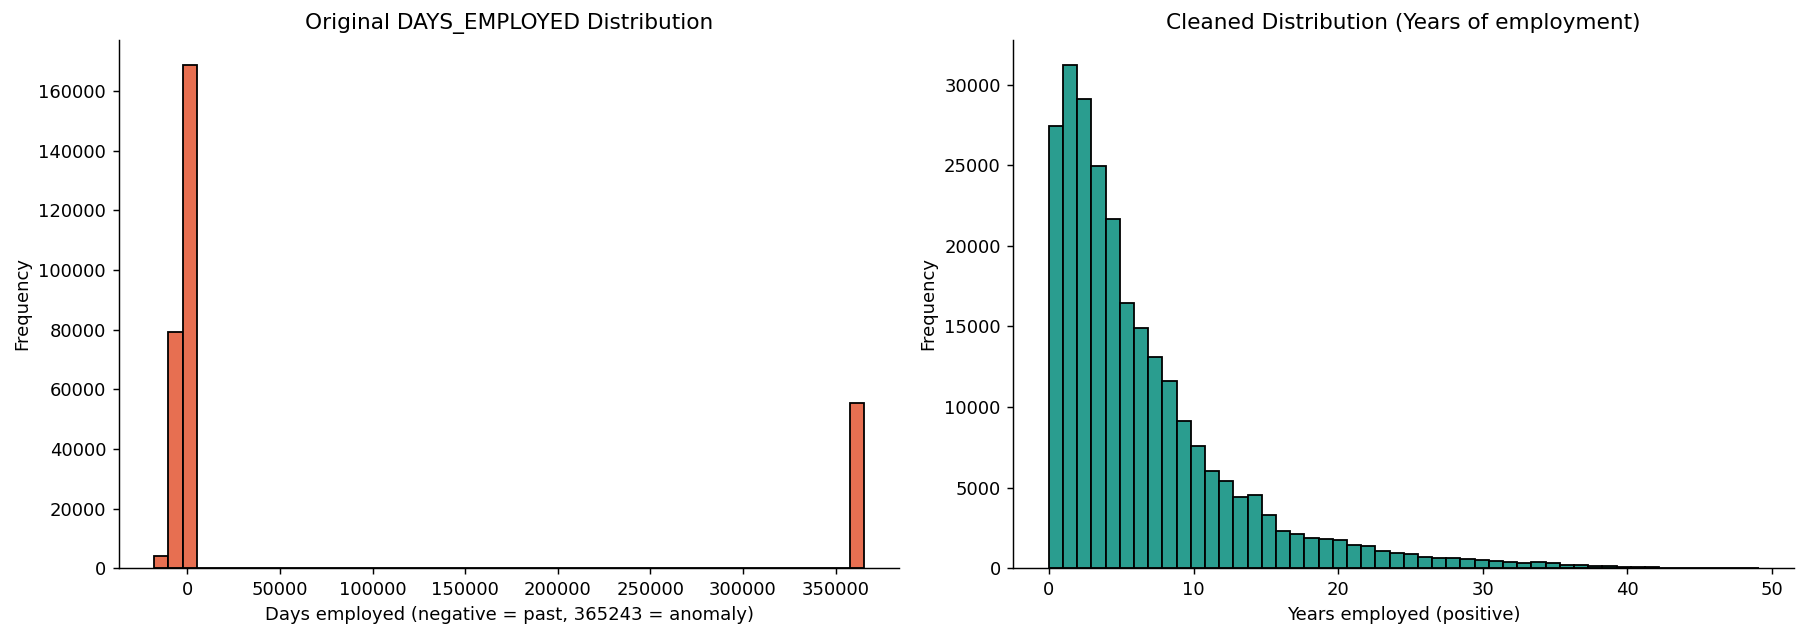

In [27]:
# 1. Extract DAYS_EMPLOYED and TARGET for outlier analysis
query_outlier = """
    SELECT DAYS_EMPLOYED, TARGET
    FROM app_train
    WHERE TARGET IS NOT NULL
"""
df_outlier = con.execute(query_outlier).df()

# 2. Compute statistics for the anomaly
anomalous_val = 365243
anomalies = df_outlier[df_outlier['DAYS_EMPLOYED'] == anomalous_val]
non_anomalies = df_outlier[df_outlier['DAYS_EMPLOYED'] != anomalous_val]

print(f"Records with anomalous DAYS_EMPLOYED ({anomalous_val}): {len(anomalies)}")
print(f"Percentage of total: {(len(anomalies) / len(df_outlier)) * 100:.2f}%")
print(f"Default rate for anomaly records: {anomalies['TARGET'].mean() * 100:.2f}%")
print(f"Default rate for normal records: {non_anomalies['TARGET'].mean() * 100:.2f}%\n")

# 3. Visual comparison: distribution with and without the anomaly
plt.figure(figsize=(14, 5))

# Original distribution
plt.subplot(1, 2, 1)
df_outlier['DAYS_EMPLOYED'].plot(kind='hist', bins=50, color='#e76f51', edgecolor='black')
plt.title('Original DAYS_EMPLOYED Distribution')
plt.xlabel('Days employed (negative = past, 365243 = anomaly)')
plt.ylabel('Frequency')

# Clean distribution (anomaly replaced with NaN), converted to years
days_employed_clean = df_outlier['DAYS_EMPLOYED'].replace(anomalous_val, np.nan)
plt.subplot(1, 2, 2)
(days_employed_clean / -365).plot(kind='hist', bins=50, color='#2a9d8f', edgecolor='black')
plt.title('Cleaned Distribution (Years of employment)')
plt.xlabel('Years employed (positive)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


## EDA

#### Target rate by categorical features

In [47]:
CAT_FEATURES = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_TYPE_SUITE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",      # ~30% missing — informative
    "ORGANIZATION_TYPE",    # 58 categories — top/bottom capped
    "FONDKAPREMONT_MODE",
    "HOUSETYPE_MODE",
    "WALLSMATERIAL_MODE",
]

global_rate = con.execute("""
    SELECT ROUND(AVG(TARGET) * 100, 3)
    FROM app_train WHERE TARGET IS NOT NULL
""").fetchone()[0]

print(f"Global default rate: {global_rate:.2f}%\n")

Global default rate: 8.07%



NAME_CONTRACT_TYPE
  highest : Cash loans                            8.3%
  lowest  : Revolving loans                       5.5%
  spread  : 2.9 pp  



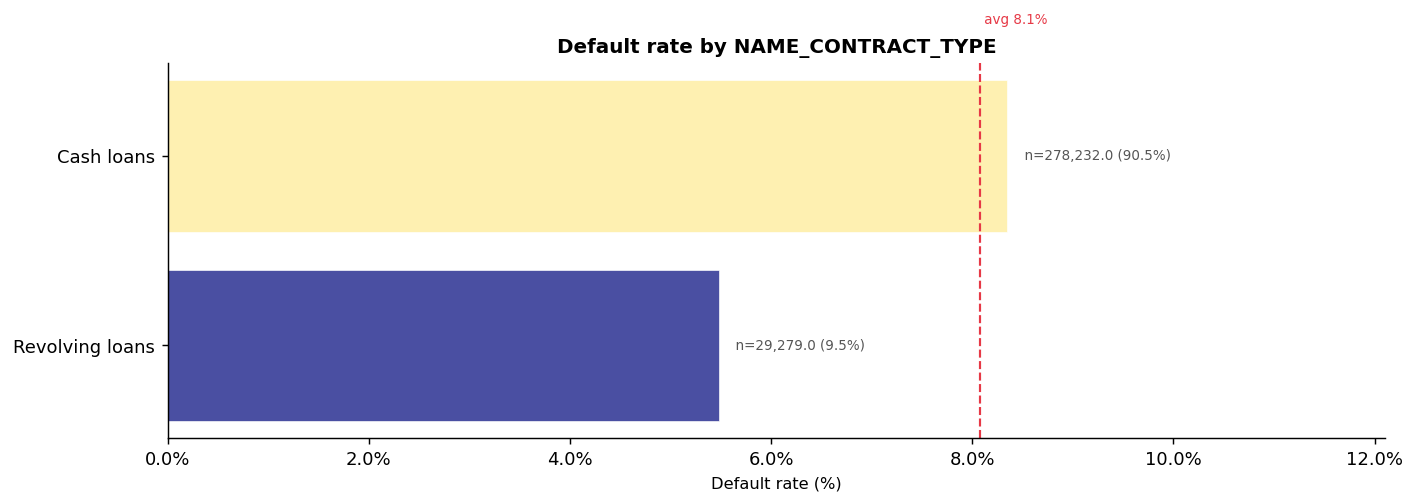

CODE_GENDER
  highest : M                                    10.1%
  lowest  : Other (rare)                          0.0%
  spread  : 10.1 pp  → HIGH signal



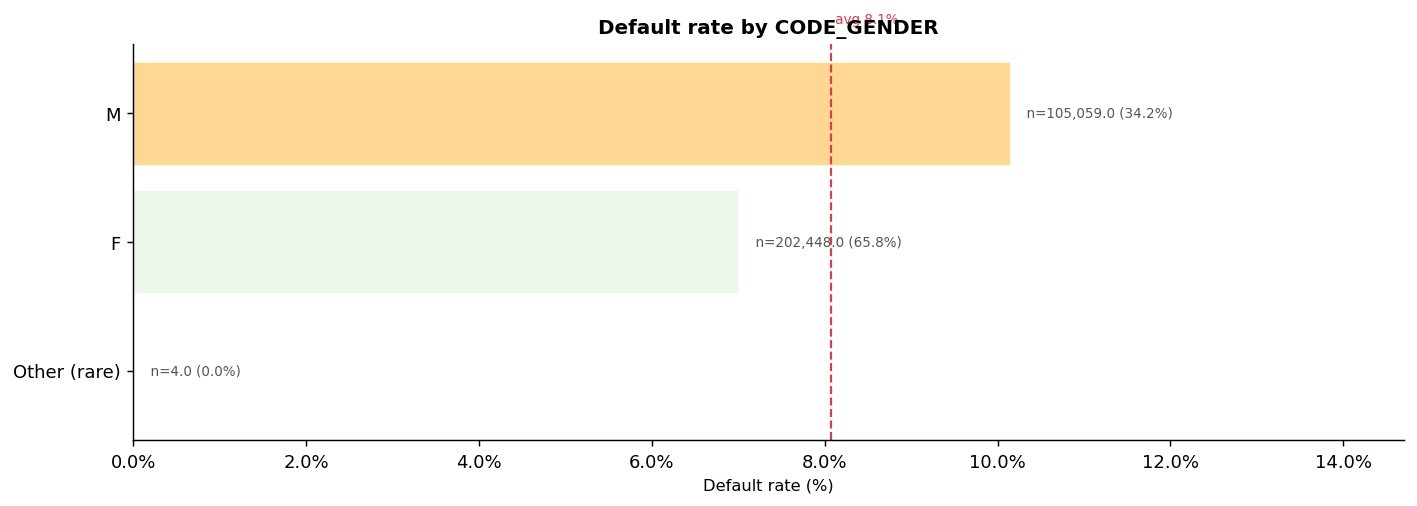

NAME_TYPE_SUITE
  highest : Other_B                               9.8%
  lowest  : Other (rare)                          7.0%
  spread  : 2.9 pp  



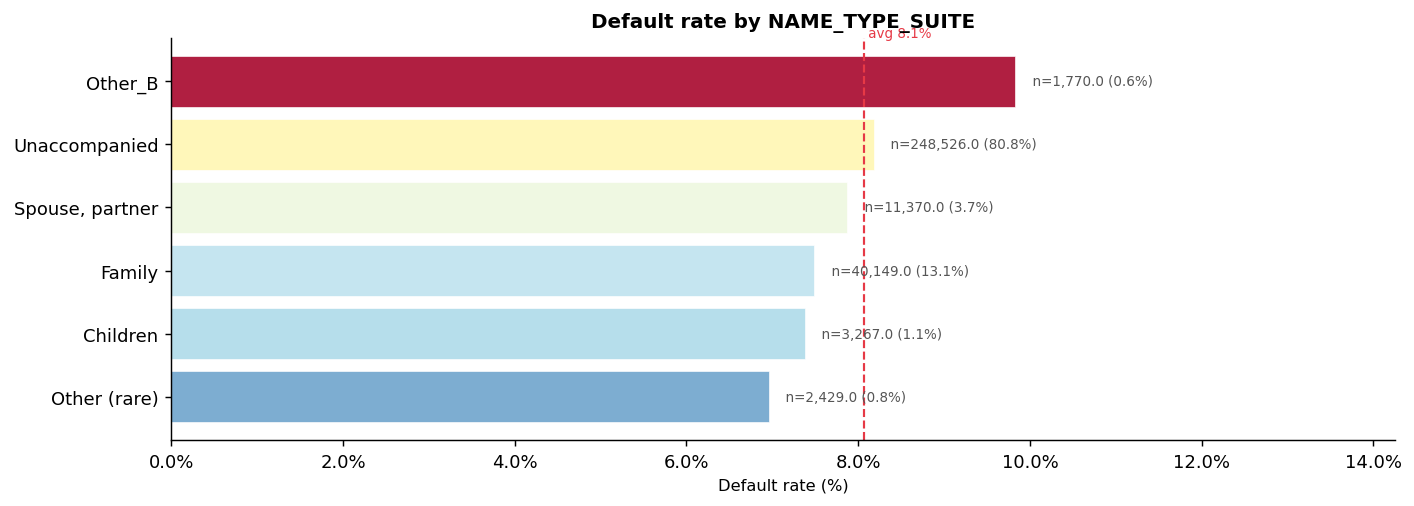

NAME_INCOME_TYPE
  highest : Other (rare)                         18.2%
  lowest  : Pensioner                             5.4%
  spread  : 12.8 pp  → HIGH signal



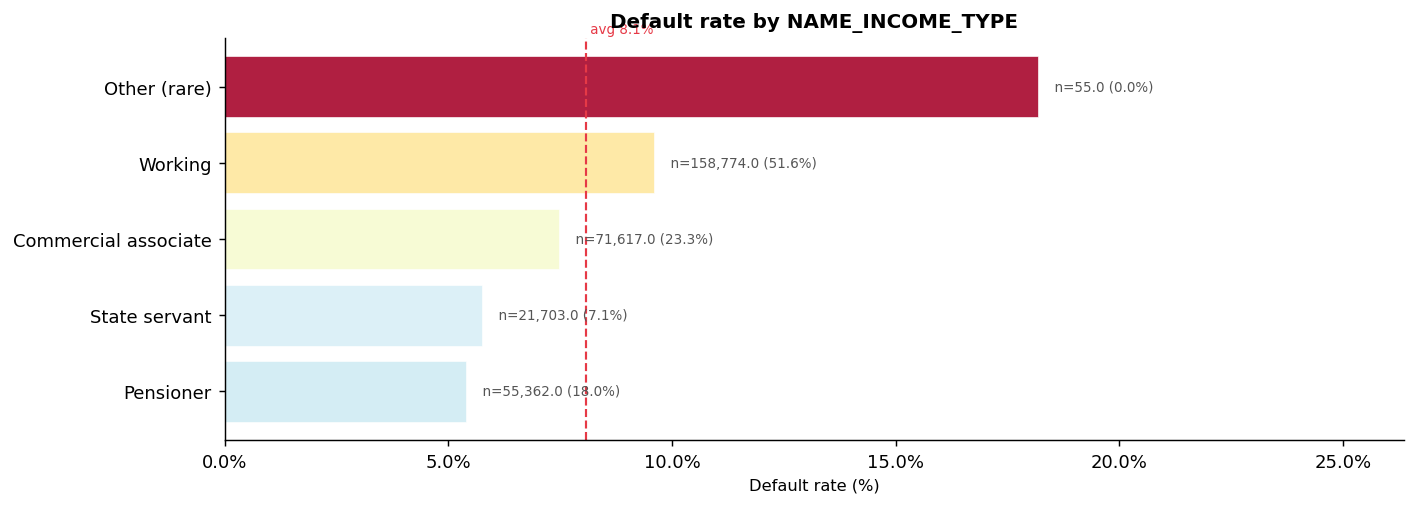

NAME_EDUCATION_TYPE
  highest : Lower secondary                      10.9%
  lowest  : Other (rare)                          1.8%
  spread  : 9.1 pp  → HIGH signal



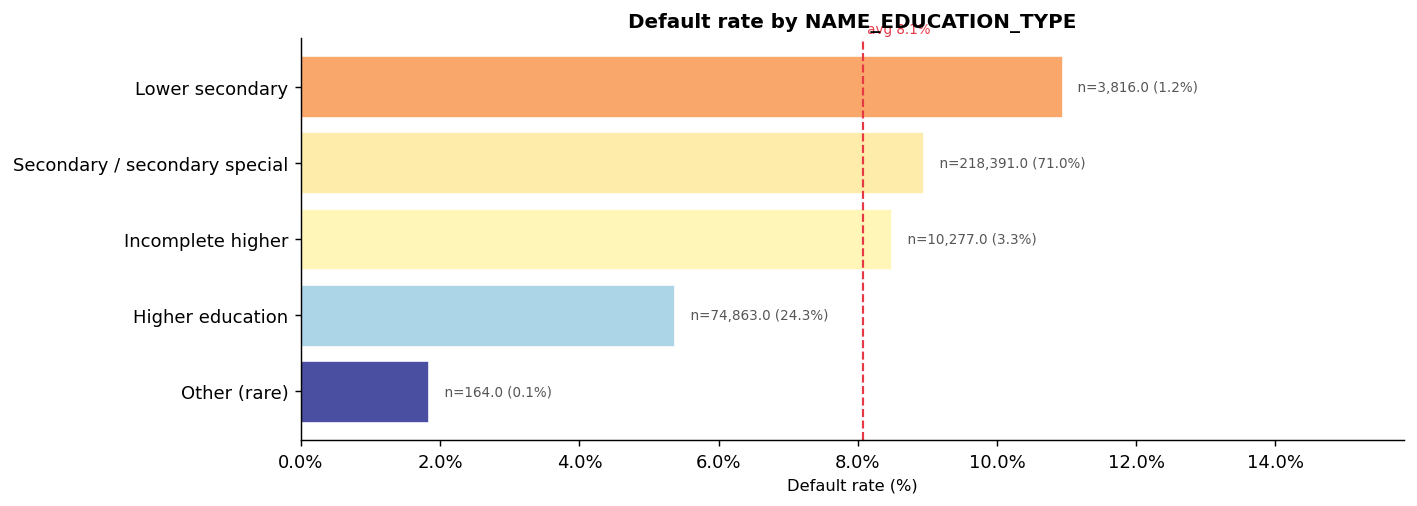

NAME_FAMILY_STATUS
  highest : Civil marriage                        9.9%
  lowest  : Other (rare)                          0.0%
  spread  : 9.9 pp  → HIGH signal



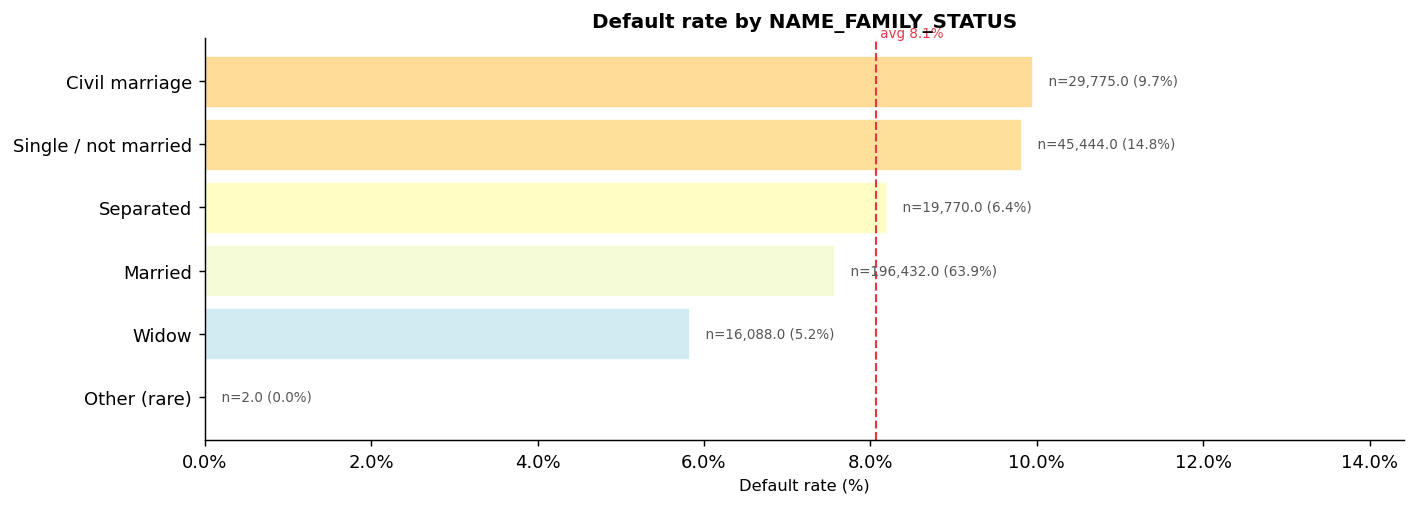

NAME_HOUSING_TYPE
  highest : Rented apartment                     12.3%
  lowest  : Office apartment                      6.6%
  spread  : 5.7 pp  → HIGH signal



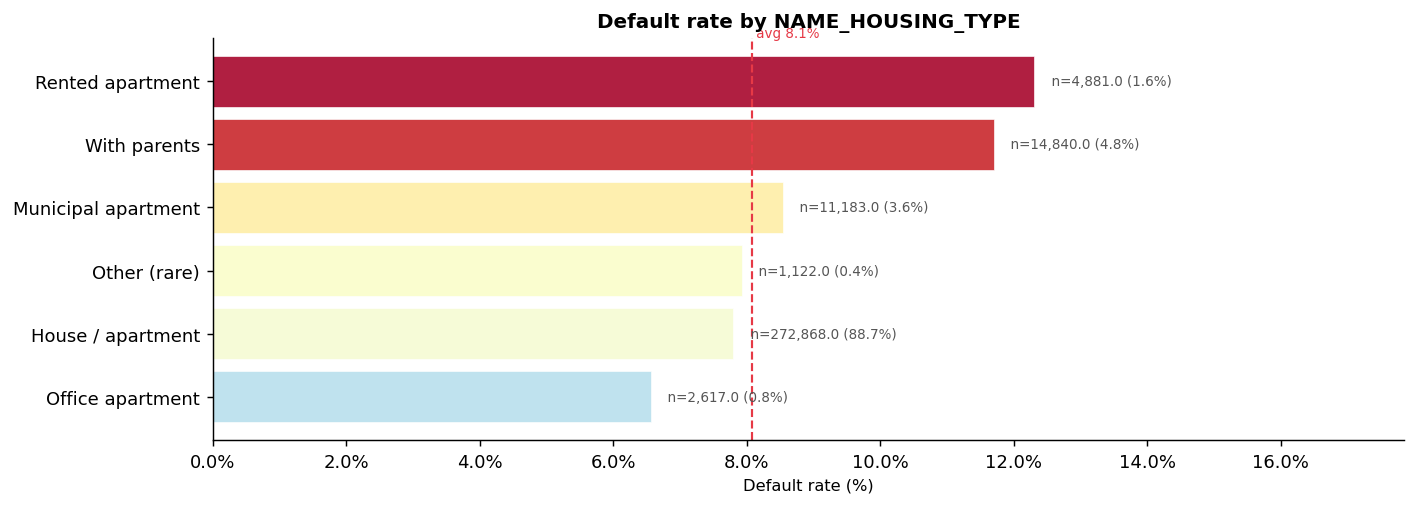

OCCUPATION_TYPE
  highest : Low-skill Laborers                   17.1%
  lowest  : Accountants                           4.8%
  spread  : 12.3 pp  → HIGH signal
  missing : 31.4% of clients  → 6.5% default rate



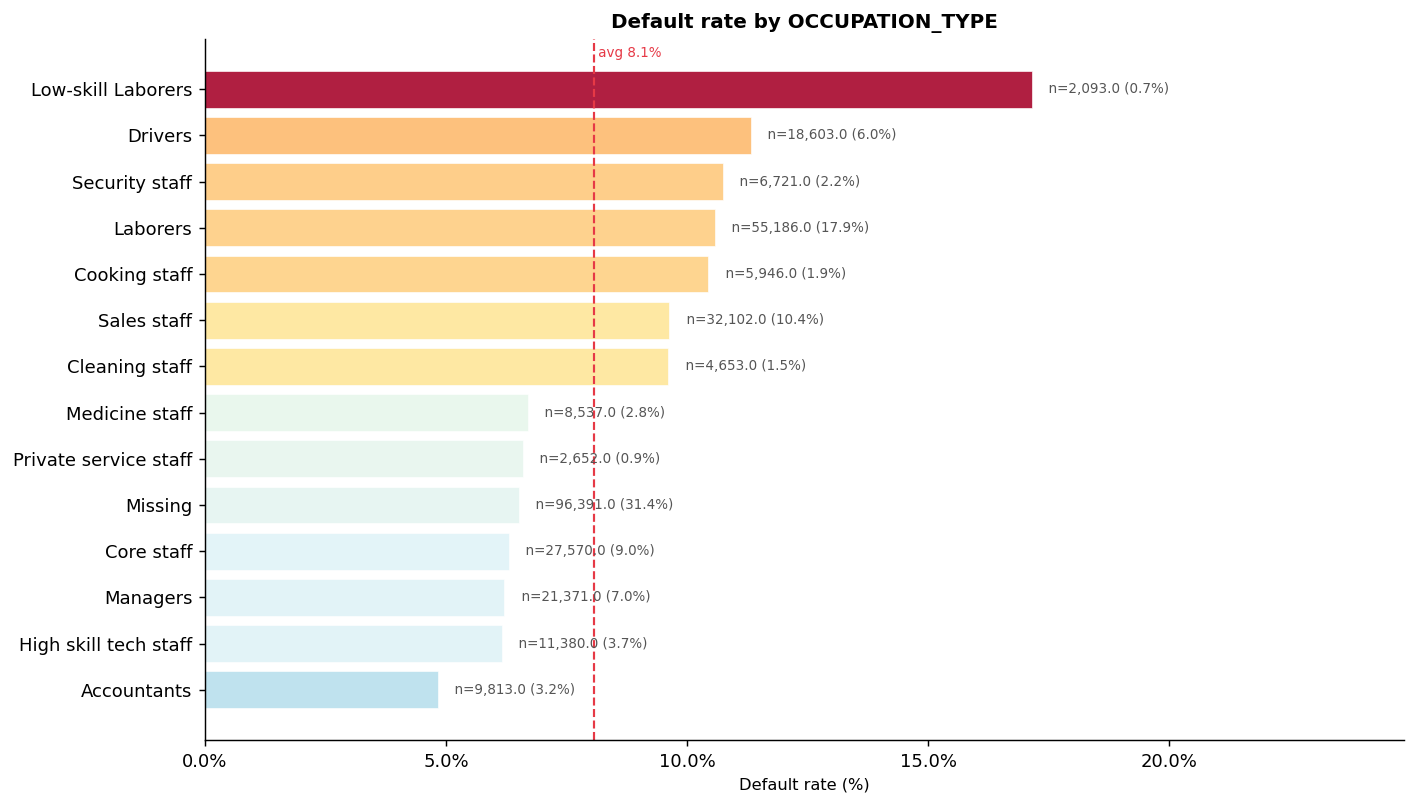

ORGANIZATION_TYPE
  highest : Restaurant                           11.7%
  lowest  : Security Ministries                   4.9%
  spread  : 6.9 pp  → HIGH signal



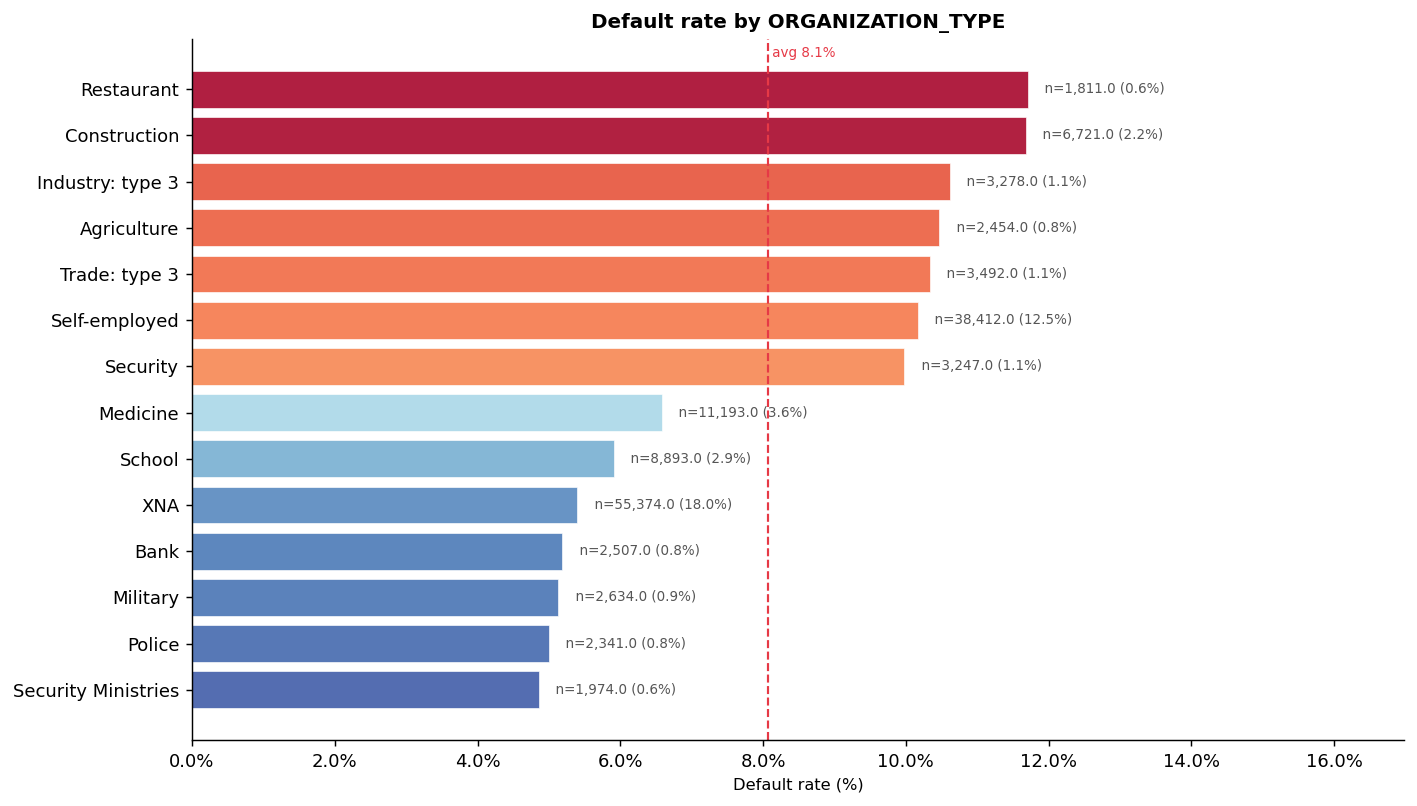

FONDKAPREMONT_MODE
  highest : Missing                               8.6%
  lowest  : org spec account                      5.8%
  spread  : 2.8 pp  
  missing : 68.4% of clients  → 8.6% default rate



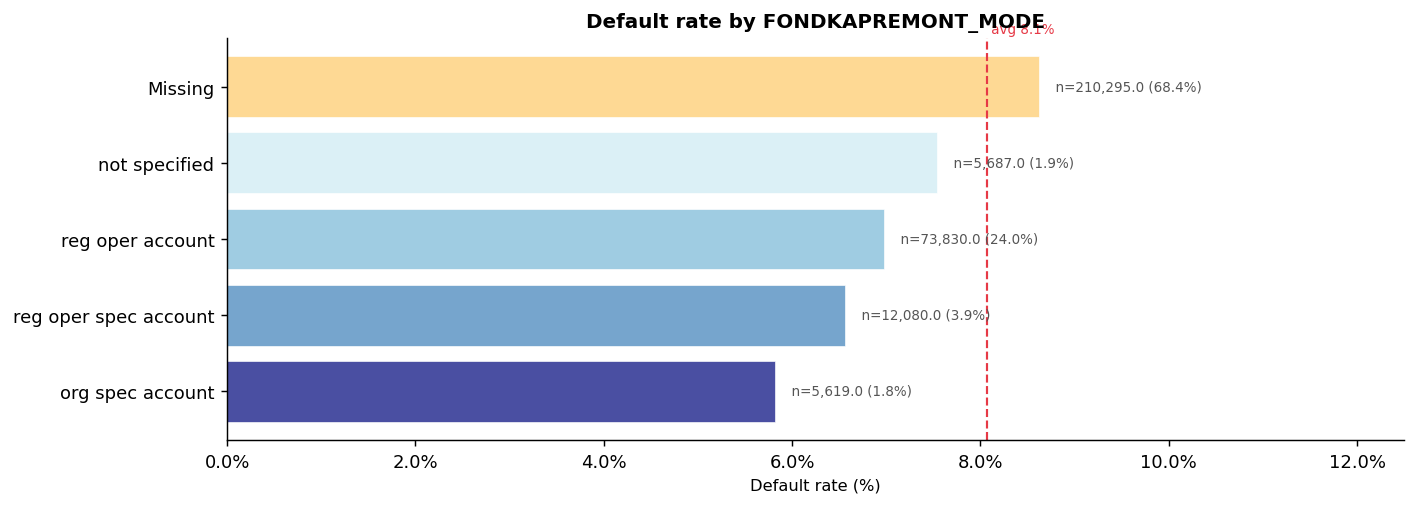

HOUSETYPE_MODE
  highest : Other (rare)                          9.4%
  lowest  : block of flats                        6.9%
  spread  : 2.5 pp  
  missing : 50.2% of clients  → 9.2% default rate



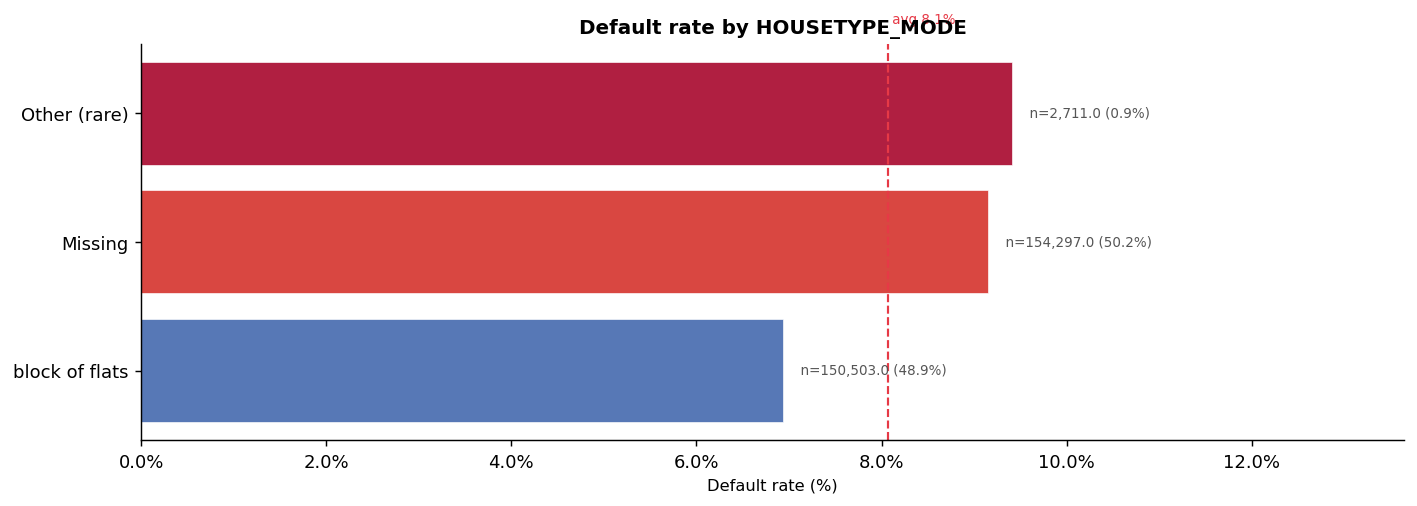

WALLSMATERIAL_MODE
  highest : Wooden                                9.7%
  lowest  : Monolithic                            4.7%
  spread  : 5.0 pp  
  missing : 50.8% of clients  → 9.1% default rate



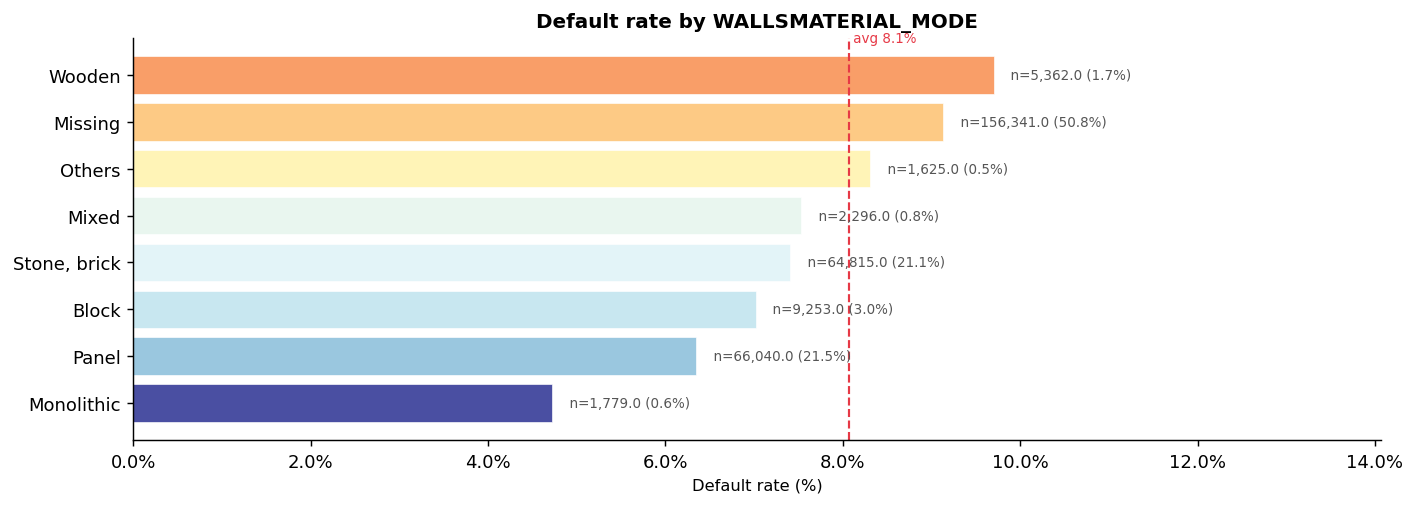

In [48]:
def get_cat_stats(con, col: str) -> pd.DataFrame:
    """
    Returns default rate, count and % population per category.
    Nulls become 'Missing'. Categories < 0.5% population → 'Other (rare)'.
    """
    return con.execute(f"""
        WITH base AS (
            SELECT
                COALESCE(CAST({col} AS VARCHAR), 'Missing') AS category,
                COUNT(*)       AS n_obs,
                SUM(TARGET)    AS n_defaults,
                COUNT(*) * 100.0 / SUM(COUNT(*)) OVER ()    AS pct_pop
            FROM app_train
            WHERE TARGET IS NOT NULL
            GROUP BY {col}
        )
        SELECT
            CASE WHEN pct_pop < 0.5 THEN 'Other (rare)' ELSE category END AS category,
            SUM(n_obs)                                             AS n_obs,
            ROUND(SUM(n_defaults) * 100.0 / SUM(n_obs), 2)        AS default_rate_pct,
            ROUND(SUM(pct_pop), 2)                                 AS pct_pop
        FROM base
        GROUP BY 1
        ORDER BY default_rate_pct DESC
    """).fetchdf()


def plot_cat_default_rate(con, col: str, max_bars: int = 14):
    df = get_cat_stats(con, col)
    if df.empty:
        return

    # For high-cardinality columns keep top + bottom halves only
    if len(df) > max_bars:
        half = max_bars // 2
        df   = pd.concat([df.head(half), df.tail(half)]).drop_duplicates()

    df = df.sort_values('default_rate_pct', ascending=True)

    fig, ax = plt.subplots(figsize=(11, max(4, len(df) * 0.45)))

    # Color by distance from global average
    diffs     = df['default_rate_pct'] - global_rate
    abs_max   = max(abs(diffs).max(), 0.01)
    colors    = [plt.cm.RdYlBu_r(0.5 + 0.5 * v / abs_max) for v in diffs]

    ax.barh(df['category'], df['default_rate_pct'],
            color=colors, alpha=0.88, edgecolor='white', linewidth=0.4)

    # Annotation: volume + population share
    x_max = df['default_rate_pct'].max()
    for _, row in df.iterrows():
        ax.text(row['default_rate_pct'] + x_max * 0.01,
                df[df['category'] == row['category']].index[0]
                    if False else list(df['category']).index(row['category']),
                f"  n={row['n_obs']:,} ({row['pct_pop']:.1f}%)",
                va='center', fontsize=7.5, color='#555')

    ax.axvline(global_rate, color='#e63946', linewidth=1.2, linestyle='--')
    ax.text(global_rate, len(df) - 0.3,
            f" avg {global_rate:.1f}%", fontsize=7.5, color='#e63946')

    ax.set_xlabel("Default rate (%)", fontsize=9)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.set_xlim(right=x_max * 1.45)
    ax.set_title(f"Default rate by {col}", fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"eda_cat_{col.lower()}.png", bbox_inches='tight', dpi=150)
    plt.show()


for col in CAT_FEATURES:
    # Quick text summary
    df = get_cat_stats(con, col)
    top, bot = df.iloc[0], df.iloc[-1]
    spread   = top['default_rate_pct'] - bot['default_rate_pct']
    missing  = df[df['category'] == 'Missing']

    print(f"{col}")
    print(f"  highest : {top['category']:<35} {top['default_rate_pct']:>5.1f}%")
    print(f"  lowest  : {bot['category']:<35} {bot['default_rate_pct']:>5.1f}%")
    print(f"  spread  : {spread:.1f} pp  {'→ HIGH signal' if spread > 5 else ''}")
    if not missing.empty:
        mr = missing.iloc[0]
        print(f"  missing : {mr['pct_pop']:.1f}% of clients  → {mr['default_rate_pct']:.1f}% default rate")
    print()

    plot_cat_default_rate(con, col)

#### Target rate by numeric feature bins

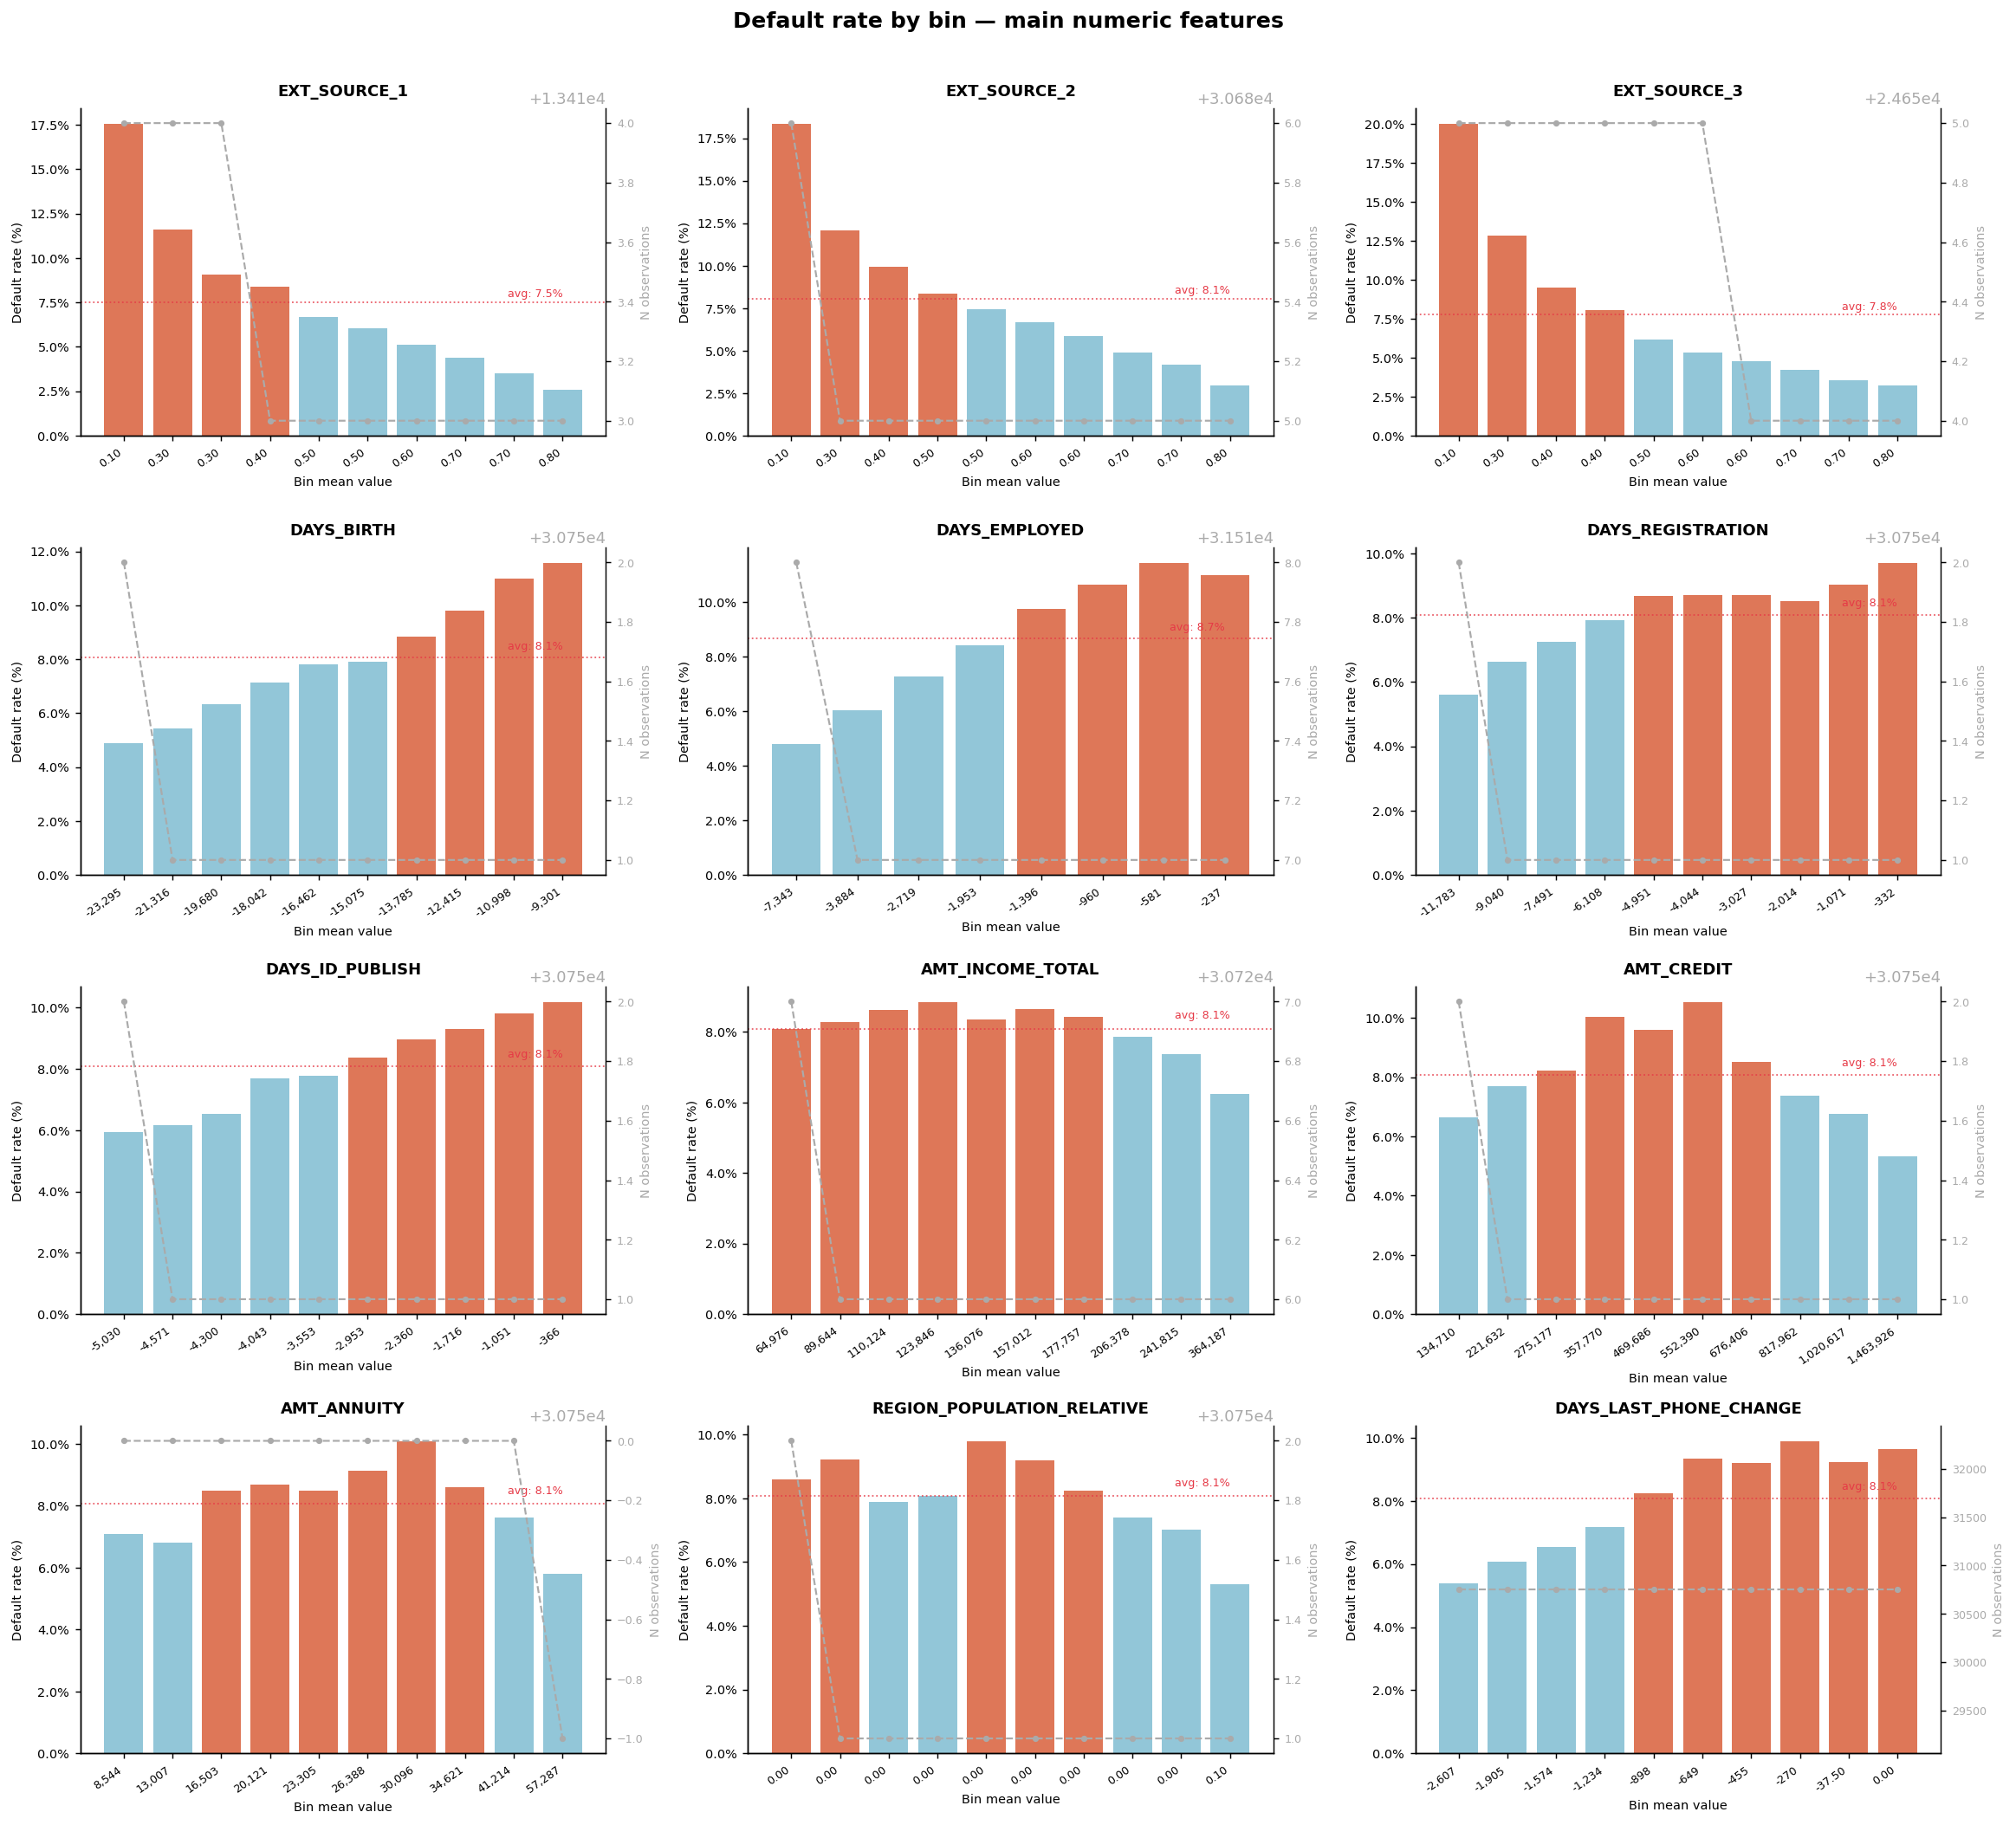

Saved: eda_target_rate_numeric_bins.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

NUMERIC_FEATURES = {
    "EXT_SOURCE_1": 10,
    "EXT_SOURCE_2": 10,
    "EXT_SOURCE_3": 10,
    "DAYS_BIRTH": 10,
    "DAYS_EMPLOYED": 8,
    "DAYS_REGISTRATION": 10,
    "DAYS_ID_PUBLISH": 10,
    "AMT_INCOME_TOTAL": 10,
    "AMT_CREDIT": 10,
    "AMT_ANNUITY": 10,
    "REGION_POPULATION_RELATIVE": 10,
    "DAYS_LAST_PHONE_CHANGE": 10,
}

def plot_target_rate_by_bins(con, features: dict, n_cols: int = 3):
    """
    For each numeric feature:
      - Filters known anomalous values (e.g. DAYS_EMPLOYED = 365243)
      - Creates equal-population bins via NTILE (more robust than equal-width)
      - Computes target rate and volume per bin
      - Plots bar chart (target rate) + dashed line (volume)

    The key fix vs the previous version: NTILE is computed in the first CTE,
    bin_mean is aggregated in the second CTE — no nested window functions.
    """
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, (col, n_bins) in zip(axes, features.items()):

        # Build WHERE clause — filter nulls + known anomalies
        filters = [f"{col} IS NOT NULL", "TARGET IS NOT NULL"]
        if col == "DAYS_EMPLOYED":
            filters.append("DAYS_EMPLOYED != 365243")
        if col == "AMT_INCOME_TOTAL":
            filters.append("AMT_INCOME_TOTAL < 1000000")
        where_clause = "WHERE " + " AND ".join(filters)

        # Two-step CTE: first assign bins, then aggregate per bin
        # This avoids nested window functions (not supported in DuckDB)
        query = f"""
            WITH assigned AS (
                SELECT
                    TARGET,
                    {col}                                    AS raw_value,
                    NTILE({n_bins}) OVER (ORDER BY {col})    AS bin
                FROM app_train
                {where_clause}
            ),
            aggregated AS (
                SELECT
                    bin,
                    ROUND(AVG(raw_value), 1)         AS bin_mean,
                    ROUND(AVG(TARGET) * 100, 2)      AS default_rate_pct,
                    COUNT(*)                         AS n_obs
                FROM assigned
                GROUP BY bin
            )
            SELECT * FROM aggregated
            ORDER BY bin
        """

        df = con.execute(query).fetchdf()

        if df.empty:
            ax.set_visible(False)
            continue

        # Bars above average → red, below → blue
        mean_rate   = df['default_rate_pct'].mean()
        color_bars  = [
            "#d95f3b" if r > mean_rate else "#7fbcd2"
            for r in df['default_rate_pct']
        ]

        ax2 = ax.twinx()

        # Volume line (right axis)
        ax2.plot(df['bin'], df['n_obs'],
                 color='#aaaaaa', linewidth=1.2,
                 linestyle='--', marker='o', markersize=3,
                 label='Volume', zorder=1)
        ax2.set_ylabel("N observations", fontsize=8, color='#aaaaaa')
        ax2.tick_params(axis='y', labelcolor='#aaaaaa', labelsize=7)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(True)

        # Target rate bars (left axis)
        ax.bar(df['bin'], df['default_rate_pct'],
               color=color_bars, alpha=0.85, zorder=2)

        # Average target rate reference line
        ax.axhline(mean_rate, color='#e63946',
                   linewidth=1, linestyle=':', alpha=0.8)
        ax.text(df['bin'].max(), mean_rate + 0.3,
                f"avg: {mean_rate:.1f}%",
                fontsize=7, color='#e63946', ha='right')

        # X-axis labels = mean value of each bin
        ax.set_xticks(df['bin'])
        ax.set_xticklabels(
            [f"{v:,.0f}" if abs(v) > 100 else f"{v:.2f}"
             for v in df['bin_mean']],
            rotation=35, ha='right', fontsize=7
        )

        ax.set_title(col, fontsize=10, fontweight='bold', pad=8)
        ax.set_xlabel("Bin mean value", fontsize=8)
        ax.set_ylabel("Default rate (%)", fontsize=8)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
        ax.tick_params(axis='y', labelsize=8)

    for ax in axes[len(features):]:
        ax.set_visible(False)

    fig.suptitle("Default rate by bin — main numeric features",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("eda_target_rate_numeric_bins.png",
                bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: eda_target_rate_numeric_bins.png")

plot_target_rate_by_bins(con, NUMERIC_FEATURES)

#### Distribution of numeric features

In [4]:
NUMERIC_COLS = {
    "AMT_INCOME_TOTAL":    {"unit": "currency", "min_valid": 0,      "max_valid": 1_000_000_000},
    "AMT_CREDIT":          {"unit": "currency", "min_valid": 0,      "max_valid": 1_000_000_000},
    "AMT_ANNUITY":         {"unit": "currency", "min_valid": 0,      "max_valid": 1_000_000_000},
    "AMT_GOODS_PRICE":     {"unit": "currency", "min_valid": 0,      "max_valid": 1_000_000_000},
    "DAYS_BIRTH":          {"unit": "days",     "min_valid": -30000, "max_valid": -6000},   # ~18-82 years
    "DAYS_REGISTRATION":   {"unit": "days",     "min_valid": -30000, "max_valid": 0},
    "DAYS_ID_PUBLISH":     {"unit": "days",     "min_valid": -10000, "max_valid": 0},
    "DAYS_LAST_PHONE_CHANGE": {"unit": "days",  "min_valid": -5000,  "max_valid": 0},
    "CNT_CHILDREN":        {"unit": "count",    "min_valid": 0,      "max_valid": 20},
    "CNT_FAM_MEMBERS":     {"unit": "count",    "min_valid": 1,      "max_valid": 30},
    "HOUR_APPR_PROCESS_START": {"unit": "hour", "min_valid": 0,      "max_valid": 23},
}

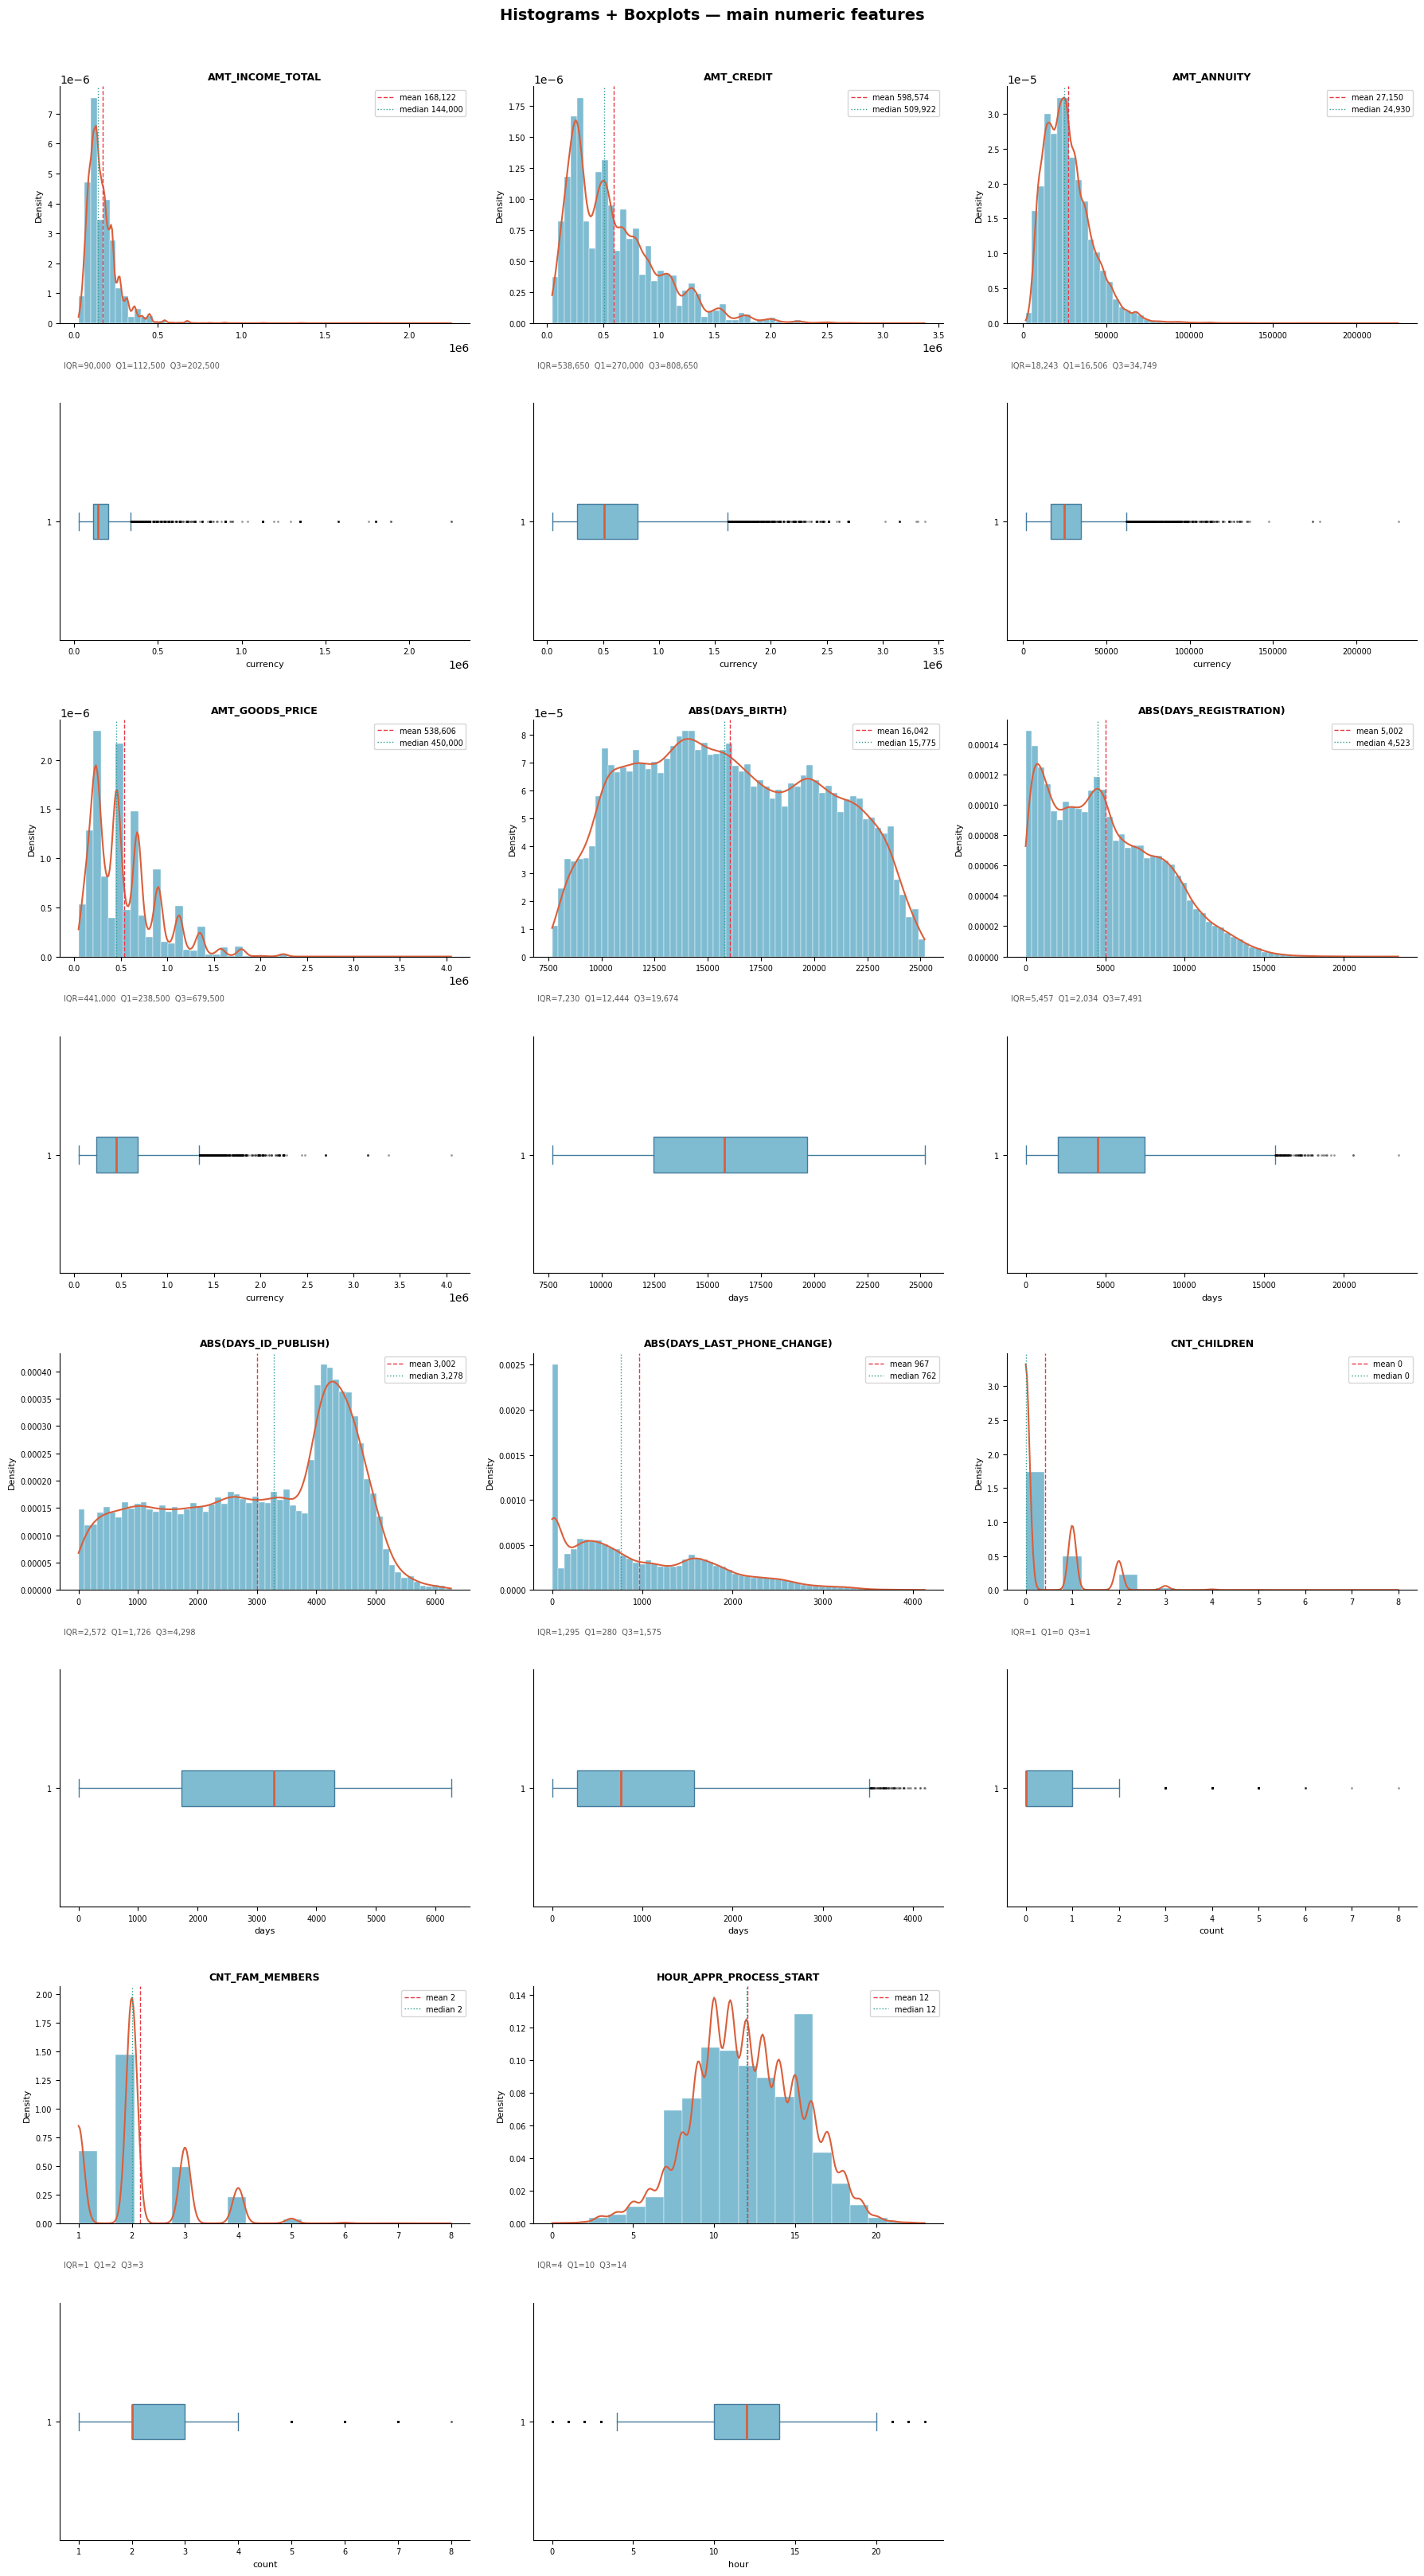

In [7]:
def plot_histograms_and_boxplots(con, cols: dict, n_cols: int = 3):
    """
    For each numeric column:
      - Left : histogram with KDE-style density curve (raw values)
      - Right : horizontal boxplot with outlier dots
    Values outside [min_valid, max_valid] are filtered before plotting
    so the chart reflects the realistic distribution.
    DAYS_* columns are converted to positive values for readability.
    """
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows * 2, n_cols,
                             figsize=(6 * n_cols, 4 * n_rows * 2))

    for idx, (col, meta) in enumerate(cols.items()):
        row_hist = (idx // n_cols) * 2
        row_box  = row_hist + 1
        col_pos  = idx % n_cols

        ax_hist = axes[row_hist, col_pos]
        ax_box  = axes[row_box,  col_pos]

        # Fetch sample — DuckDB native sampling for speed
        is_days = col.startswith("DAYS_")
        expr    = f"ABS({col})" if is_days else col   # flip sign for DAYS_*

        df = con.execute(f"""
            SELECT {expr} AS value
            FROM app_train
            WHERE {col} IS NOT NULL
              AND {col} BETWEEN {meta['min_valid']} AND {meta['max_valid']}
            USING SAMPLE 50000 ROWS
        """).fetchdf()['value']

        if df.empty:
            ax_hist.set_visible(False)
            ax_box.set_visible(False)
            continue

        # ── Histogram ────────────────────────────────────────────────
        n_bins = min(60, max(20, len(df.unique()) // 10))
        ax_hist.hist(df, bins=n_bins, color='#7fbcd2',
                     edgecolor='white', linewidth=0.3, density=True)

        # Overlay smoothed density curve
        from scipy.stats import gaussian_kde
        kde  = gaussian_kde(df, bw_method='scott')
        x_kd = np.linspace(df.min(), df.max(), 300)
        ax_hist.plot(x_kd, kde(x_kd), color='#d95f3b', linewidth=1.5)

        # Annotate mean and median
        ax_hist.axvline(df.mean(),   color='#e63946', linewidth=1,
                        linestyle='--', label=f"mean {df.mean():,.0f}")
        ax_hist.axvline(df.median(), color='#2a9d8f', linewidth=1,
                        linestyle=':', label=f"median {df.median():,.0f}")
        ax_hist.legend(fontsize=7)
        ax_hist.set_title(
            f"{'ABS(' + col + ')' if is_days else col}",
            fontsize=9, fontweight='bold'
        )
        ax_hist.set_ylabel("Density", fontsize=8)
        ax_hist.spines[['top', 'right']].set_visible(False)
        ax_hist.tick_params(labelsize=7)

        # ── Boxplot ───────────────────────────────────────────────────
        ax_box.boxplot(df, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='#7fbcd2', color='#457b9d'),
                       medianprops=dict(color='#d95f3b', linewidth=2),
                       flierprops=dict(marker='.', color='#aaaaaa',
                                       markersize=2, alpha=0.4),
                       whiskerprops=dict(color='#457b9d'),
                       capprops=dict(color='#457b9d'))

        # Annotate IQR and whisker bounds
        q1, q3 = df.quantile(0.25), df.quantile(0.75)
        iqr    = q3 - q1
        ax_box.text(0.01, 1.15,
                    f"IQR={iqr:,.0f}  Q1={q1:,.0f}  Q3={q3:,.0f}",
                    transform=ax_box.transAxes,
                    fontsize=7, color='#555')
        ax_box.set_xlabel(meta['unit'], fontsize=8)
        ax_box.spines[['top', 'right']].set_visible(False)
        ax_box.tick_params(labelsize=7)

    # Hide unused axes
    total_axes = n_rows * n_cols
    for i in range(len(cols), total_axes):
        axes[(i // n_cols) * 2,     i % n_cols].set_visible(False)
        axes[(i // n_cols) * 2 + 1, i % n_cols].set_visible(False)

    fig.suptitle("Histograms + Boxplots — main numeric features",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("eda_hist_boxplot.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_histograms_and_boxplots(con, NUMERIC_COLS)

Skewness assessment — log-transform candidates

Column                            Skew    Kurt    p99/p01  Log candidate
──────────────────────────────────────────────────────────────────────
AMT_INCOME_TOTAL                391.56 191786.55      10.5  ✓  LOG-TRANSFORM
CNT_CHILDREN                      1.97    7.90       nan  
AMT_ANNUITY                       1.58    7.71      11.3  ✓  LOG-TRANSFORM
AMT_GOODS_PRICE                   1.35    2.43      26.7  
AMT_CREDIT                        1.23    1.93      24.3  
CNT_FAM_MEMBERS                   0.99    2.80       5.0  
DAYS_LAST_PHONE_CHANGE            0.71   -0.31       nan  
DAYS_REGISTRATION                 0.59   -0.32     277.6  
DAYS_BIRTH                        0.12   -1.05       3.0  
HOUR_APPR_PROCESS_START          -0.03   -0.19       4.8  
DAYS_ID_PUBLISH                  -0.35   -1.11      89.3  


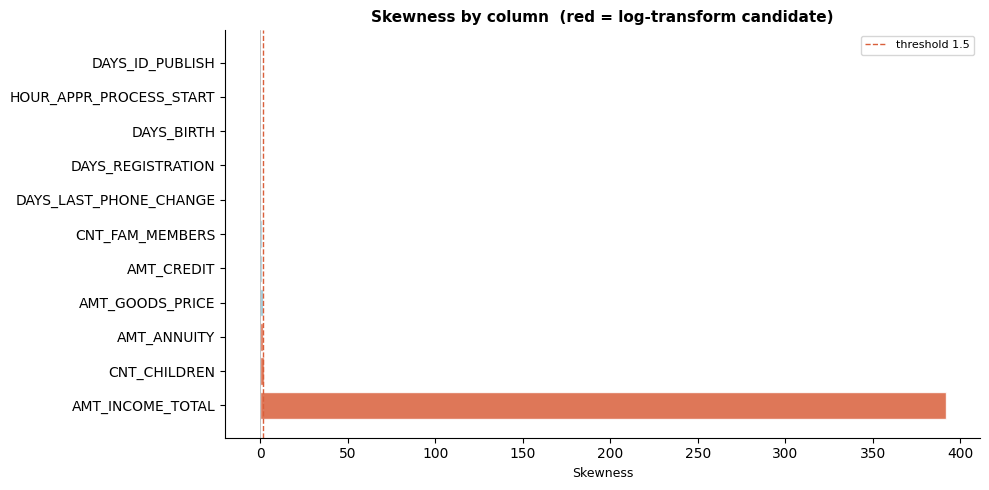

In [8]:
def assess_skewness(con, cols: dict) -> pd.DataFrame:
    """
    Computes skewness and kurtosis for each column directly in DuckDB.
    Flags columns as log-transform candidates when:
      - skewness > 1.5  (right-heavy tail)
      - the column is strictly positive (log requires x > 0)
    Returns a ranked DataFrame and prints a summary.
    """
    rows = []
    for col, meta in cols.items():
        is_days = col.startswith("DAYS_")
        expr    = f"ABS({col})" if is_days else col

        stats = con.execute(f"""
            SELECT
                SKEWNESS({expr})                       AS skewness,
                KURTOSIS({expr})                       AS kurtosis,
                MIN({expr})                            AS min_val,
                MAX({expr})                            AS max_val,
                PERCENTILE_CONT(0.99)
                    WITHIN GROUP (ORDER BY {expr})     AS p99,
                PERCENTILE_CONT(0.01)
                    WITHIN GROUP (ORDER BY {expr})     AS p01
            FROM app_train
            WHERE {col} IS NOT NULL
              AND {col} BETWEEN {meta['min_valid']} AND {meta['max_valid']}
        """).fetchdf().iloc[0]

        rows.append({
            "column":           col,
            "skewness":         round(stats['skewness'], 2),
            "kurtosis":         round(stats['kurtosis'], 2),
            "min":              round(stats['min_val'],  2),
            "max":              round(stats['max_val'],  2),
            "p99/p01_ratio":    round(stats['p99'] / stats['p01'], 1)
                                if stats['p01'] > 0 else None,
            "log_candidate":    stats['skewness'] > 1.5 and stats['min_val'] > 0,
        })

    df_skew = (pd.DataFrame(rows)
                 .sort_values('skewness', ascending=False)
                 .reset_index(drop=True))

    # Visual summary
    print("Skewness assessment — log-transform candidates\n")
    print(f"{'Column':<30} {'Skew':>7} {'Kurt':>7} {'p99/p01':>10}  {'Log candidate'}")
    print("─" * 70)
    for _, r in df_skew.iterrows():
        flag = "✓  LOG-TRANSFORM" if r['log_candidate'] else ""
        p_ratio = f"{r['p99/p01_ratio']:>10.1f}" if r['p99/p01_ratio'] else "       N/A"
        print(f"{r['column']:<30} {r['skewness']:>7.2f} {r['kurtosis']:>7.2f}"
              f"{p_ratio}  {flag}")

    # Bar chart of skewness
    fig, ax = plt.subplots(figsize=(10, 5))
    colors  = ['#d95f3b' if v > 1.5 else '#7fbcd2'
               for v in df_skew['skewness']]
    ax.barh(df_skew['column'], df_skew['skewness'],
            color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(1.5,  color='#d95f3b', linestyle='--',
               linewidth=1, label='threshold 1.5')
    ax.axvline(0,    color='#aaa',    linestyle='-',  linewidth=0.5)
    ax.set_xlabel("Skewness", fontsize=9)
    ax.set_title("Skewness by column  (red = log-transform candidate)",
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig("eda_skewness.png", bbox_inches='tight', dpi=150)
    plt.show()

    return df_skew

df_skew = assess_skewness(con, NUMERIC_COLS)

### Scatter Plots

#### Geographic default rate analysis

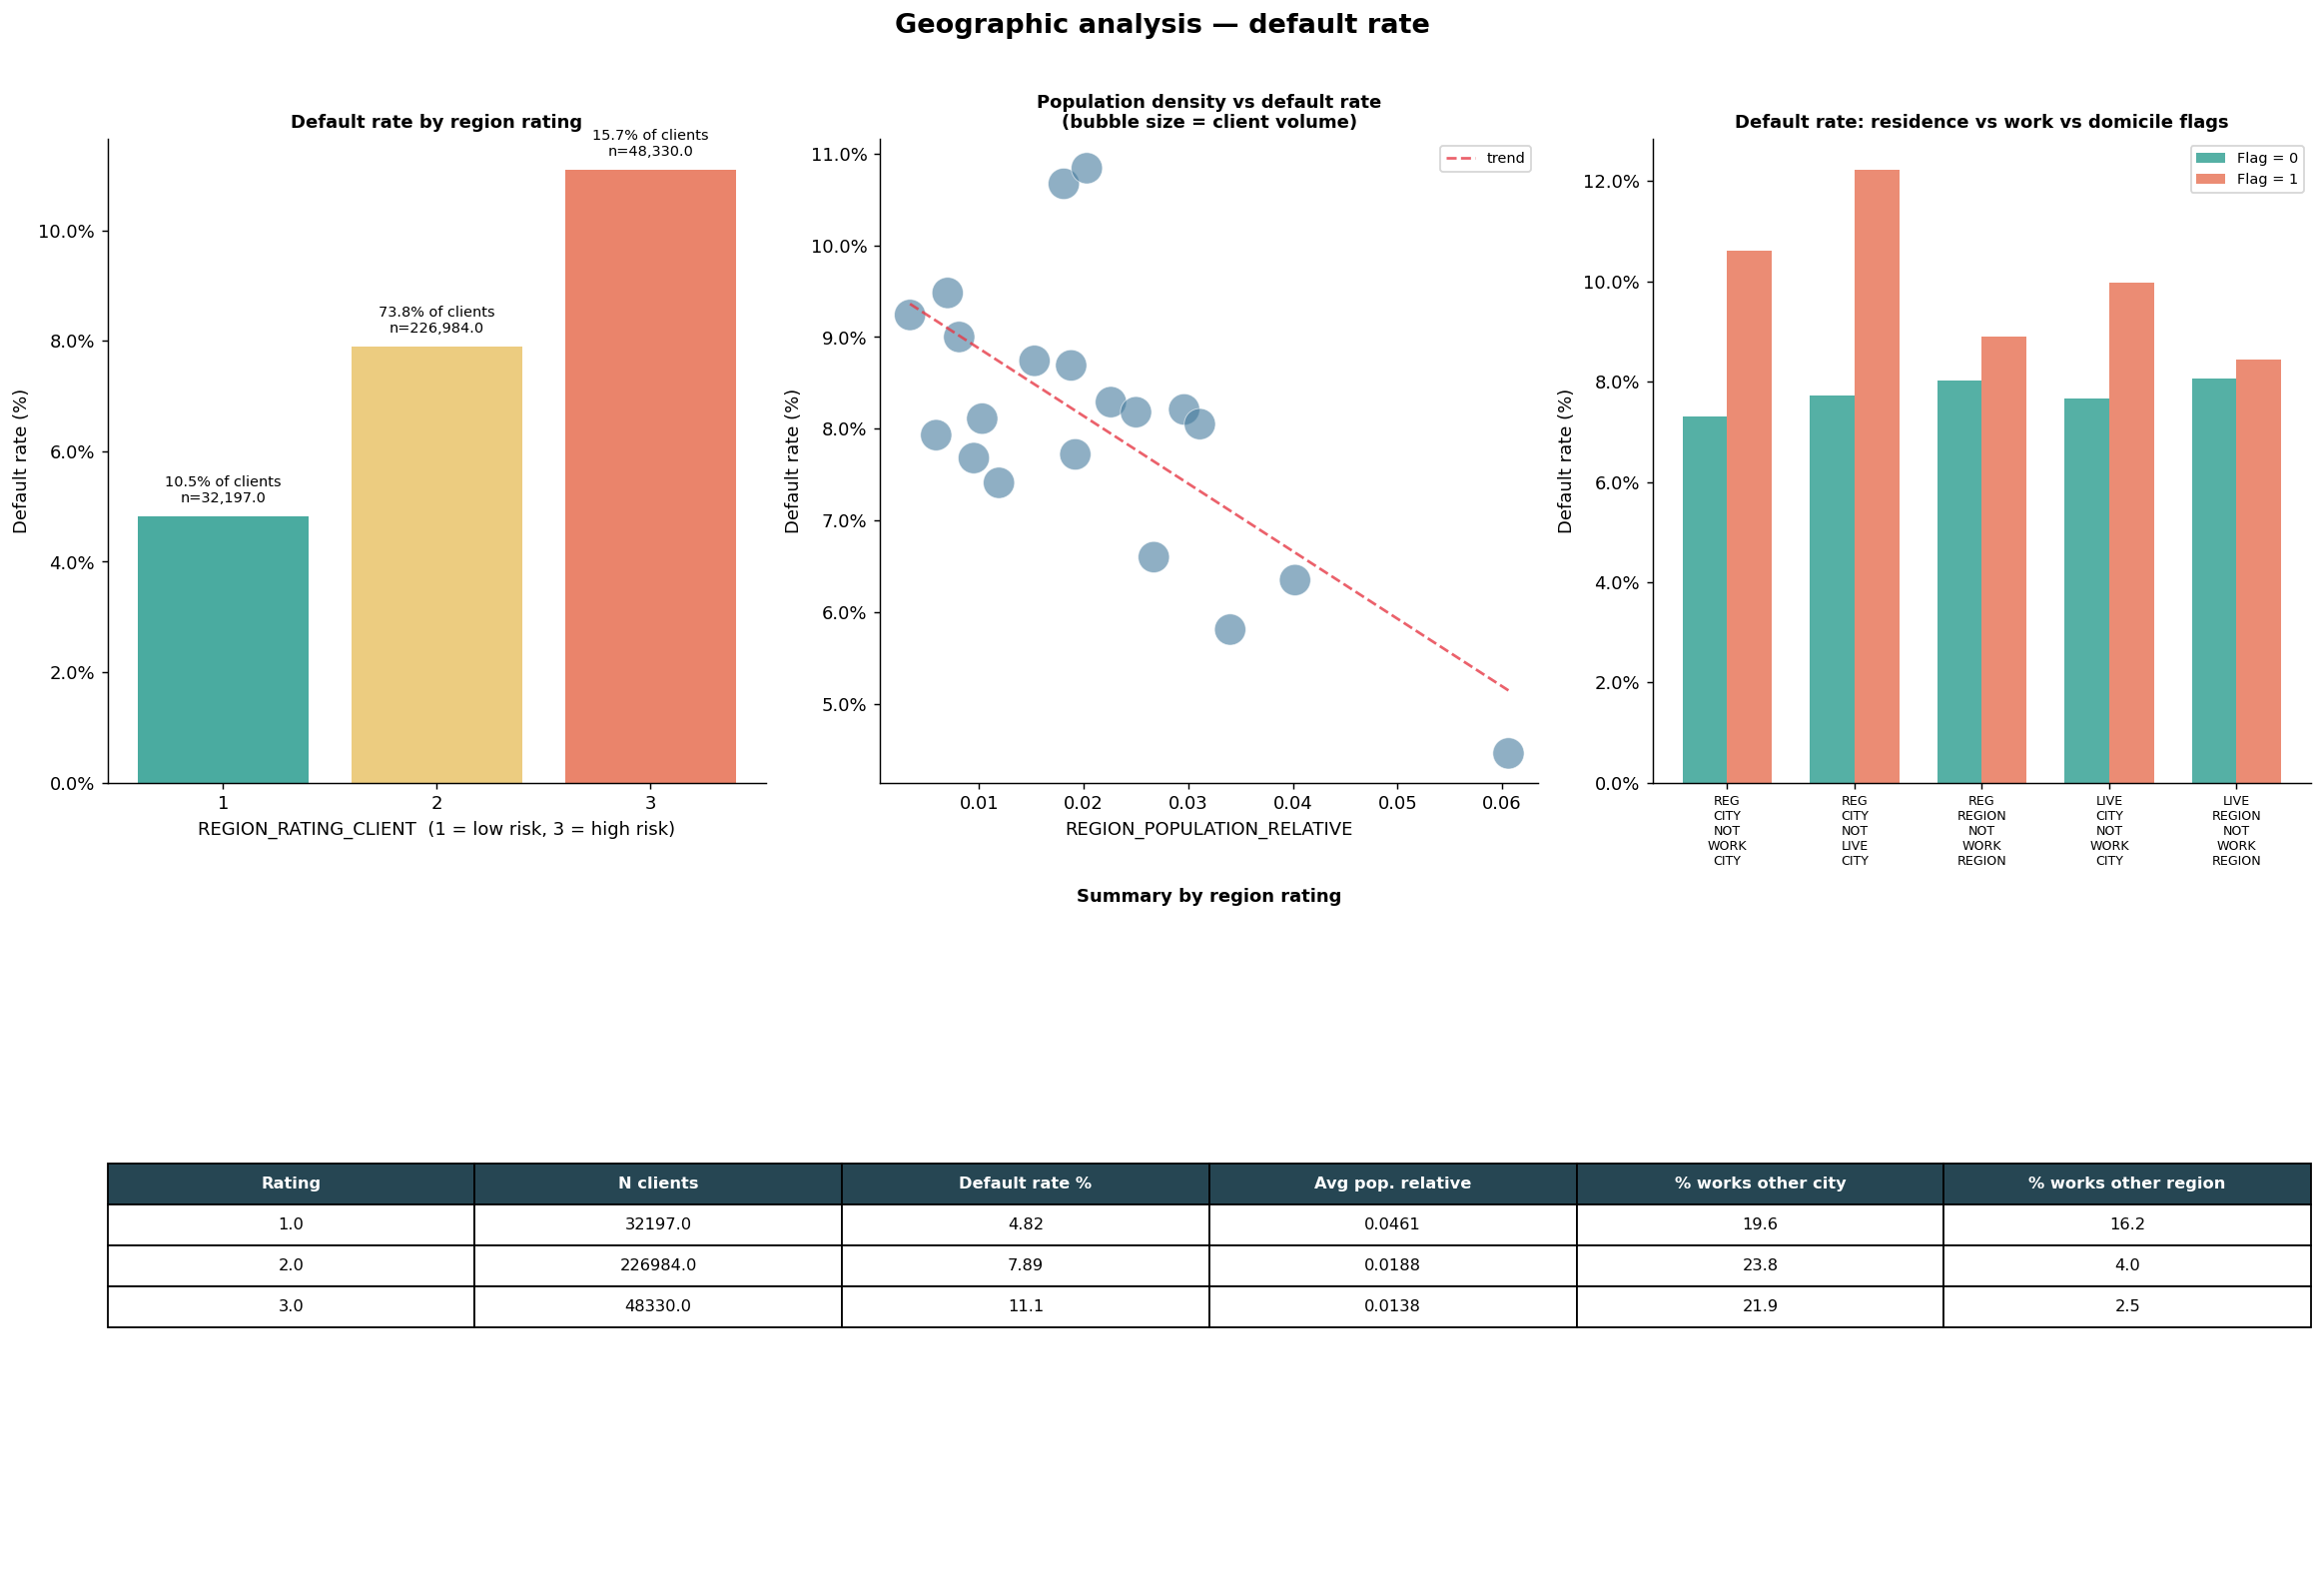

Saved: eda_geo_analysis.png


In [46]:
GEO_FEATURES = [
    "REGION_POPULATION_RELATIVE",
    "REGION_RATING_CLIENT",
    "REGION_RATING_CLIENT_W_CITY",
    "REG_CITY_NOT_WORK_CITY",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_REGION_NOT_WORK_REGION",
    "LIVE_CITY_NOT_WORK_CITY",
    "LIVE_REGION_NOT_WORK_REGION",
]

MOBILITY_FLAGS = [
    "REG_CITY_NOT_WORK_CITY",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_REGION_NOT_WORK_REGION",
    "LIVE_CITY_NOT_WORK_CITY",
    "LIVE_REGION_NOT_WORK_REGION",
]

def plot_geo_analysis(con):
    """
    Three panels:
      A) Default rate by REGION_RATING_CLIENT (ordinal, most interpretable)
      B) Scatter: population density vs default rate (bubble size = volume)
      C) Default rate by geographic mobility flags (flag=0 vs flag=1)
      D) Summary table by region rating
    """
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("Geographic analysis — default rate",
                 fontsize=15, fontweight='bold', y=1.01)

    # ── A) Default rate by REGION_RATING_CLIENT ───────────────────────
    ax1 = fig.add_subplot(2, 3, 1)

    df_rating = con.execute("""
        SELECT
            REGION_RATING_CLIENT                        AS rating,
            ROUND(AVG(TARGET) * 100, 2)                 AS default_rate_pct,
            COUNT(*)                                    AS n_obs,
            ROUND(COUNT(*) * 100.0
                  / SUM(COUNT(*)) OVER (), 1)           AS pct_population
        FROM app_train
        WHERE REGION_RATING_CLIENT IS NOT NULL
          AND TARGET IS NOT NULL
        GROUP BY rating
        ORDER BY rating
    """).fetchdf()

    colors = ['#2a9d8f', '#e9c46a', '#e76f51']
    bars = ax1.bar(df_rating['rating'].astype(str),
                   df_rating['default_rate_pct'],
                   color=colors[:len(df_rating)], alpha=0.85)

    for bar, (_, row) in zip(bars, df_rating.iterrows()):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.2,
                 f"{row['pct_population']:.1f}% of clients\nn={row['n_obs']:,}",
                 ha='center', va='bottom', fontsize=8)

    ax1.set_title("Default rate by region rating", fontsize=10, fontweight='bold')
    ax1.set_xlabel("REGION_RATING_CLIENT  (1 = low risk, 3 = high risk)")
    ax1.set_ylabel("Default rate (%)")
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))

    # ── B) Population density vs default rate (bubble chart) ─────────
    ax2 = fig.add_subplot(2, 3, 2)

    df_pop = con.execute("""
        WITH binned AS (
            SELECT
                TARGET,
                REGION_POPULATION_RELATIVE,
                NTILE(20) OVER (ORDER BY REGION_POPULATION_RELATIVE) AS bin
            FROM app_train
            WHERE REGION_POPULATION_RELATIVE IS NOT NULL
              AND TARGET IS NOT NULL
        )
        SELECT
            ROUND(AVG(REGION_POPULATION_RELATIVE), 4)  AS pop_rel,
            ROUND(AVG(TARGET) * 100, 2)                AS default_rate_pct,
            COUNT(*)                                   AS n_obs
        FROM binned
        GROUP BY bin
        ORDER BY bin
    """).fetchdf()

    ax2.scatter(df_pop['pop_rel'],
                df_pop['default_rate_pct'],
                s=df_pop['n_obs'] / df_pop['n_obs'].max() * 300,
                alpha=0.6, color='#457b9d',
                edgecolors='white', linewidth=0.5)

    # Trend line
    z = np.polyfit(df_pop['pop_rel'], df_pop['default_rate_pct'], deg=1)
    x_line = np.linspace(df_pop['pop_rel'].min(), df_pop['pop_rel'].max(), 100)
    ax2.plot(x_line, np.poly1d(z)(x_line),
             color='#e63946', linewidth=1.5,
             linestyle='--', alpha=0.8, label='trend')

    ax2.set_title("Population density vs default rate\n(bubble size = client volume)",
                  fontsize=10, fontweight='bold')
    ax2.set_xlabel("REGION_POPULATION_RELATIVE")
    ax2.set_ylabel("Default rate (%)")
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax2.legend(fontsize=8)

    # ── C) Geographic mobility flags ─────────────────────────────────
    ax3 = fig.add_subplot(2, 3, 3)

    rows = []
    for flag in MOBILITY_FLAGS:
        df_flag = con.execute(f"""
            SELECT
                {flag}                          AS flag_value,
                ROUND(AVG(TARGET) * 100, 2)     AS default_rate_pct,
                COUNT(*)                        AS n_obs
            FROM app_train
            WHERE {flag} IS NOT NULL
              AND TARGET IS NOT NULL
            GROUP BY flag_value
            ORDER BY flag_value
        """).fetchdf()

        for _, row in df_flag.iterrows():
            rows.append({
                "flag":         flag,
                "flag_value":   int(row['flag_value']),
                "default_rate": row['default_rate_pct'],
            })

    df_mob = pd.DataFrame(rows)
    df_0   = df_mob[df_mob['flag_value'] == 0].set_index('flag')
    df_1   = df_mob[df_mob['flag_value'] == 1].set_index('flag')

    x      = np.arange(len(MOBILITY_FLAGS))
    width  = 0.35
    labels = [f.replace("_", "\n") for f in MOBILITY_FLAGS]

    ax3.bar(x - width/2,
            [df_0.loc[f, 'default_rate'] for f in MOBILITY_FLAGS],
            width, label='Flag = 0', color='#2a9d8f', alpha=0.8)
    ax3.bar(x + width/2,
            [df_1.loc[f, 'default_rate'] for f in MOBILITY_FLAGS],
            width, label='Flag = 1', color='#e76f51', alpha=0.8)

    ax3.set_xticks(x)
    ax3.set_xticklabels(labels, fontsize=7)
    ax3.set_title("Default rate: residence vs work vs domicile flags",
                  fontsize=10, fontweight='bold')
    ax3.set_ylabel("Default rate (%)")
    ax3.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax3.legend(fontsize=8)

    # ── D) Summary table by region rating ────────────────────────────
    ax4 = fig.add_subplot(2, 1, 2)
    ax4.axis('off')

    summary = con.execute("""
        SELECT
            REGION_RATING_CLIENT                            AS rating,
            COUNT(*)                                        AS n_clients,
            ROUND(AVG(TARGET) * 100, 2)                     AS default_rate_pct,
            ROUND(AVG(REGION_POPULATION_RELATIVE), 4)       AS avg_pop_relative,
            ROUND(AVG(REG_CITY_NOT_WORK_CITY) * 100, 1)     AS pct_works_other_city,
            ROUND(AVG(REG_REGION_NOT_WORK_REGION) * 100, 1) AS pct_works_other_region
        FROM app_train
        WHERE REGION_RATING_CLIENT IS NOT NULL
          AND TARGET IS NOT NULL
        GROUP BY rating
        ORDER BY rating
    """).fetchdf()

    summary.columns = [
        "Rating", "N clients", "Default rate %",
        "Avg pop. relative", "% works other city", "% works other region"
    ]

    tbl = ax4.table(
        cellText=summary.values,
        colLabels=summary.columns,
        cellLoc='center', loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)

    for j in range(len(summary.columns)):
        tbl[(0, j)].set_facecolor('#264653')
        tbl[(0, j)].set_text_props(color='white', fontweight='bold')

    ax4.set_title("Summary by region rating",
                  fontsize=10, fontweight='bold', pad=12)

    plt.tight_layout()
    plt.savefig("eda_geo_analysis.png", bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: eda_geo_analysis.png")

plot_geo_analysis(con)

- Region Rating Impact: There is a strong linear correlation between the internal region rating and default probability. Clients in 'Rating 3' areas are more than twice as likely to default compared to 'Rating 1'.

- Urban vs Rural Risk: Higher population density is inversely correlated with default rates, suggesting that urban economic hubs provide better financial stability for applicants.

- Geographic Mismatch: Mismatches between registered, residential, and work locations (especially city-level discrepancies) are strong indicators of increased risk, potentially signaling lower stability or more complex living situations.

#### Missing Blocks Heatmap

Columns with >= 1.0% missing: 57 / 121


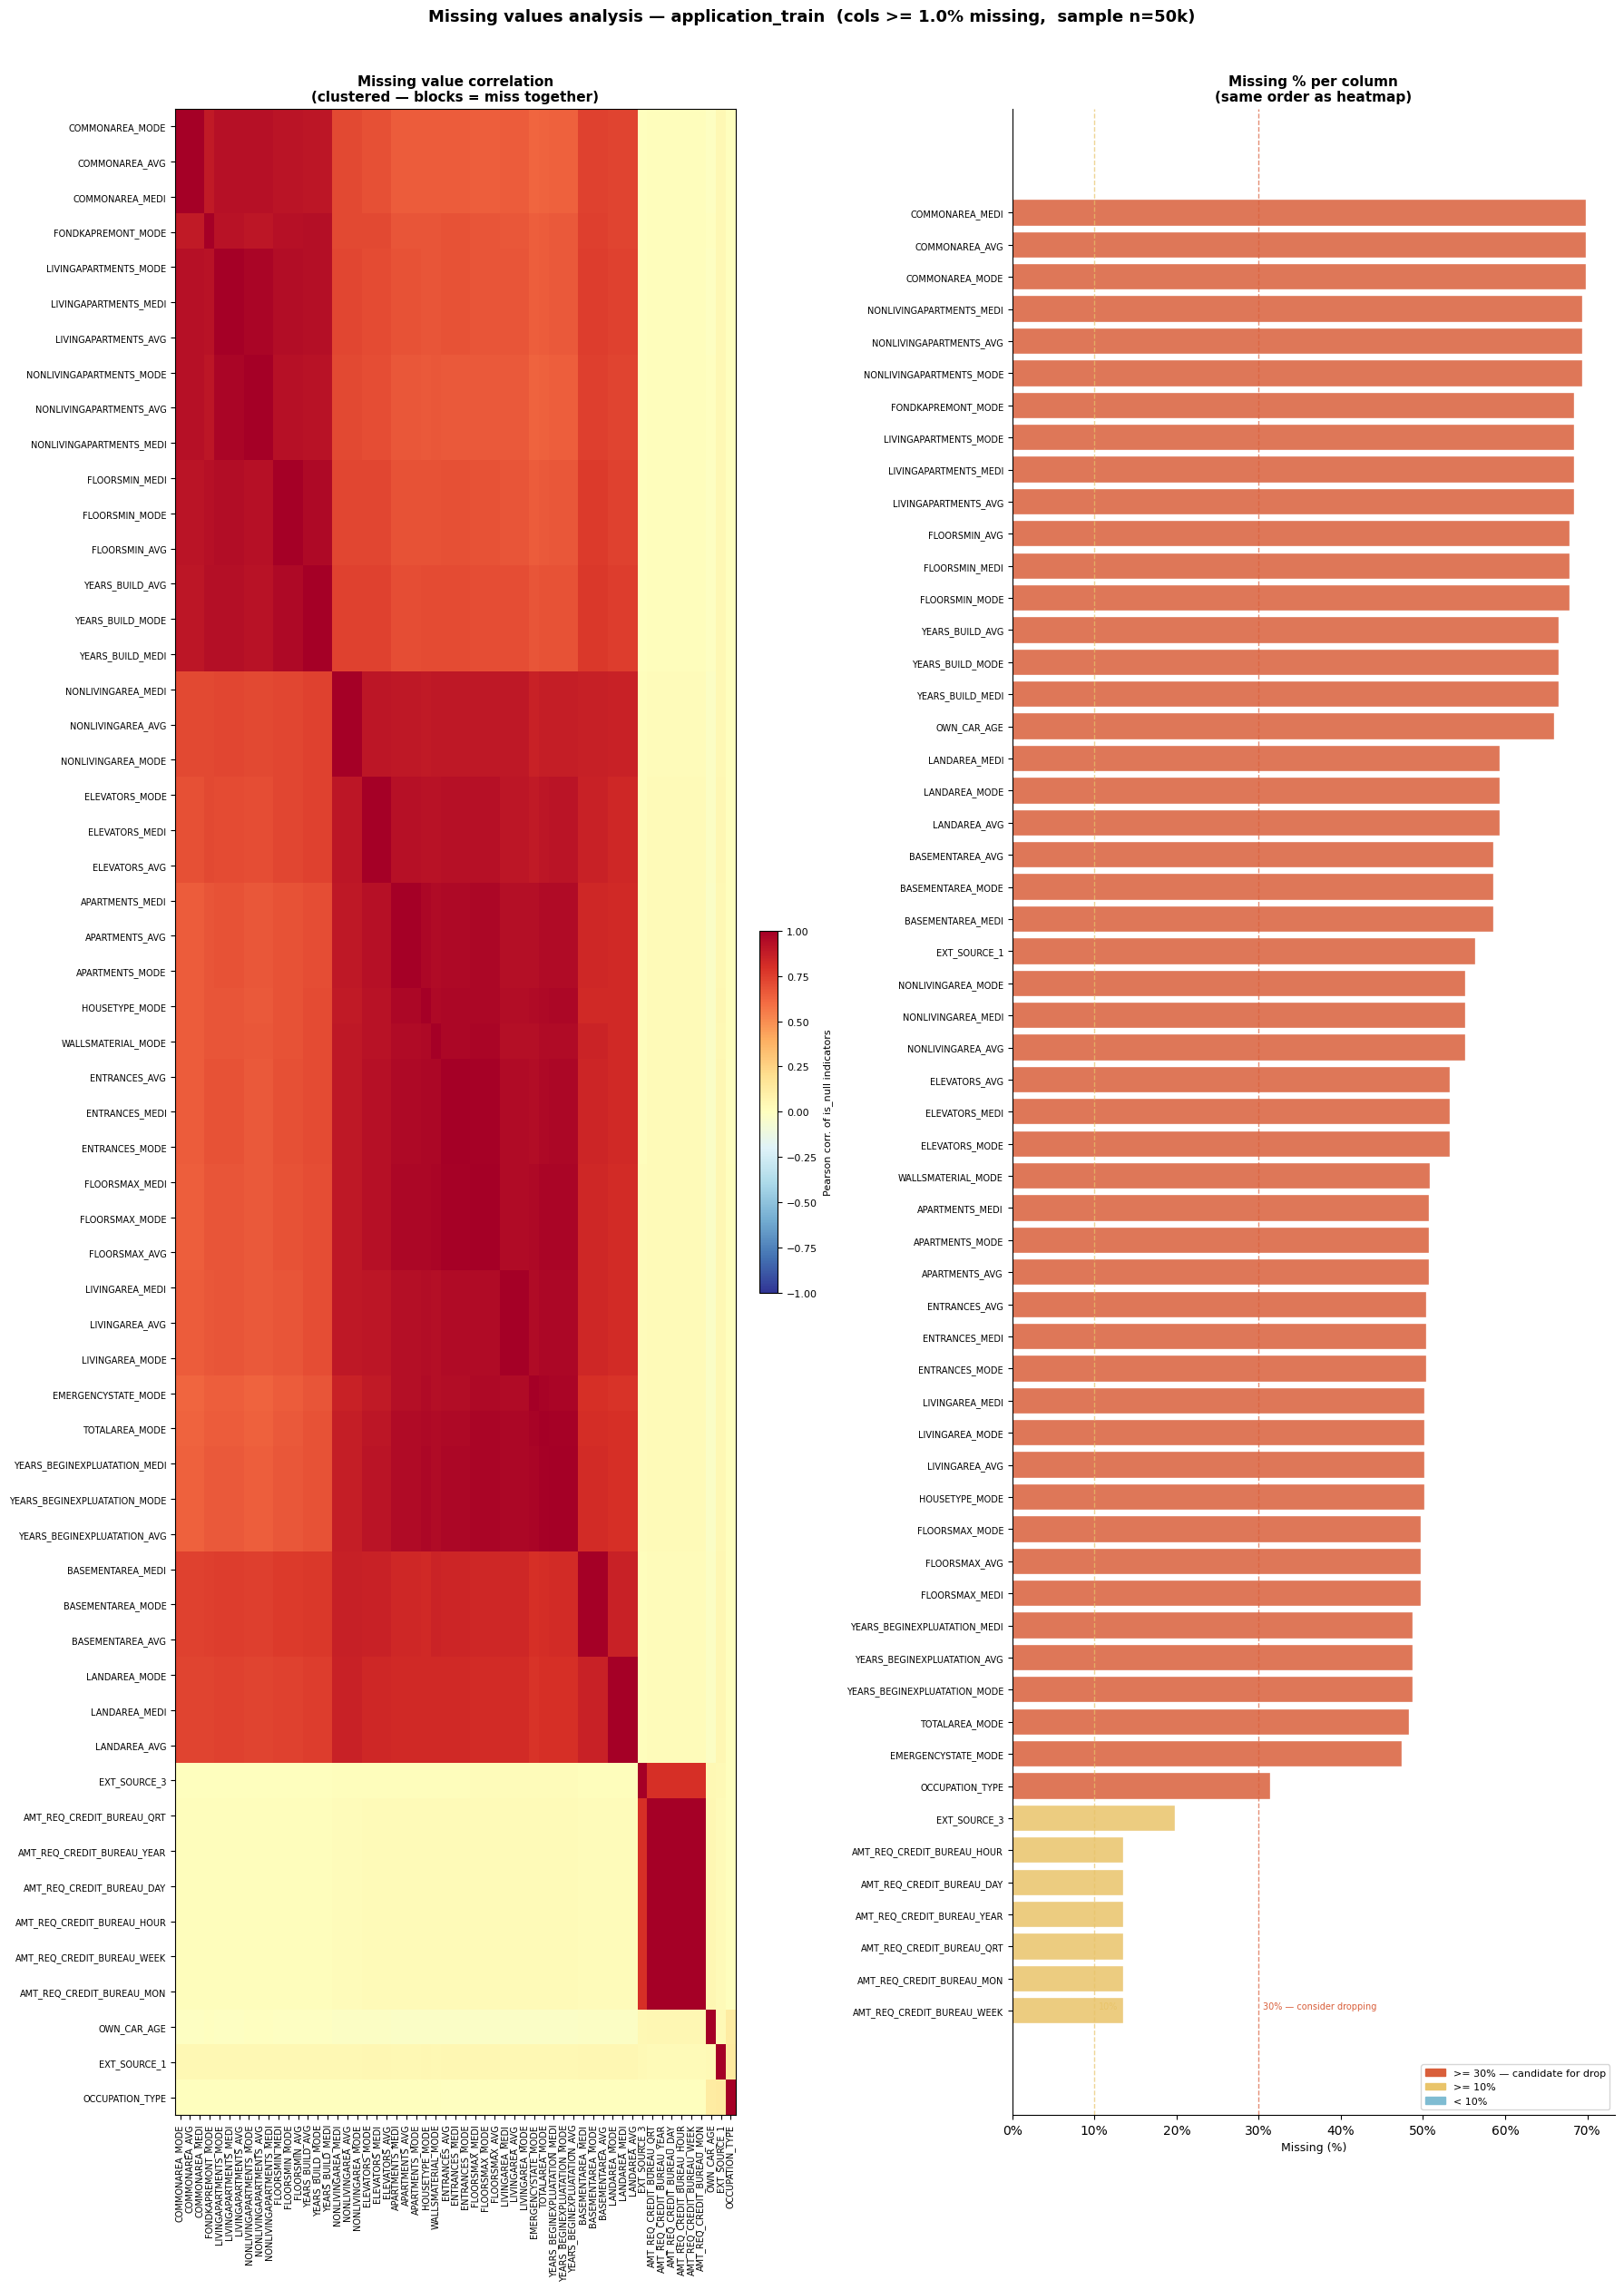

Saved: eda_missing_heatmap.png

High-correlation missing blocks (|corr| > 0.8):
  COMMONAREA_MODE                           ↔  COMMONAREA_AVG                            corr=1.00
  COMMONAREA_MODE                           ↔  COMMONAREA_MEDI                           corr=1.00
  COMMONAREA_MODE                           ↔  FONDKAPREMONT_MODE                        corr=0.89
  COMMONAREA_MODE                           ↔  LIVINGAPARTMENTS_MODE                     corr=0.93
  COMMONAREA_MODE                           ↔  LIVINGAPARTMENTS_MEDI                     corr=0.93
  COMMONAREA_MODE                           ↔  LIVINGAPARTMENTS_AVG                      corr=0.93
  COMMONAREA_MODE                           ↔  NONLIVINGAPARTMENTS_MODE                  corr=0.93
  COMMONAREA_MODE                           ↔  NONLIVINGAPARTMENTS_AVG                   corr=0.93
  COMMONAREA_MODE                           ↔  NONLIVINGAPARTMENTS_MEDI                  corr=0.93
  COMMONAREA_MODE            

In [5]:
def plot_missing_heatmap(con, min_missing_pct: float = 1.0):
    """
    Two-panel missing values analysis:
      A) Heatmap of missing correlation across columns — reveals if columns
         miss together (i.e. missing in the same rows), which means the
         missingness is structural, not random.
      B) Bar chart of missing % per column (only cols above threshold).

    Only columns with at least min_missing_pct % missing are included —
    avoids a huge sparse matrix with mostly-complete columns.
    """

    # ── 1. Identify columns with meaningful missing rate ─────────────
    col_info = con.execute("DESCRIBE app_train").fetchdf()
    all_cols = col_info['column_name'].tolist()
    all_cols = [c for c in all_cols if c != 'TARGET']

    n_rows = con.execute("SELECT COUNT(*) FROM app_train").fetchone()[0]

    # Build a single query to get missing count for every column at once
    missing_exprs = ",\n".join(
        f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS \"{c}\""
        for c in all_cols
    )
    missing_counts = con.execute(
        f"SELECT {missing_exprs} FROM app_train"
    ).fetchdf()

    missing_pct = (missing_counts / n_rows * 100).iloc[0].sort_values(ascending=False)
    cols_with_missing = missing_pct[missing_pct >= min_missing_pct].index.tolist()

    print(f"Columns with >= {min_missing_pct}% missing: {len(cols_with_missing)} / {len(all_cols)}")

    if not cols_with_missing:
        print("No columns above threshold.")
        return

    # ── 2. Load binary missing matrix (1 = missing, 0 = present) ─────
    # Sample up to 50k rows to keep memory under control
    sample_exprs = ", ".join(
        f"CASE WHEN \"{c}\" IS NULL THEN 1 ELSE 0 END AS \"{c}\""
        for c in cols_with_missing
    )
    df_missing = con.execute(f"""
        SELECT {sample_exprs}
        FROM app_train
        USING SAMPLE 50000 ROWS
    """).fetchdf()

    # ── 3. Correlation matrix of missingness patterns ─────────────────
    # corr(is_null_A, is_null_B) = 1 means "A and B always miss together"
    corr_matrix = df_missing.corr()

    # ── 4. Cluster columns by missingness similarity ──────────────────
    # Reorder columns so that columns that miss together appear adjacent
    from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
    from scipy.spatial.distance import squareform

    distance   = 1 - corr_matrix.abs()
    distance   = (distance + distance.T) / 2 
    distance_arr = distance.values.copy()          # make a writable copy
    np.fill_diagonal(distance_arr, 0)
    condensed    = squareform(distance_arr.clip(0))
    linkage_matrix = linkage(condensed, method='average')
    order      = leaves_list(linkage_matrix)
    sorted_cols = [cols_with_missing[i] for i in order]

    corr_sorted = corr_matrix.loc[sorted_cols, sorted_cols]

    # ── 5. Plot ───────────────────────────────────────────────────────
    n = len(sorted_cols)
    fig = plt.figure(figsize=(18, max(8, n * 0.35 + 5)))

    # Panel A — heatmap
    ax1 = fig.add_subplot(1, 2, 1)
    im  = ax1.imshow(corr_sorted.values, cmap='RdYlBu_r',
                     vmin=-1, vmax=1, aspect='auto', interpolation='none')

    ax1.set_xticks(range(n))
    ax1.set_yticks(range(n))
    ax1.set_xticklabels(sorted_cols, rotation=90, fontsize=7)
    ax1.set_yticklabels(sorted_cols, fontsize=7)
    ax1.set_title(
        "Missing value correlation\n(clustered — blocks = miss together)",
        fontsize=11, fontweight='bold'
    )

    cbar = plt.colorbar(im, ax=ax1, fraction=0.03, pad=0.04)
    cbar.set_label("Pearson corr. of is_null indicators", fontsize=8)
    cbar.ax.tick_params(labelsize=8)

    # Overlay correlation values for small matrices
    if n <= 25:
        for i in range(n):
            for j in range(n):
                val = corr_sorted.values[i, j]
                if i != j and abs(val) > 0.3:
                    ax1.text(j, i, f"{val:.2f}",
                             ha='center', va='center',
                             fontsize=6,
                             color='white' if abs(val) > 0.6 else 'black')

    # Panel B — missing % bar chart
    ax2 = fig.add_subplot(1, 2, 2)

    pct_sorted = missing_pct[sorted_cols].sort_values(ascending=True)
    colors     = ['#d95f3b' if v >= 30 else '#e9c46a' if v >= 10 else '#7fbcd2'
                  for v in pct_sorted.values]

    ax2.barh(pct_sorted.index, pct_sorted.values,
             color=colors, alpha=0.85, edgecolor='white', linewidth=0.3)

    # Threshold reference lines
    for thresh, label, color in [(30, "30% — consider dropping", '#d95f3b'),
                                 (10, "10%",                      '#e9c46a')]:
        ax2.axvline(thresh, color=color, linewidth=1,
                    linestyle='--', alpha=0.7)
        ax2.text(thresh + 0.5, 0, label,
                 fontsize=7, color=color, va='bottom')

    ax2.set_xlabel("Missing (%)", fontsize=9)
    ax2.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax2.set_title("Missing % per column\n(same order as heatmap)",
                  fontsize=11, fontweight='bold')
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.tick_params(axis='y', labelsize=7)

    # Legend
    from matplotlib.patches import Patch
    ax2.legend(handles=[
        Patch(color='#d95f3b', label='>= 30% — candidate for drop'),
        Patch(color='#e9c46a', label='>= 10%'),
        Patch(color='#7fbcd2', label='< 10%'),
    ], fontsize=8, loc='lower right')

    plt.suptitle(
        f"Missing values analysis — application_train  "
        f"(cols >= {min_missing_pct}% missing,  sample n=50k)",
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig("eda_missing_heatmap.png", bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: eda_missing_heatmap.png")

    # ── 6. Print detected blocks ──────────────────────────────────────
    print("\nHigh-correlation missing blocks (|corr| > 0.8):")
    reported = set()
    for i, c1 in enumerate(sorted_cols):
        for j, c2 in enumerate(sorted_cols):
            if i >= j:
                continue
            val = corr_matrix.loc[c1, c2]
            if abs(val) >= 0.8 and (c1, c2) not in reported:
                print(f"  {c1:<40}  ↔  {c2:<40}  corr={val:.2f}")
                reported.add((c1, c2))

plot_missing_heatmap(con, min_missing_pct=1.0)

The visualization above highlights several critical patterns regarding data integrity and relationships between missing features:

- Structural Nulls (Building/Housing Data): A significant cluster of features related to the applicant's residence (e.g., APARTMENTS_AVG, ELEVATORS_MODE, LIVINGAREA_MEDI) shows a near-perfect correlation in missingness. This indicates that when one value is missing, the entire block is missing, likely because the information wasn't applicable or provided for certain housing types.

- High-Cardinality Missingness: Several columns exceed a 45-50% missing rate (highlighted in orange). These features are candidates for removal during feature engineering to avoid introducing excessive noise through imputation.

- Independent Critical Features: Key external risk indicators like EXT_SOURCE_1 and EXT_SOURCE_3 show independent missing patterns. Their presence or absence is not tied to the housing data cluster, suggesting they capture different dimensions of the applicant's profile and require specific handling.

## Specific columns analysis

### EXT_SOURCE 

In [22]:
# Count total rows and missing values for specific columns
null_query = """
    SELECT 
        COUNT(*) AS total_applicants,
        COUNT(*) - COUNT(AMT_INCOME_TOTAL) AS missing_income,
        COUNT(*) - COUNT(EXT_SOURCE_1) AS missing_ext_source_1,
        COUNT(*) - COUNT(EXT_SOURCE_2) AS missing_ext_source_2,
        COUNT(*) - COUNT(EXT_SOURCE_3) AS missing_ext_source_3
    FROM app_train;
"""

# Execute and display the result
df_nulls = con.execute(null_query).df()
display(df_nulls)

,total_applicants,missing_income,missing_ext_source_1,missing_ext_source_2,missing_ext_source_3
0,307511,0,173378,660,60965


In [23]:
# Calculate default rates based on missing data
missingness_query = """
    SELECT
        CASE 
            WHEN EXT_SOURCE_1 IS NULL THEN 'Missing Score'
            ELSE 'Has Score'
        END AS ext_source_1_status,
        COUNT(*) AS total_applicants,
        AVG(TARGET) AS default_rate
    FROM app_train
    GROUP BY 
        ext_source_1_status;
"""

# Execute and display the result
df_missingness = con.execute(missingness_query).df()
display(df_missingness)

,ext_source_1_status,total_applicants,default_rate
0,Missing Score,173378,0.085195
1,Has Score,134133,0.074955


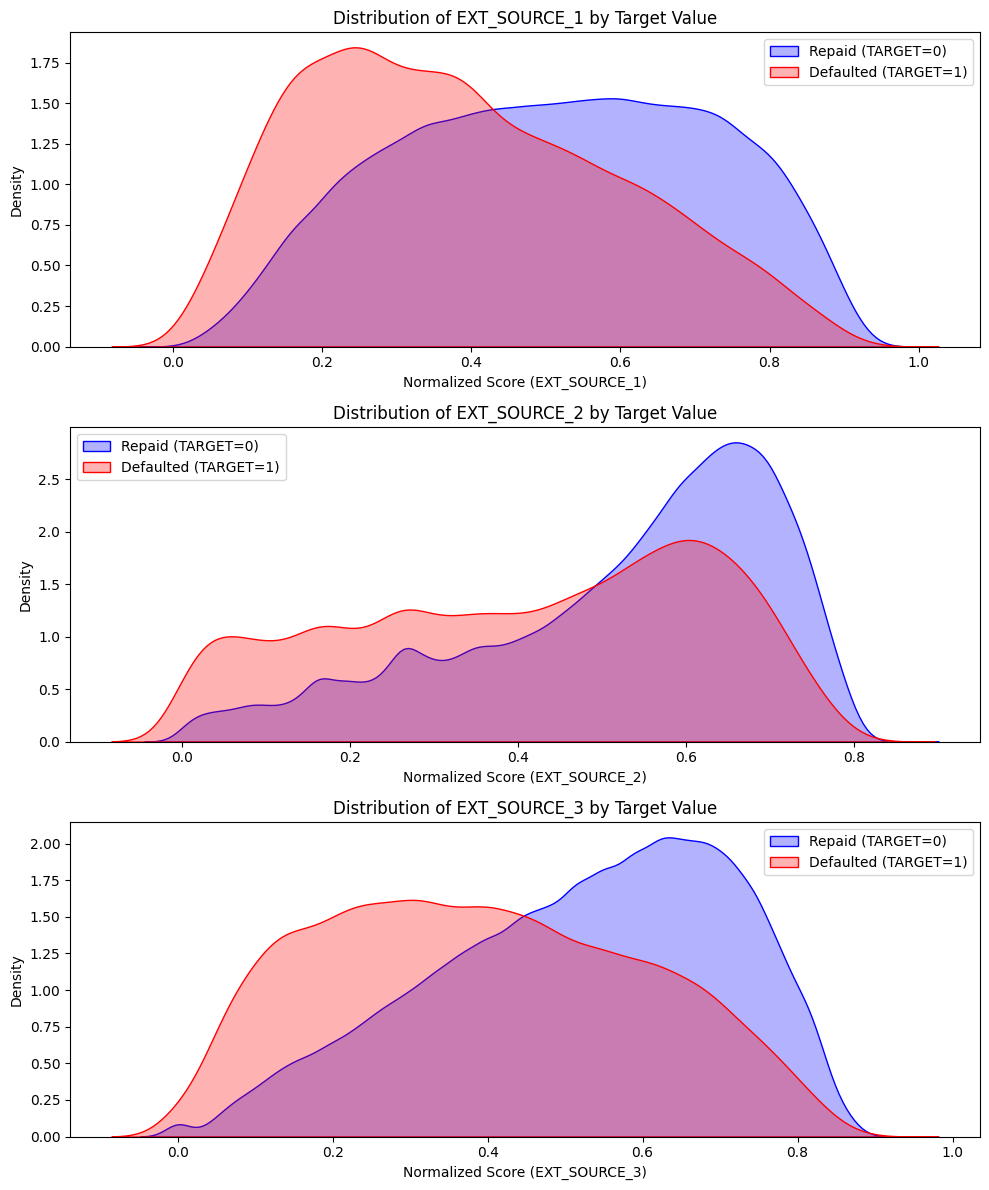

In [12]:
# Kernel Density Estimation (KDE) plots for EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Query ONLY the required columns to prevent MemoryError
query_kde = """
    SELECT 
        TARGET, 
        EXT_SOURCE_1, 
        EXT_SOURCE_2, 
        EXT_SOURCE_3
    FROM app_train;
"""

# 2. Execute the query and store it in a lightweight DataFrame
df_kde = con.execute(query_kde).df()

# 3. Define the features we want to analyze
key_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# 4. Set up the matplotlib figure layout
plt.figure(figsize=(10, 12))

# 5. Iterate through each feature to generate stacked Kernel Density Estimation (KDE) plots
for i, feature in enumerate(key_features):
    plt.subplot(3, 1, i + 1)
    
    # Plot the probability density for applicants who repaid their loans (TARGET == 0)
    sns.kdeplot(
        data=df_kde[df_kde['TARGET'] == 0][feature].dropna(), 
        label='Repaid (TARGET=0)', 
        color='blue', 
        fill=True, 
        alpha=0.3
    )
    
    # Plot the probability density for applicants who defaulted (TARGET == 1)
    sns.kdeplot(
        data=df_kde[df_kde['TARGET'] == 1][feature].dropna(), 
        label='Defaulted (TARGET=1)', 
        color='red', 
        fill=True, 
        alpha=0.3
    )
    
    # Format the plot for professional presentation
    plt.title(f'Distribution of {feature} by Target Value')
    plt.xlabel(f'Normalized Score ({feature})')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

### DAYS_EMPLOYED

In [13]:
birth_query = """
SELECT MIN(DAYS_BIRTH), MAX(DAYS_BIRTH) 
FROM app_train;
"""

df_min_max = con.execute(birth_query).df()
display(df_min_max)

,min(DAYS_BIRTH),max(DAYS_BIRTH)
0,-25229,-7489


In [24]:
min_max_query = """
SELECT MIN(DAYS_EMPLOYED), MAX(DAYS_EMPLOYED) 
FROM app_train;
"""

df_min_max = con.execute(min_max_query).df()
display(df_min_max)

,min(DAYS_EMPLOYED),max(DAYS_EMPLOYED)
0,-17912,365243


In [25]:
income_type_query = """
    SELECT NAME_INCOME_TYPE, COUNT(*)
    FROM app_train
    WHERE DAYS_EMPLOYED = 365243
    GROUP BY NAME_INCOME_TYPE;
    """
df_income_type = con.execute(income_type_query).df()
display(df_income_type)

,NAME_INCOME_TYPE,count_star()
0,Unemployed,22
1,Pensioner,55352


In [26]:
impact_query = """
SELECT 
    CASE WHEN DAYS_EMPLOYED = 365243 THEN 'Anomalous' ELSE 'Regular' END AS status,
    COUNT(*) AS total_clients,
    AVG(TARGET) AS default_rate
FROM app_train
GROUP BY status;
"""

df_impact = con.execute(impact_query).df()
display(df_impact)

,status,total_clients,default_rate
0,Regular,252137,0.086600
1,Anomalous,55374,0.053996


In [27]:
# Query to check the cleaning of DAYS_EMPLOYED
query_days_clean = """
    SELECT 
        SK_ID_CURR,
        DAYS_EMPLOYED,
        CASE
            WHEN DAYS_EMPLOYED = 365243 THEN NULL 
            ELSE DAYS_EMPLOYED 
        END AS DAYS_EMPLOYED_CLEAN,
        CASE 
            WHEN DAYS_EMPLOYED = 365243 THEN TRUE 
            ELSE FALSE 
        END AS IS_DAYS_EMPLOYED_ANOM
    FROM app_train
    LIMIT 10;
"""

df_days_check = con.execute(query_days_clean).df()
display(df_days_check)

,SK_ID_CURR,DAYS_EMPLOYED,DAYS_EMPLOYED_CLEAN,IS_DAYS_EMPLOYED_ANOM
0,100002,-637,-637,False
1,100003,-1188,-1188,False
2,100004,-225,-225,False
3,100006,-3039,-3039,False
4,100007,-3038,-3038,False
5,100008,-1588,-1588,False
6,100009,-3130,-3130,False
7,100010,-449,-449,False
8,100011,365243,<NA>,True
9,100012,-2019,-2019,False


In [28]:
verification_query = """
SELECT 
    NAME_INCOME_TYPE, 
    COUNT(*) AS total,
    AVG(CASE WHEN DAYS_EMPLOYED = 365243 THEN 1 ELSE 0 END) AS ratio_anomali
FROM app_train
GROUP BY NAME_INCOME_TYPE;
"""

df_verification = con.execute(verification_query).df()
display(df_verification)

,NAME_INCOME_TYPE,total,ratio_anomali
0,Pensioner,55362,0.999819
1,State servant,21703,0.000000
2,Unemployed,22,1.000000
3,Working,158774,0.000000
4,Student,18,0.000000
5,Maternity leave,5,0.000000
6,Commercial associate,71617,0.000000
7,Businessman,10,0.000000


### EDUCATION_TYPE

In [15]:
# See what types of values a column has
con.execute("SELECT DISTINCT NAME_EDUCATION_TYPE FROM app_train;").df()

,NAME_EDUCATION_TYPE
0,Incomplete higher
1,Academic degree
2,Secondary / secondary special
3,Higher education
4,Lower secondary


In [16]:
# See what types of values a column has and their counts
query_edu = """
SELECT 
    NAME_EDUCATION_TYPE, 
    COUNT(*) AS count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM app_train), 2) AS percentage
FROM app_train
GROUP BY NAME_EDUCATION_TYPE
ORDER BY count DESC;
"""
display(con.execute(query_edu).df())

,NAME_EDUCATION_TYPE,count,percentage
0,Secondary / secondary special,218391,71.02
1,Higher education,74863,24.34
2,Incomplete higher,10277,3.34
3,Lower secondary,3816,1.24
4,Academic degree,164,0.05


In [20]:
def analyze_categorical(column_name):
    query = f"""
    SELECT 
        {column_name}, 
        COUNT(*) AS number_of_applicants,
        ROUND(AVG(TARGET), 2) AS default_rate,
    FROM app_train
    GROUP BY {column_name}
    ORDER BY default_rate DESC;
    """
    return con.execute(query).df()

# Who is more risky based on education type?
display(analyze_categorical('NAME_EDUCATION_TYPE'))

,NAME_EDUCATION_TYPE,number_of_applicants,default_rate
0,Lower secondary,3816,0.11
1,Secondary / secondary special,218391,0.09
2,Incomplete higher,10277,0.08
3,Higher education,74863,0.05
4,Academic degree,164,0.02


### OCCUPATION_TYPE

In [ ]:
occupation_query = """
SELECT
    OCCUPATION_TYPE,
    COUNT(*) AS total_applicants
FROM app_train
GROUP BY OCCUPATION_TYPE;
"""

occupation_df = con.execute(occupation_query).df()
display(occupation_df)

,OCCUPATION_TYPE,total_applicants
0,High skill tech staff,11380
1,Cooking staff,5946
2,Secretaries,1305
3,Managers,21371
4,Laborers,55186
5,Cleaning staff,4653
6,Medicine staff,8537
7,Accountants,9813
8,Drivers,18603
9,Security staff,6721


In [30]:
# Replace NaNs with 'Not specified'
query_occ = """
SELECT 
    COALESCE(OCCUPATION_TYPE, 'Not Specified') AS occupation,
    COUNT(*) AS count,
    AVG(TARGET) AS default_rate
FROM app_train
GROUP BY occupation
ORDER BY default_rate DESC;
"""
display(con.execute(query_occ).df())

,occupation,count,default_rate
0,Low-skill Laborers,2093,0.171524
1,Drivers,18603,0.113261
2,Waiters/barmen staff,1348,0.112760
3,Security staff,6721,0.107424
4,Laborers,55186,0.105788
5,Cooking staff,5946,0.104440
6,Sales staff,32102,0.096318
7,Cleaning staff,4653,0.096067
8,Realty agents,751,0.078562
9,Secretaries,1305,0.070498


In [31]:
# Is there a correlation between income type and missing occupation?
cross_check_query = """
SELECT 
    NAME_INCOME_TYPE,
    COUNT(*) AS total_per_category,
    COUNT(OCCUPATION_TYPE) AS with_occupation,
    COUNT(*) - COUNT(OCCUPATION_TYPE) AS without_occupation,
    ROUND((COUNT(*) - COUNT(OCCUPATION_TYPE)) * 100.0 / COUNT(*), 2) AS percentage_null
FROM app_train
GROUP BY NAME_INCOME_TYPE
ORDER BY without_occupation DESC;
"""

df_cross = con.execute(cross_check_query).df()
display(df_cross)

,NAME_INCOME_TYPE,total_per_category,with_occupation,without_occupation,percentage_null
0,Pensioner,55362,5,55357,99.99
1,Working,158774,133854,24920,15.70
2,Commercial associate,71617,59320,12297,17.17
3,State servant,21703,17916,3787,17.45
4,Unemployed,22,0,22,100.00
5,Student,18,13,5,27.78
6,Businessman,10,8,2,20.00
7,Maternity leave,5,4,1,20.00


### FLAG_DOCUMENT

In [46]:
# ── 1. Get all FLAG_DOCUMENT_* columns ───────────────────────────────
flag_cols = con.execute("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_name = 'app_train'
      AND column_name LIKE 'FLAG_DOCUMENT_%'
    ORDER BY column_name
""").fetchdf()['column_name'].tolist()

print(f"Found {len(flag_cols)} FLAG_DOCUMENT columns: {flag_cols}")

Found 20 FLAG_DOCUMENT columns: ['FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9']


In [47]:
# ── 2. Core stats per flag ────────────────────────────────────────────
# For each binary flag:
#   - prevalence     : % of clients who provided that document
#   - default_rate   : default rate among those who DID provide it
#   - default_rate_0 : default rate among those who did NOT
#   - lift           : default_rate_1 / global_rate  (>1 = risky signal)
#   - point_biserial : correlation with TARGET (same as Pearson for binary)

global_rate = con.execute("""
    SELECT AVG(TARGET) FROM app_train WHERE TARGET IS NOT NULL
""").fetchone()[0]

rows = []
for col in flag_cols:
    r = con.execute(f"""
        SELECT
            ROUND(AVG(CAST({col} AS DOUBLE)) * 100, 2)    AS prevalence_pct,
            ROUND(AVG(CASE WHEN {col} = 1 THEN TARGET END) * 100, 2) AS dr_flag_1,
            ROUND(AVG(CASE WHEN {col} = 0 THEN TARGET END) * 100, 2) AS dr_flag_0,
            ROUND(CORR(CAST({col} AS DOUBLE),
                       CAST(TARGET AS DOUBLE)), 4)         AS point_biserial,
            COUNT(*)                                       AS n_total,
            SUM(CAST({col} AS INT))                        AS n_flag_1
        FROM app_train
        WHERE TARGET IS NOT NULL
          AND {col} IS NOT NULL
    """).fetchdf().iloc[0]

    rows.append({
        "flag":            col.replace("FLAG_DOCUMENT_", "DOC_"),
        "full_name":       col,
        "prevalence_pct":  r['prevalence_pct'],
        "n_flag_1":        int(r['n_flag_1']),
        "dr_flag_1":       r['dr_flag_1'],
        "dr_flag_0":       r['dr_flag_0'],
        "spread_pp":       round(r['dr_flag_1'] - r['dr_flag_0'], 2),
        "lift":            round(r['dr_flag_1'] / (global_rate * 100), 3),
        "point_biserial":  r['point_biserial'],
    })

df_flags = (pd.DataFrame(rows)
              .sort_values('point_biserial', ascending=False)
              .reset_index(drop=True))

print(f"\nGlobal default rate: {global_rate*100:.2f}%\n")
print(df_flags.to_string(index=False))


Global default rate: 8.07%

  flag        full_name  prevalence_pct  n_flag_1  dr_flag_1  dr_flag_0  spread_pp  lift  point_biserial
 DOC_3  FLAG_DOCUMENT_3           71.00    218340       8.84       6.18       2.66 1.095          0.0443
 DOC_2  FLAG_DOCUMENT_2            0.00        13      30.77       8.07      22.70 3.812          0.0054
DOC_21 FLAG_DOCUMENT_21            0.03       103      13.59       8.07       5.52 1.683          0.0037
DOC_20 FLAG_DOCUMENT_20            0.05       156       8.33       8.07       0.26 1.032          0.0002
 DOC_5  FLAG_DOCUMENT_5            1.51      4648       8.00       8.07      -0.07 0.991         -0.0003
DOC_12 FLAG_DOCUMENT_12            0.00         2       0.00       8.07      -8.07 0.000         -0.0008
DOC_10 FLAG_DOCUMENT_10            0.00         7       0.00       8.07      -8.07 0.000         -0.0014
DOC_19 FLAG_DOCUMENT_19            0.06       183       6.56       8.07      -1.51 0.813         -0.0014
 DOC_7  FLAG_DOCUMENT_7   

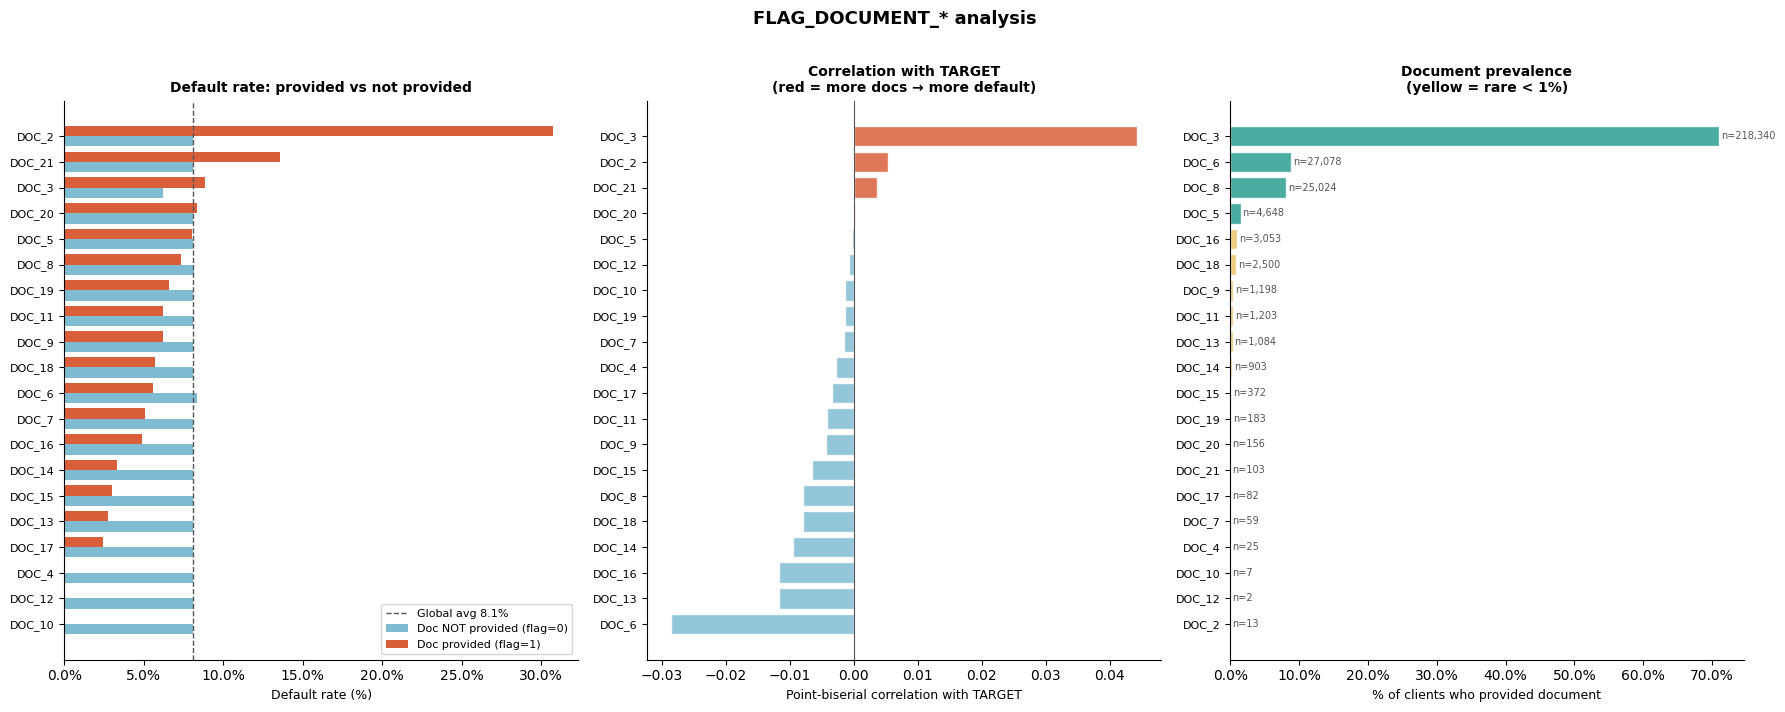

In [48]:
# ── 3. Visualisation ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Panel A — default rate flag=1 vs flag=0 (sorted by spread)
ax = axes[0]
df_sorted = df_flags.sort_values('spread_pp')
y = np.arange(len(df_sorted))
ax.barh(y, df_sorted['dr_flag_0'], height=0.4,
        color='#7fbcd2', label='Doc NOT provided (flag=0)')
ax.barh(y + 0.4, df_sorted['dr_flag_1'], height=0.4,
        color='#d95f3b', label='Doc provided (flag=1)')
ax.axvline(global_rate * 100, color='#555', linewidth=1,
           linestyle='--', label=f'Global avg {global_rate*100:.1f}%')
ax.set_yticks(y + 0.2)
ax.set_yticklabels(df_sorted['flag'], fontsize=8)
ax.set_xlabel("Default rate (%)", fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_title("Default rate: provided vs not provided",
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Panel B — point-biserial correlation with TARGET
ax = axes[1]
df_corr_sorted = df_flags.sort_values('point_biserial', ascending=True)
colors = ['#d95f3b' if v > 0 else '#7fbcd2'
          for v in df_corr_sorted['point_biserial']]
ax.barh(df_corr_sorted['flag'], df_corr_sorted['point_biserial'],
        color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='#555', linewidth=0.8)
ax.set_xlabel("Point-biserial correlation with TARGET", fontsize=9)
ax.set_title("Correlation with TARGET\n(red = more docs → more default)",
             fontsize=10, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Panel C — prevalence (how common is each document)
ax = axes[2]
df_prev = df_flags.sort_values('prevalence_pct', ascending=True)
colors  = ['#e9c46a' if p < 1 else '#2a9d8f'
           for p in df_prev['prevalence_pct']]
bars = ax.barh(df_prev['flag'], df_prev['prevalence_pct'],
               color=colors, alpha=0.85, edgecolor='white')
for bar, (_, row) in zip(bars, df_prev.iterrows()):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"n={row['n_flag_1']:,}",
            va='center', fontsize=7, color='#555')
ax.set_xlabel("% of clients who provided document", fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_title("Document prevalence\n(yellow = rare < 1%)",
             fontsize=10, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("FLAG_DOCUMENT_* analysis", fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("eda_flag_documents.png", bbox_inches='tight', dpi=150)
plt.show()


Total documents provided per client:

 n_docs_provided  n_clients  default_rate_pct  pct_population
               0      29549              5.52            9.61
               1     270056              8.45           87.82
               2       7742              4.64            2.52
               3        163              9.82            0.05
               4          1            100.00            0.00


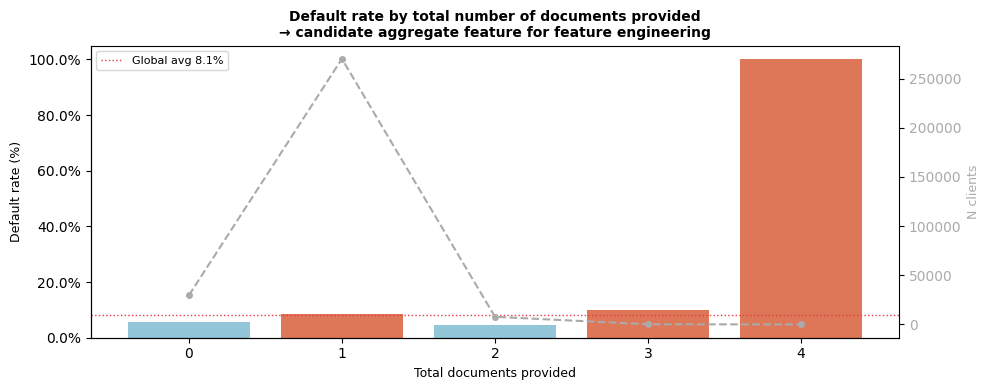

In [49]:
# ── 4. Total documents provided per client → aggregate signal ────────
# A single flag might be weak, but "how many documents did this
# client provide in total?" is often a stronger predictor.

flag_sum_expr = " + ".join([f"COALESCE(CAST({c} AS INT), 0)"
                             for c in flag_cols])

df_doc_count = con.execute(f"""
    WITH doc_counts AS (
        SELECT
            TARGET,
            ({flag_sum_expr}) AS n_docs_provided
        FROM app_train
        WHERE TARGET IS NOT NULL
    )
    SELECT
        n_docs_provided,
        COUNT(*)                            AS n_clients,
        ROUND(AVG(TARGET) * 100, 2)         AS default_rate_pct,
        ROUND(COUNT(*) * 100.0
              / SUM(COUNT(*)) OVER (), 2)   AS pct_population
    FROM doc_counts
    GROUP BY n_docs_provided
    ORDER BY n_docs_provided
""").fetchdf()

print("\nTotal documents provided per client:\n")
print(df_doc_count.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax2 = ax.twinx()

colors = ['#d95f3b' if r > global_rate * 100 else '#7fbcd2'
          for r in df_doc_count['default_rate_pct']]
ax.bar(df_doc_count['n_docs_provided'], df_doc_count['default_rate_pct'],
       color=colors, alpha=0.85)
ax2.plot(df_doc_count['n_docs_provided'], df_doc_count['n_clients'],
         color='#aaa', linewidth=1.5, linestyle='--',
         marker='o', markersize=4, label='N clients')

ax.axhline(global_rate * 100, color='#e63946', linewidth=1,
           linestyle=':', label=f'Global avg {global_rate*100:.1f}%')
ax.set_xlabel("Total documents provided", fontsize=9)
ax.set_ylabel("Default rate (%)", fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax2.set_ylabel("N clients", fontsize=9, color='#aaa')
ax2.tick_params(axis='y', labelcolor='#aaa')
ax.set_title("Default rate by total number of documents provided\n"
             "→ candidate aggregate feature for feature engineering",
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("eda_flag_doc_count.png", bbox_inches='tight', dpi=150)
plt.show()

- Predictive Power of Rare Documents: Most document flags are sparsely populated, but certain specific documents like FLAG_DOCUMENT_2 and FLAG_DOCUMENT_21 are high-risk indicators, with default rates significantly exceeding the global average of 8.1%.

- Negative Correlation of Document 3: FLAG_DOCUMENT_3 is the most common document (70% prevalence). Its absence is positively correlated with default, suggesting it is a mandatory or standard requirement for low-risk profiles.

- Feature Aggregation Potential: The total count of documents provided shows a non-linear relationship with risk. Specifically, cases where 4 documents are submitted show an extreme default rate, making TOTAL_DOCS a prime candidate for feature engineering to capture application complexity.

## Secondary Datasets Analysis

In [1]:
import duckdb
import pandas as pd

con = duckdb.connect()

# Path configuration
DATA_PATH = "./data/raw/" 

con.execute(f"CREATE OR REPLACE VIEW app_train AS SELECT * FROM read_csv_auto('{DATA_PATH}/application_train.csv')")

SECONDARY_TABLES = {
    "bureau":                  ("SK_ID_CURR",   f"{DATA_PATH}/bureau.csv"),
    "bureau_balance":          ("SK_ID_BUREAU", f"{DATA_PATH}/bureau_balance.csv"),
    "previous_application":    ("SK_ID_CURR",   f"{DATA_PATH}/previous_application.csv"),
    "POS_CASH_balance":        ("SK_ID_CURR",   f"{DATA_PATH}/POS_CASH_balance.csv"),
    "installments_payments":   ("SK_ID_CURR",   f"{DATA_PATH}/installments_payments.csv"),
    "credit_card_balance":     ("SK_ID_CURR",   f"{DATA_PATH}/credit_card_balance.csv"),
}

# Load the main table
con.execute(f"""
    CREATE TABLE application AS
    SELECT SK_ID_CURR FROM app_train
""")

total_clients = con.execute("SELECT COUNT(*) FROM application").fetchone()[0]
print(f"Total clients in main table: {total_clients:,}\n")

Total clients in main table: 307,511



### Data Discovery

- How many clients from the main table do not have records in this table?
- What is the distribution of the number of records per client? (mean, max, outliers)
- Are there columns with temporal semantics to exploit?

In [2]:
# --- Analysis for each secondary table ---

results = {}

for table_name, (join_key, path) in SECONDARY_TABLES.items():

    print(f"\n{'='*65}")
    print(f"  {table_name}  (join key: {join_key})")
    print(f"{'='*65}")

    # Register the secondary table as a View in DuckDB for querying
    con.execute(f"""
        CREATE OR REPLACE VIEW {table_name}_view AS
        SELECT * FROM read_csv_auto('{path}')
    """)

    # 1. Total rows and unique keys in the secondary table
    stats = con.execute(f"""
        SELECT
            COUNT(*)                        AS total_rows,
            COUNT(DISTINCT {join_key})      AS unique_keys
        FROM {table_name}_view
    """).fetchdf()

    total_rows  = stats['total_rows'].iloc[0]
    unique_keys = stats['unique_keys'].iloc[0]
    print(f"  Total rows    : {total_rows:>12,}")
    print(f"  Unique keys   : {unique_keys:>12,}")

    # 2. Clients in the main table WITHOUT records in this table
    #    (only for tables with join on SK_ID_CURR)
    if join_key == "SK_ID_CURR":
        missing = con.execute(f"""
            SELECT COUNT(*) AS missing_clients
            FROM application a
            LEFT JOIN (
                SELECT DISTINCT SK_ID_CURR
                FROM {table_name}_view
            ) t USING (SK_ID_CURR)
            WHERE t.SK_ID_CURR IS NULL
        """).fetchone()[0]

        pct_missing = missing / total_clients * 100
        print(f"  Clients without records: {missing:,} ({pct_missing:.1f}%)")
        print(f"  → {'⚠ missing informative relevant' if pct_missing > 20 else 'OK — good coverage'}")

    # 3. Distribution of records per key (mean, median, max, p95)
    dist = con.execute(f"""
        SELECT
            AVG(cnt)                        AS mean,
            MEDIAN(cnt)                     AS median,
            MAX(cnt)                        AS max,
            PERCENTILE_CONT(0.95)
                WITHIN GROUP (ORDER BY cnt) AS p95,
            PERCENTILE_CONT(0.99)
                WITHIN GROUP (ORDER BY cnt) AS p99
        FROM (
            SELECT {join_key}, COUNT(*) AS cnt
            FROM {table_name}_view
            GROUP BY {join_key}
        ) sub
    """).fetchdf()

    print(f"\n  Distribution of records per {join_key}:")
    print(f"    Mean   : {dist['mean'].iloc[0]:>8.1f}")
    print(f"    Median : {dist['median'].iloc[0]:>8.1f}")
    print(f"    p95     : {dist['p95'].iloc[0]:>8.1f}")
    print(f"    p99     : {dist['p99'].iloc[0]:>8.1f}")
    print(f"    Max     : {dist['max'].iloc[0]:>8.0f}  ← potential outlier")

    # 4. Columns with temporal information (e.g. containing keywords like MONTH, YEAR, DAYS, DATE, HOUR, TIME)
    columns = con.execute(f"""
        SELECT column_name
        FROM information_schema.columns
        WHERE table_name = '{table_name}_view'
    """).fetchdf()['column_name'].tolist()

    temporal_cols = [
        c for c in columns
        if any(kw in c.upper() for kw in ['MONTH', 'YEAR', 'DAYS', 'DATE', 'HOUR', 'TIME'])
    ]

    if temporal_cols:
        print(f"\n  Temporal columns detected:")
        for col in temporal_cols:
            # Min/Max range to understand the temporal horizon
            rng = con.execute(f"""
                SELECT MIN({col}) AS mn, MAX({col}) AS mx
                FROM {table_name}_view
                WHERE {col} IS NOT NULL
            """).fetchone()
            print(f"    {col:<35} range: [{rng[0]}, {rng[1]}]")
    else:
        print(f"\n  No temporal columns detected.")

    results[table_name] = {
        "total_rows": total_rows,
        "unique_keys": unique_keys,
        "temporal_cols": temporal_cols
    }

print(f"\n{'='*65}")
print("  Analysis completed.")


  bureau  (join key: SK_ID_CURR)
  Total rows    :    1,716,428
  Unique keys   :      305,811
  Clients without records: 44,020 (14.3%)
  → OK — good coverage

  Distribution of records per SK_ID_CURR:
    Mean   :      5.6
    Median :      4.0
    p95     :     14.0
    p99     :     21.0
    Max     :      116  ← potential outlier

  Temporal columns detected:
    DAYS_CREDIT                         range: [-2922, 0]
    DAYS_CREDIT_ENDDATE                 range: [-42060.0, 31199.0]
    DAYS_ENDDATE_FACT                   range: [-42023.0, 0.0]
    DAYS_CREDIT_UPDATE                  range: [-41947, 372]

  bureau_balance  (join key: SK_ID_BUREAU)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Total rows    :   27,299,925
  Unique keys   :      817,395


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Distribution of records per SK_ID_BUREAU:
    Mean   :     33.4
    Median :     26.0
    p95     :     90.0
    p99     :     97.0
    Max     :       97  ← potential outlier

  Temporal columns detected:


...

    DAYS_INSTALMENT                     range: [-2922.0, -1.0]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    DAYS_ENTRY_PAYMENT                  range: [-4921.0, -1.0]

  credit_card_balance  (join key: SK_ID_CURR)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Total rows    :    3,840,312
  Unique keys   :      103,558
  Clients without records: 220,606 (71.7%)
  → ⚠ missing informative relevant

  Distribution of records per SK_ID_CURR:
    Mean   :     37.1
    Median :     22.0
    p95     :     96.0
    p99     :     96.0
    Max     :      192  ← potential outlier

  Temporal columns detected:
    MONTHS_BALANCE                      range: [-96, -1]

  Analysis completed.


In [3]:
# --- Final compact summary ---

print("\n\nSUMMARY OF SECONDARY TABLES")
print(f"{'Table':<28} {'Rows':>10} {'Unique Keys':>15} {'Rows/Key (Mean)':>22}")
print("-" * 80)

for table_name, r in results.items():
    ratio = r['total_rows'] / r['unique_keys'] if r['unique_keys'] > 0 else 0
    print(f"{table_name:<28} {r['total_rows']:>10,} {r['unique_keys']:>15,} {ratio:>22.1f}")

con.close()



SUMMARY OF SECONDARY TABLES
Table                              Rows     Unique Keys        Rows/Key (Mean)
--------------------------------------------------------------------------------
bureau                        1,716,428         305,811                    5.6
bureau_balance               27,299,925         817,395                   33.4
previous_application          1,670,214         338,857                    4.9
POS_CASH_balance             10,001,358         337,252                   29.7
installments_payments        13,605,401         339,587                   40.1
credit_card_balance           3,840,312         103,558                   37.1


### Explorative aggregations

In [4]:
# Register all secondary tables as views
SECONDARY_PATHS = {
    "bureau":                "data/raw/bureau.csv",
    "bureau_balance":        "data/raw/bureau_balance.csv",
    "previous_application":  "data/raw/previous_application.csv",
    "pos_cash":              "data/raw/POS_CASH_balance.csv",
    "installments":          "data/raw/installments_payments.csv",
    "credit_card":           "data/raw/credit_card_balance.csv",
}

for view_name, path in SECONDARY_PATHS.items():
    con.execute(f"""
        CREATE OR REPLACE VIEW {view_name} AS
        SELECT * FROM read_csv_auto('{path}')
    """)

print("Views registered.")

ConnectionException: Connection Error: Connection already closed!

#### Bureau

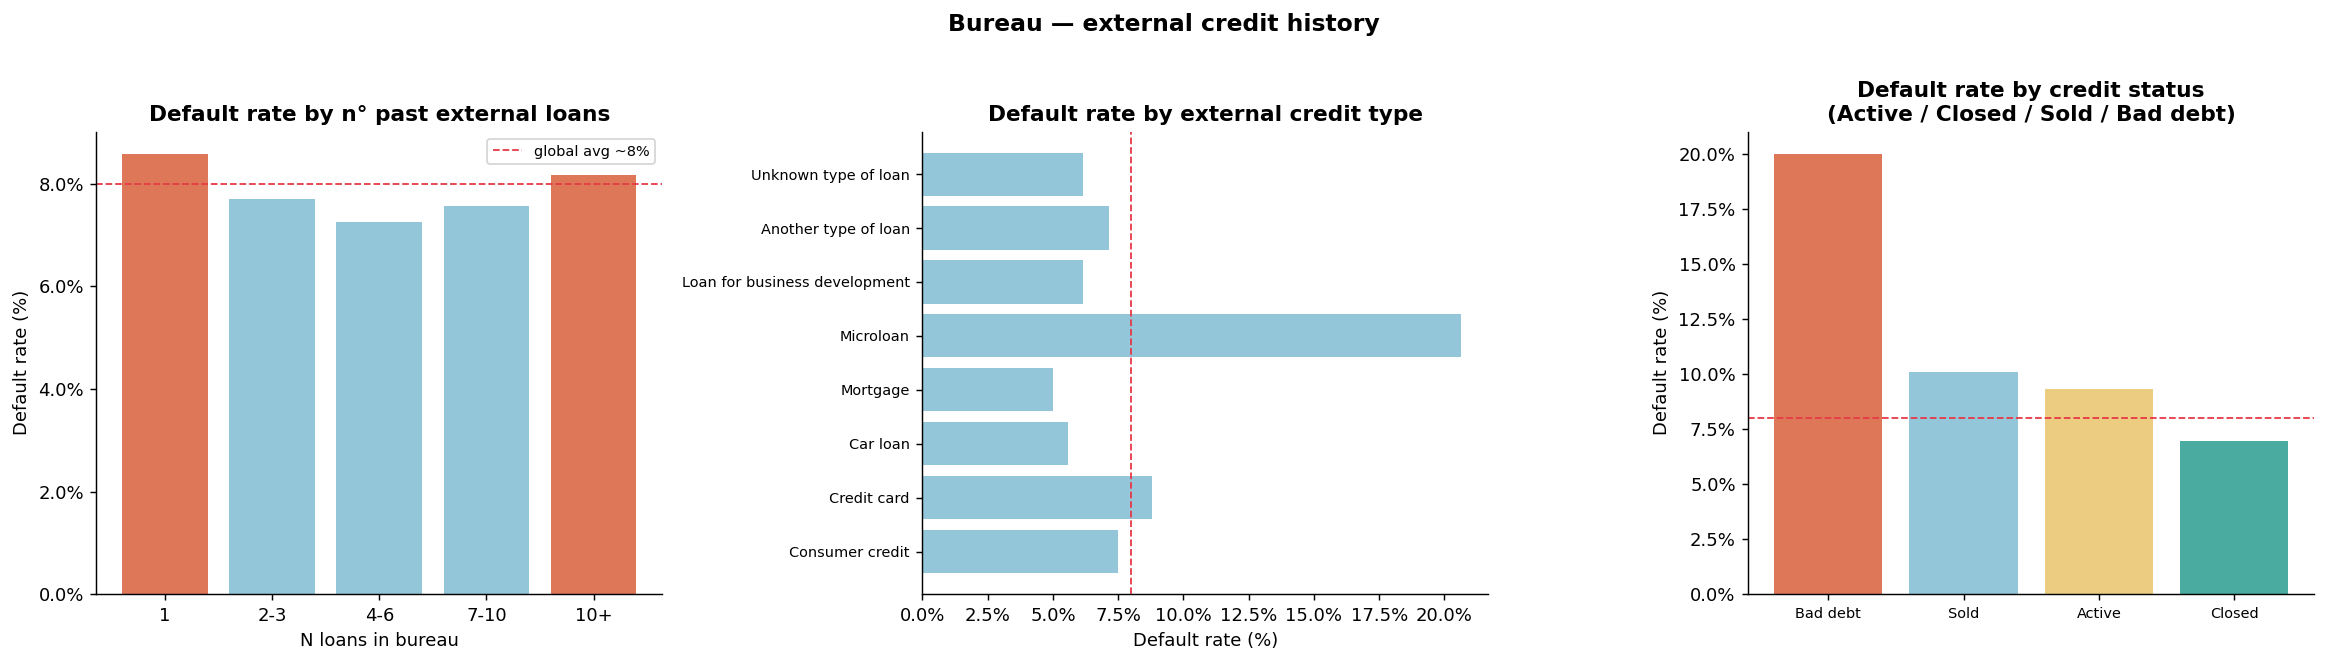

In [ ]:
def plot_bureau(con):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # A) Number of past external loans per client → default rate
    df = con.execute("""
    WITH counts AS (
        SELECT SK_ID_CURR, COUNT(*) AS n_loans
        FROM bureau GROUP BY SK_ID_CURR
    ),
    binned AS (
        SELECT
            SK_ID_CURR,                        -- ← add this
            CASE
                WHEN n_loans = 1 THEN '1'
                WHEN n_loans BETWEEN 2 AND 3  THEN '2-3'
                WHEN n_loans BETWEEN 4 AND 6  THEN '4-6'
                WHEN n_loans BETWEEN 7 AND 10 THEN '7-10'
                ELSE '10+'
            END AS bucket,
            n_loans
        FROM counts
    )
    SELECT
        bucket,
        COUNT(*)                         AS n_clients,
        ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
    FROM binned b
    JOIN app_train a USING (SK_ID_CURR)
    WHERE a.TARGET IS NOT NULL
    GROUP BY bucket
    ORDER BY MIN(n_loans)
""").fetchdf()

    ax = axes[0]
    colors = ['#d95f3b' if r > 8 else '#7fbcd2' for r in df['default_rate_pct']]
    ax.bar(df['bucket'], df['default_rate_pct'], color=colors, alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--', label='global avg ~8%')
    ax.set_title("Default rate by n° past external loans", fontweight='bold')
    ax.set_xlabel("N loans in bureau")
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # B) Credit type distribution
    df2 = con.execute("""
        SELECT
            CREDIT_TYPE,
            COUNT(*)                         AS n,
            ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
        FROM bureau b
        JOIN app_train a USING (SK_ID_CURR)
        WHERE a.TARGET IS NOT NULL
          AND CREDIT_TYPE IS NOT NULL
        GROUP BY CREDIT_TYPE
        ORDER BY n DESC
        LIMIT 8
    """).fetchdf()

    ax = axes[1]
    ax.barh(df2['CREDIT_TYPE'], df2['default_rate_pct'],
            color='#7fbcd2', alpha=0.85)
    ax.axvline(8, color='#e63946', linewidth=1, linestyle='--')
    ax.set_title("Default rate by external credit type", fontweight='bold')
    ax.set_xlabel("Default rate (%)")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # C) Active vs closed loans → default rate
    df3 = con.execute("""
        SELECT
            CREDIT_ACTIVE,
            COUNT(*)                         AS n,
            ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
        FROM bureau b
        JOIN app_train a USING (SK_ID_CURR)
        WHERE a.TARGET IS NOT NULL
          AND CREDIT_ACTIVE IS NOT NULL
        GROUP BY CREDIT_ACTIVE
        ORDER BY default_rate_pct DESC
    """).fetchdf()

    ax = axes[2]
    ax.bar(df3['CREDIT_ACTIVE'], df3['default_rate_pct'],
           color=['#d95f3b', '#7fbcd2', '#e9c46a', '#2a9d8f'][:len(df3)],
           alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--')
    ax.set_title("Default rate by credit status\n(Active / Closed / Sold / Bad debt)",
                 fontweight='bold')
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='x', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle("Bureau — external credit history", fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("eda_bureau.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_bureau(con)

Default Rate by Recency Buckets:



,recency_bucket,total_credits,default_rate_pct
0,1. Last 12 months,279132,10.87
1,2. 1-2 years ago,284172,8.80
2,3. 2-3 years ago,237589,7.41
3,4. Older than 3 years,664432,6.26


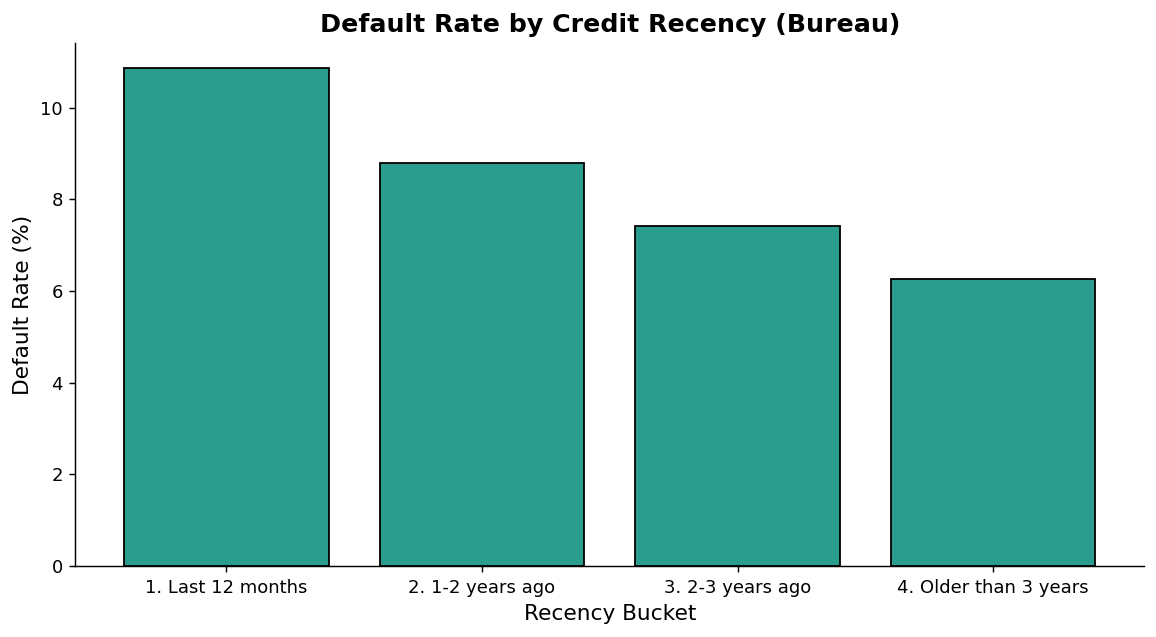

In [ ]:
import matplotlib.pyplot as plt

# 1. Aggregate data into time buckets using DuckDB
query_temporal = """
    WITH temporal_buckets AS (
        SELECT 
            b.SK_ID_CURR,
            a.TARGET,
            CASE 
                WHEN b.DAYS_CREDIT >= -365 THEN '1. Last 12 months'
                WHEN b.DAYS_CREDIT >= -730 THEN '2. 1-2 years ago'
                WHEN b.DAYS_CREDIT >= -1095 THEN '3. 2-3 years ago'
                ELSE '4. Older than 3 years'
            END AS recency_bucket
        FROM bureau b
        JOIN app_train a ON b.SK_ID_CURR = a.SK_ID_CURR
        WHERE a.TARGET IS NOT NULL
    )
    SELECT 
        recency_bucket,
        COUNT(*) AS total_credits,
        ROUND(AVG(TARGET) * 100, 2) AS default_rate_pct
    FROM temporal_buckets
    GROUP BY recency_bucket
    ORDER BY recency_bucket;
"""

df_temporal = con.execute(query_temporal).df()
print("Default Rate by Recency Buckets:\n")
display(df_temporal)

# 2. Visualize the trend
plt.figure(figsize=(9, 5))
plt.bar(df_temporal['recency_bucket'], df_temporal['default_rate_pct'], color='#2a9d8f', edgecolor='black')
plt.title('Default Rate by Credit Recency (Bureau)', fontsize=14, fontweight='bold')
plt.ylabel('Default Rate (%)', fontsize=12)
plt.xlabel('Recency Bucket', fontsize=12)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Bureau Balance

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

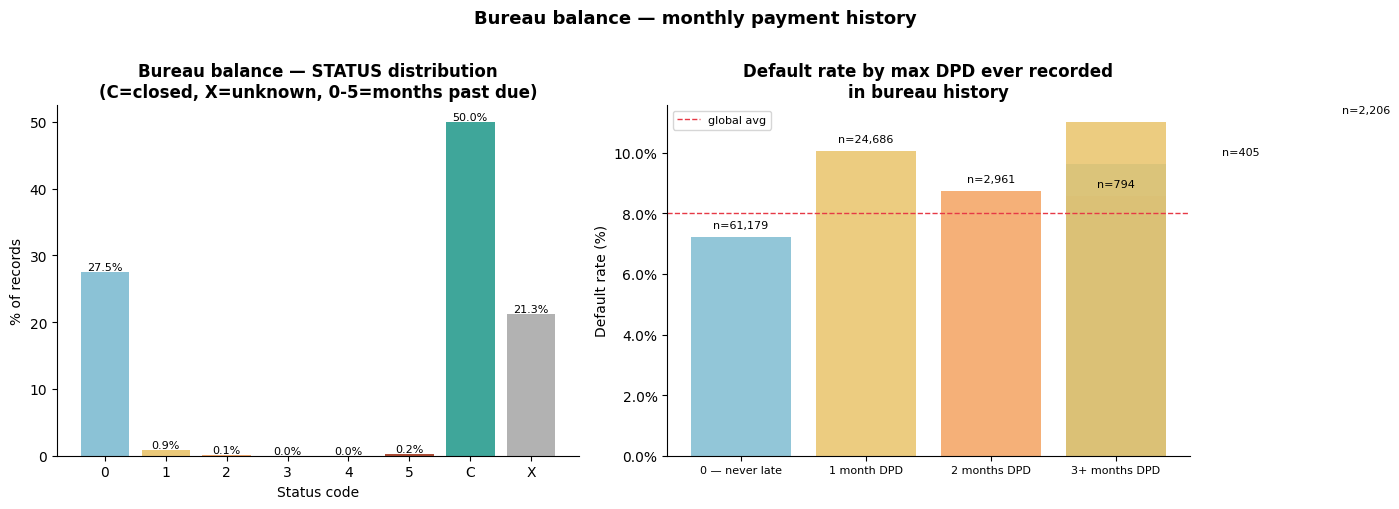

In [ ]:
def plot_bureau_balance(con):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # A) Frequency of each STATUS code
    # 0-5 = months past due, C = closed, X = unknown
    df = con.execute("""
        SELECT
            STATUS,
            COUNT(*)                                        AS n,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
        FROM bureau_balance
        GROUP BY STATUS
        ORDER BY STATUS
    """).fetchdf()

    status_colors = {
        'C': '#2a9d8f', 'X': '#aaaaaa',
        '0': '#7fbcd2', '1': '#e9c46a',
        '2': '#f4a261', '3': '#e76f51',
        '4': '#d95f3b', '5': '#a33a20'
    }
    colors = [status_colors.get(s, '#cccccc') for s in df['STATUS']]

    ax = axes[0]
    bars = ax.bar(df['STATUS'], df['pct'], color=colors, alpha=0.9)
    for bar, (_, row) in zip(bars, df.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{row['pct']:.1f}%", ha='center', fontsize=8)
    ax.set_title("Bureau balance — STATUS distribution\n"
                 "(C=closed, X=unknown, 0-5=months past due)",
                 fontweight='bold')
    ax.set_xlabel("Status code")
    ax.set_ylabel("% of records")
    ax.spines[['top', 'right']].set_visible(False)

    # B) % of clients who ever had DPD > 0 → default rate
    df2 = con.execute("""
        WITH client_dpd AS (
            SELECT
                b.SK_ID_CURR,
                MAX(CASE WHEN bb.STATUS NOT IN ('C','X')
                         THEN CAST(bb.STATUS AS INT) ELSE 0 END) AS max_dpd
            FROM bureau_balance bb
            JOIN bureau b USING (SK_ID_BUREAU)
            GROUP BY b.SK_ID_CURR
        )
        SELECT
            CASE
                WHEN max_dpd = 0 THEN '0 — never late'
                WHEN max_dpd = 1 THEN '1 month DPD'
                WHEN max_dpd = 2 THEN '2 months DPD'
                ELSE '3+ months DPD'
            END                              AS dpd_bucket,
            max_dpd,
            COUNT(*)                         AS n_clients,
            ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
        FROM client_dpd c
        JOIN app_train a USING (SK_ID_CURR)
        WHERE a.TARGET IS NOT NULL
        GROUP BY dpd_bucket, max_dpd
        ORDER BY max_dpd
    """).fetchdf()

    ax = axes[1]
    colors2 = ['#7fbcd2', '#e9c46a', '#f4a261', '#d95f3b']
    ax.bar(df2['dpd_bucket'], df2['default_rate_pct'],
           color=colors2[:len(df2)], alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--', label='global avg')
    for i, (_, row) in enumerate(df2.iterrows()):
        ax.text(i, row['default_rate_pct'] + 0.3,
                f"n={row['n_clients']:,}", ha='center', fontsize=8)
    ax.set_title("Default rate by max DPD ever recorded\nin bureau history",
                 fontweight='bold')
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='x', labelsize=8)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle("Bureau balance — monthly payment history",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("eda_bureau_balance.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_bureau_balance(con)

#### Previous applications

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

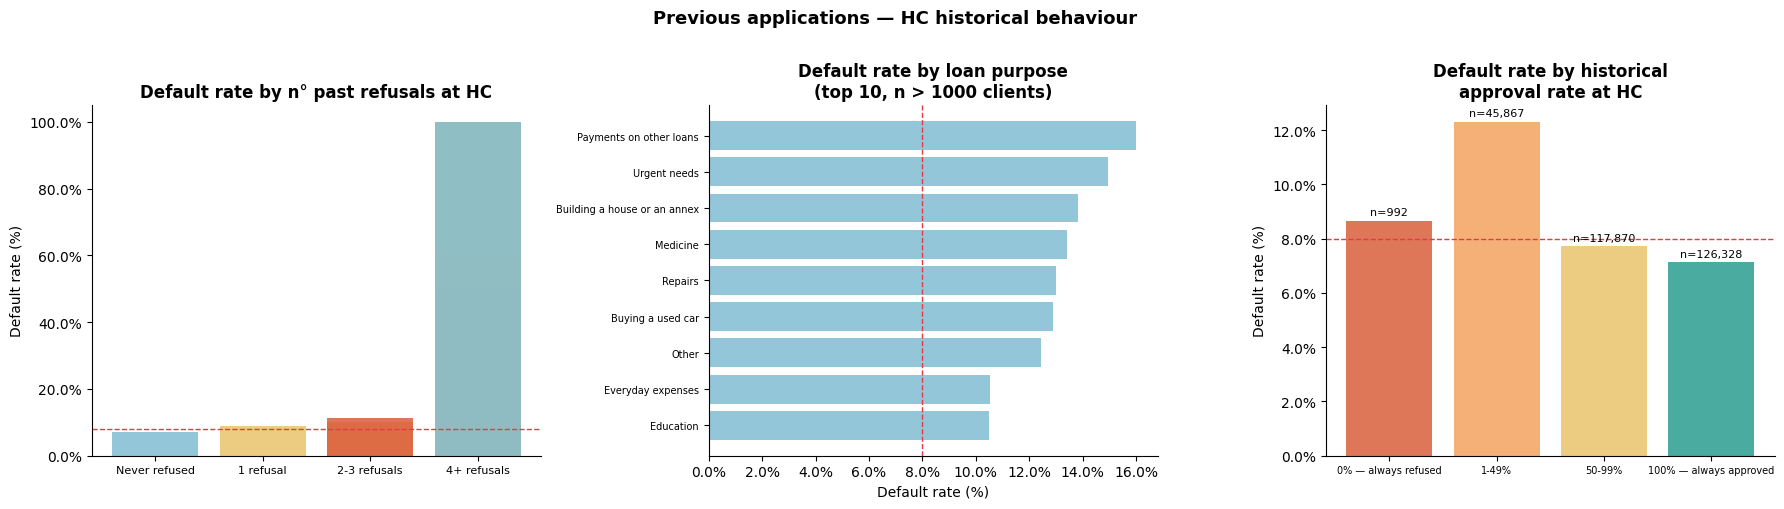

In [ ]:
def plot_previous_application(con):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # A) Default rate by past application outcome
    df = con.execute("""
        WITH client_outcomes AS (
            SELECT
                SK_ID_CURR,
                SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Approved'  THEN 1 ELSE 0 END) AS n_approved,
                SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Refused'   THEN 1 ELSE 0 END) AS n_refused,
                COUNT(*) AS n_total
            FROM previous_application
            GROUP BY SK_ID_CURR
        )
        SELECT
            CASE
                WHEN n_refused = 0              THEN 'Never refused'
                WHEN n_refused = 1              THEN '1 refusal'
                WHEN n_refused BETWEEN 2 AND 3  THEN '2-3 refusals'
                ELSE '4+ refusals'
            END                              AS refusal_bucket,
            n_refused,
            COUNT(*)                         AS n_clients,
            ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
        FROM client_outcomes c
        JOIN app_train a USING (SK_ID_CURR)
        WHERE a.TARGET IS NOT NULL
        GROUP BY refusal_bucket, n_refused
        ORDER BY n_refused
    """).fetchdf()

    ax = axes[0]
    colors = ['#7fbcd2', '#e9c46a', '#f4a261', '#d95f3b']
    ax.bar(df['refusal_bucket'], df['default_rate_pct'],
           color=colors[:len(df)], alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--')
    ax.set_title("Default rate by n° past refusals at HC", fontweight='bold')
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='x', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # B) Default rate by contract purpose
    df2 = con.execute("""
        SELECT
            NAME_CASH_LOAN_PURPOSE,
            COUNT(DISTINCT p.SK_ID_CURR)     AS n_clients,
            ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
        FROM previous_application p
        JOIN app_train a USING (SK_ID_CURR)
        WHERE a.TARGET IS NOT NULL
          AND NAME_CASH_LOAN_PURPOSE IS NOT NULL
          AND NAME_CASH_LOAN_PURPOSE NOT IN ('XAP', 'XNA')
        GROUP BY NAME_CASH_LOAN_PURPOSE
        HAVING COUNT(DISTINCT p.SK_ID_CURR) > 1000
        ORDER BY default_rate_pct DESC
        LIMIT 10
    """).fetchdf()

    ax = axes[1]
    ax.barh(df2['NAME_CASH_LOAN_PURPOSE'][::-1],
            df2['default_rate_pct'][::-1],
            color='#7fbcd2', alpha=0.85)
    ax.axvline(8, color='#e63946', linewidth=1, linestyle='--')
    ax.set_title("Default rate by loan purpose\n(top 10, n > 1000 clients)",
                 fontweight='bold')
    ax.set_xlabel("Default rate (%)")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='y', labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

    # C) Approval rate vs default rate — are past-rejected clients riskier now?
    df3 = con.execute("""
        WITH ratios AS (
            SELECT
                SK_ID_CURR,
                ROUND(
                    SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Approved' THEN 1 ELSE 0 END)
                    * 100.0 / COUNT(*), 0
                ) AS approval_rate_pct
            FROM previous_application
            GROUP BY SK_ID_CURR
        ),
        binned AS (
            SELECT
                CASE
                    WHEN approval_rate_pct = 0   THEN '0% — always refused'
                    WHEN approval_rate_pct < 50  THEN '1-49%'
                    WHEN approval_rate_pct < 100 THEN '50-99%'
                    ELSE '100% — always approved'
                END AS bucket,
                approval_rate_pct,
                SK_ID_CURR
            FROM ratios
        )
        SELECT
            bucket,
            MIN(approval_rate_pct)           AS sort_key,
            COUNT(*)                         AS n_clients,
            ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
        FROM binned b
        JOIN app_train a USING (SK_ID_CURR)
        WHERE a.TARGET IS NOT NULL
        GROUP BY bucket
        ORDER BY sort_key
    """).fetchdf()

    ax = axes[2]
    colors3 = ['#d95f3b', '#f4a261', '#e9c46a', '#2a9d8f']
    ax.bar(df3['bucket'], df3['default_rate_pct'],
           color=colors3[:len(df3)], alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--')
    for i, (_, row) in enumerate(df3.iterrows()):
        ax.text(i, row['default_rate_pct'] + 0.2,
                f"n={row['n_clients']:,}", ha='center', fontsize=8)
    ax.set_title("Default rate by historical\napproval rate at HC", fontweight='bold')
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='x', labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle("Previous applications — HC historical behaviour",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("eda_previous_application.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_previous_application(con)

#### Installments — payment delay analysis

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

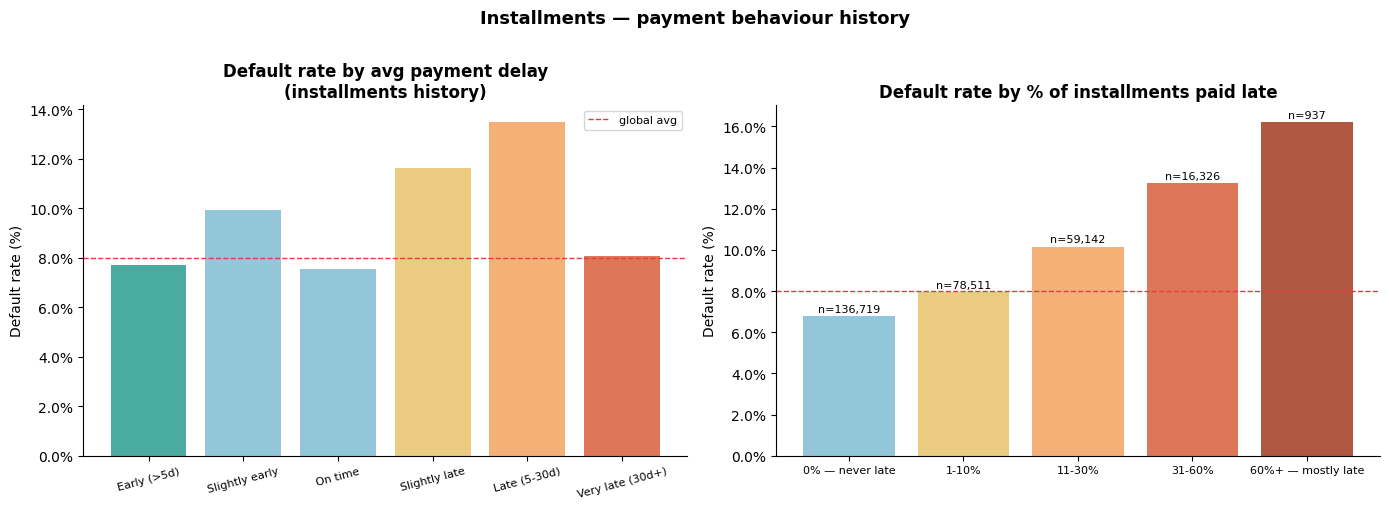

In [ ]:
def plot_installments(con):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # A) Distribution of payment delay (days) by TARGET
    # delay > 0 = paid late, delay < 0 = paid early
    df = con.execute("""
    WITH delays AS (
        SELECT
            SK_ID_CURR,
            AVG(DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT) AS avg_delay
        FROM installments
        WHERE DAYS_ENTRY_PAYMENT IS NOT NULL
          AND DAYS_INSTALMENT IS NOT NULL
        GROUP BY SK_ID_CURR
    ),
    bucketed AS (
        SELECT
            SK_ID_CURR,
            avg_delay,
            CASE
                WHEN avg_delay < -5  THEN '1_Early (>5d)'
                WHEN avg_delay < 0   THEN '2_Slightly early'
                WHEN avg_delay = 0   THEN '3_On time'
                WHEN avg_delay <= 5  THEN '4_Slightly late'
                WHEN avg_delay <= 30 THEN '5_Late (5-30d)'
                ELSE                      '6_Very late (30d+)'
            END AS bucket
        FROM delays
    )
    SELECT
        SUBSTR(bucket, 3)                AS delay_bucket,
        COUNT(*)                         AS n_clients,
        ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
    FROM bucketed b
    JOIN app_train a USING (SK_ID_CURR)
    WHERE a.TARGET IS NOT NULL
    GROUP BY bucket
    ORDER BY bucket
""").fetchdf()

    ax = axes[0]
    colors = ['#2a9d8f', '#7fbcd2', '#7fbcd2', '#e9c46a', '#f4a261', '#d95f3b']
    ax.bar(df['delay_bucket'], df['default_rate_pct'],
           color=colors[:len(df)], alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--', label='global avg')
    ax.set_title("Default rate by avg payment delay\n(installments history)",
                 fontweight='bold')
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # B) % of installments paid late per client → default rate
    df2 = con.execute("""
        WITH client_stats AS (
            SELECT
                SK_ID_CURR,
                ROUND(
                    SUM(CASE WHEN DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT THEN 1 ELSE 0 END)
                    * 100.0 / COUNT(*), 0
                ) AS pct_late
            FROM installments
            WHERE DAYS_ENTRY_PAYMENT IS NOT NULL
              AND DAYS_INSTALMENT IS NOT NULL
            GROUP BY SK_ID_CURR
        ),
        binned AS (
            SELECT
                CASE
                    WHEN pct_late = 0              THEN '0% — never late'
                    WHEN pct_late BETWEEN 1 AND 10 THEN '1-10%'
                    WHEN pct_late BETWEEN 11 AND 30 THEN '11-30%'
                    WHEN pct_late BETWEEN 31 AND 60 THEN '31-60%'
                    ELSE '60%+ — mostly late'
                END AS bucket,
                pct_late,
                SK_ID_CURR
            FROM client_stats
        )
        SELECT
            bucket,
            MIN(pct_late)                    AS sort_key,
            COUNT(*)                         AS n_clients,
            ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
        FROM binned b
        JOIN app_train a USING (SK_ID_CURR)
        WHERE a.TARGET IS NOT NULL
        GROUP BY bucket
        ORDER BY sort_key
    """).fetchdf()

    ax = axes[1]
    colors2 = ['#7fbcd2', '#e9c46a', '#f4a261', '#d95f3b', '#a33a20']
    ax.bar(df2['bucket'], df2['default_rate_pct'],
           color=colors2[:len(df2)], alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--')
    for i, (_, row) in enumerate(df2.iterrows()):
        ax.text(i, row['default_rate_pct'] + 0.2,
                f"n={row['n_clients']:,}", ha='center', fontsize=8)
    ax.set_title("Default rate by % of installments paid late",
                 fontweight='bold')
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='x', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle("Installments — payment behaviour history",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("eda_installments.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_installments(con)

#### POS Cash + Credit Card — utilization & days past due (DPD)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

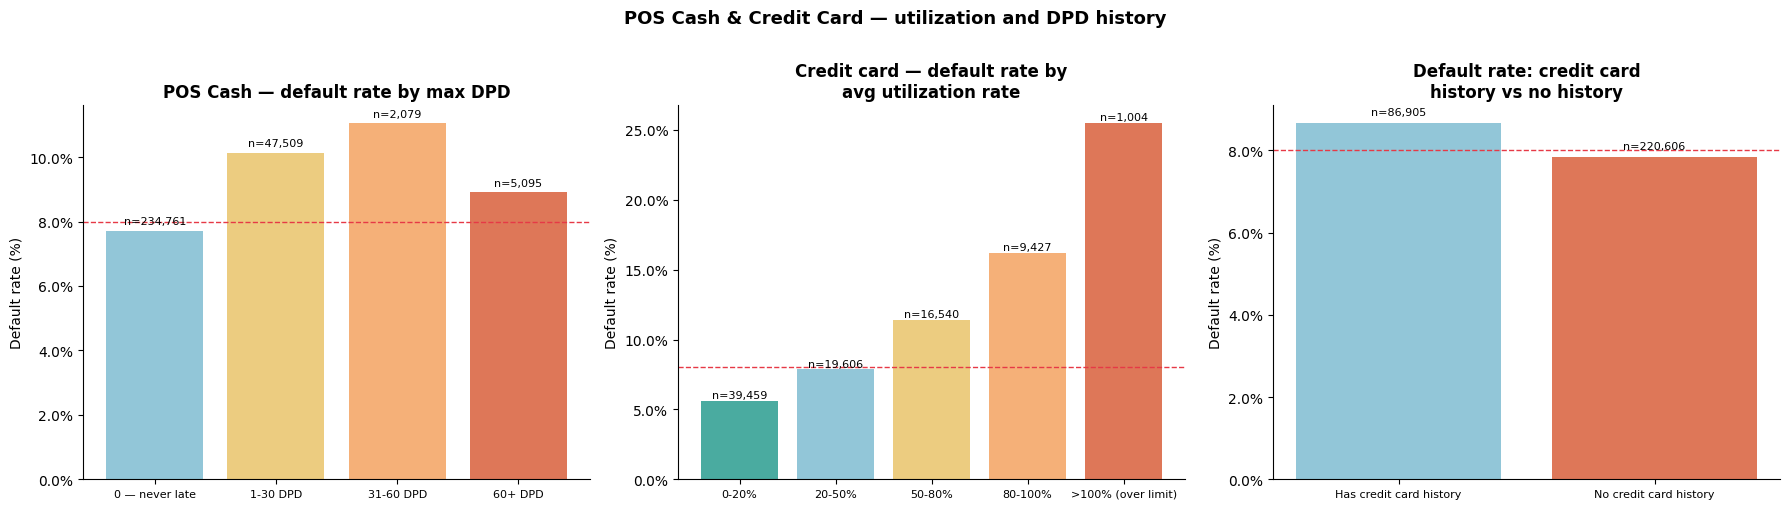

In [ ]:
def plot_pos_and_credit_card(con):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # A) POS Cash — max DPD ever recorded per client
    df = con.execute("""
    WITH client_dpd AS (
        SELECT SK_ID_CURR, MAX(SK_DPD) AS max_dpd
        FROM pos_cash
        GROUP BY SK_ID_CURR
    ),
    bucketed AS (
        SELECT
            SK_ID_CURR,
            max_dpd,
            CASE
                WHEN max_dpd = 0              THEN '1_0 — never late'
                WHEN max_dpd BETWEEN 1 AND 30  THEN '2_1-30 DPD'
                WHEN max_dpd BETWEEN 31 AND 60 THEN '3_31-60 DPD'
                ELSE                               '4_60+ DPD'
            END AS bucket
        FROM client_dpd
    )
    SELECT
        SUBSTR(bucket, 3)                AS dpd_bucket,
        COUNT(*)                         AS n_clients,
        ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
    FROM bucketed b
    JOIN app_train a USING (SK_ID_CURR)
    WHERE a.TARGET IS NOT NULL
    GROUP BY bucket
    ORDER BY bucket
""").fetchdf()

    ax = axes[0]
    colors = ['#7fbcd2', '#e9c46a', '#f4a261', '#d95f3b']
    ax.bar(df['dpd_bucket'], df['default_rate_pct'],
           color=colors[:len(df)], alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--')
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(i, row['default_rate_pct'] + 0.2,
                f"n={row['n_clients']:,}", ha='center', fontsize=8)
    ax.set_title("POS Cash — default rate by max DPD", fontweight='bold')
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='x', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # B) Credit card — utilization rate (balance / credit limit)
    df2 = con.execute("""
        WITH util AS (
            SELECT
                SK_ID_CURR,
                AVG(
                    CASE WHEN AMT_CREDIT_LIMIT_ACTUAL > 0
                         THEN AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL
                    END
                ) AS avg_utilization
            FROM credit_card
            WHERE AMT_CREDIT_LIMIT_ACTUAL > 0
            GROUP BY SK_ID_CURR
        ),
        binned AS (
            SELECT
                CASE
                    WHEN avg_utilization < 0.2  THEN '0-20%'
                    WHEN avg_utilization < 0.5  THEN '20-50%'
                    WHEN avg_utilization < 0.8  THEN '50-80%'
                    WHEN avg_utilization <= 1.0 THEN '80-100%'
                    ELSE '>100% (over limit)'
                END AS bucket,
                avg_utilization,
                SK_ID_CURR
            FROM util
        )
        SELECT
            bucket,
            MIN(avg_utilization)             AS sort_key,
            COUNT(*)                         AS n_clients,
            ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
        FROM binned b
        JOIN app_train a USING (SK_ID_CURR)
        WHERE a.TARGET IS NOT NULL
        GROUP BY bucket
        ORDER BY sort_key
    """).fetchdf()

    ax = axes[1]
    colors2 = ['#2a9d8f', '#7fbcd2', '#e9c46a', '#f4a261', '#d95f3b']
    ax.bar(df2['bucket'], df2['default_rate_pct'],
           color=colors2[:len(df2)], alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--')
    for i, (_, row) in enumerate(df2.iterrows()):
        ax.text(i, row['default_rate_pct'] + 0.2,
                f"n={row['n_clients']:,}", ha='center', fontsize=8)
    ax.set_title("Credit card — default rate by\navg utilization rate", fontweight='bold')
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='x', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    # C) Credit card — clients with/without card history
    df3 = con.execute("""
        WITH has_card AS (
            SELECT DISTINCT SK_ID_CURR FROM credit_card
        )
        SELECT
            CASE WHEN h.SK_ID_CURR IS NOT NULL
                 THEN 'Has credit card history'
                 ELSE 'No credit card history'
            END                              AS has_card,
            COUNT(*)                         AS n_clients,
            ROUND(AVG(a.TARGET) * 100, 2)    AS default_rate_pct
        FROM app_train a
        LEFT JOIN has_card h USING (SK_ID_CURR)
        WHERE a.TARGET IS NOT NULL
        GROUP BY has_card
    """).fetchdf()

    ax = axes[2]
    ax.bar(df3['has_card'], df3['default_rate_pct'],
           color=['#7fbcd2', '#d95f3b'], alpha=0.85)
    ax.axhline(8, color='#e63946', linewidth=1, linestyle='--')
    for i, (_, row) in enumerate(df3.iterrows()):
        ax.text(i, row['default_rate_pct'] + 0.2,
                f"n={row['n_clients']:,}", ha='center', fontsize=8)
    ax.set_title("Default rate: credit card\nhistory vs no history", fontweight='bold')
    ax.set_ylabel("Default rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    ax.tick_params(axis='x', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle("POS Cash & Credit Card — utilization and DPD history",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("eda_pos_credit_card.png", bbox_inches='tight', dpi=150)
    plt.show()

plot_pos_and_credit_card(con)